In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Define the range of years
years = range(2019, 2025)
file_list = []

# Generate file names based on the naming convention
for year in years:
    filename = f"BC_PM25_{year}_Verified_Summary.csv"
    file_list.append(filename)

data_frames = []

print("Starting to merge files...")

for file in file_list:
    if os.path.exists(file):
        try:
            # Read the CSV file
            df = pd.read_csv(file)
            data_frames.append(df)
            print(f"Successfully loaded: {file} (Rows: {len(df)})")
        except Exception as e:
            print(f"Error loading {file}: {e}")
    else:
        print(f"File not found: {file}")

# Concatenate all DataFrames
if data_frames:
    merged_summary_df = pd.concat(data_frames, ignore_index=True)
    print("-" * 30)
    print(f"Merge Complete. Total rows: {len(merged_summary_df)}")
    print(merged_summary_df.head())
else:
    print("No data was merged.")

Starting to merge files...
Successfully loaded: BC_PM25_2019_Verified_Summary.csv (Rows: 566637)
Successfully loaded: BC_PM25_2020_Verified_Summary.csv (Rows: 564130)
Successfully loaded: BC_PM25_2021_Verified_Summary.csv (Rows: 575209)
Successfully loaded: BC_PM25_2022_Verified_Summary.csv (Rows: 639122)


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/2947066877.py:18: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Successfully loaded: BC_PM25_2023_Verified_Summary.csv (Rows: 639308)
Successfully loaded: BC_PM25_2024_Verified_Summary.csv (Rows: 587760)
------------------------------
Merge Complete. Total rows: 3572166
           DATE_PST        DATE   TIME    STATION_NAME STATION_NAME_FULL  \
0  2019-01-01 01:00  2019-01-01  01:00  Victoria Topaz    VICTORIA TOPAZ   
1  2019-01-01 02:00  2019-01-01  02:00  Victoria Topaz    VICTORIA TOPAZ   
2  2019-01-01 03:00  2019-01-01  03:00  Victoria Topaz    VICTORIA TOPAZ   
3  2019-01-01 04:00  2019-01-01  04:00  Victoria Topaz    VICTORIA TOPAZ   
4  2019-01-01 05:00  2019-01-01  05:00  Victoria Topaz    VICTORIA TOPAZ   

    EMS_ID NAPS_ID RAW_VALUE ROUNDED_VALUE   UNIT INSTRUMENT PARAMETER OWNER  \
0  E231866  100304      50.0          50.0  ug/m3    BAM1020      PM25   ENV   
1  E231866  100304      50.0          50.0  ug/m3    BAM1020      PM25   ENV   
2  E231866  100304      46.0          46.0  ug/m3    BAM1020      PM25   ENV   
3  E231866  1003

In [4]:
# File paths
live_data_path = "BC_PM25_2025_2026_Live.csv"
geojson_path = "bcairzones.geojson"

print("Starting spatial analysis...")

try:
    # 1. Load the Live Data
    df_live = pd.read_csv(live_data_path)
    print(f"Loaded Live Data: {len(df_live)} rows")

    # 2. Load the GeoJSON file (Air Zones)
    gdf_zones = gpd.read_file(geojson_path)
    print(f"Loaded GeoJSON: {len(gdf_zones)} zones")

    # 3. Convert Live Data to a GeoDataFrame
    # Note: Ensure the column names for lat/lon match your CSV (e.g., 'LATITUDE', 'LONGITUDE')
    # This assumes standard WGS84 coordinates (EPSG:4326)
    gdf_live = gpd.GeoDataFrame(
        df_live, 
        geometry=gpd.points_from_xy(df_live['LONGITUDE'], df_live['LATITUDE']),
        crs="EPSG:4326"
    )

    # 4. Ensure Coordinate Reference Systems match
    if gdf_zones.crs != gdf_live.crs:
        gdf_zones = gdf_zones.to_crs(gdf_live.crs)

    # 5. Perform Spatial Join
    # 'inner' keeps only points that fall within a zone
    # 'left' keeps all points even if they don't match a zone
    stations_with_location = gpd.sjoin(gdf_live, gdf_zones, how="left", predicate="within")

    print("-" * 30)
    print("Spatial Join Complete.")
    print("Columns available:", stations_with_location.columns.tolist())
    
    # Display the first few rows with the new Zone information
    print(stations_with_location[['STATION_NAME', 'LATITUDE', 'LONGITUDE', 'Airzone']].head())

except Exception as e:
    print(f"An error occurred during spatial analysis: {e}")

Starting spatial analysis...


Loaded Live Data: 698058 rows
Loaded GeoJSON: 7 zones
------------------------------
Spatial Join Complete.
Columns available: ['DATE_PST', 'STATION_NAME', 'STATION_NAME_FULL', 'EMS_ID', 'NAPS_ID', 'PARAMETER', 'INSTRUMENT', 'RAW_VALUE', 'UNIT', 'ROUNDED_VALUE', 'LATITUDE', 'LONGITUDE', 'geometry', 'index_right', 'Airzone']
                   STATION_NAME  LATITUDE  LONGITUDE              Airzone
0  Abbotsford A Columbia Street   49.0215  -122.3265  Lower Fraser Valley
1  Abbotsford A Columbia Street   49.0215  -122.3265  Lower Fraser Valley
2  Abbotsford A Columbia Street   49.0215  -122.3265  Lower Fraser Valley
3  Abbotsford A Columbia Street   49.0215  -122.3265  Lower Fraser Valley
4  Abbotsford A Columbia Street   49.0215  -122.3265  Lower Fraser Valley


In [5]:
# ==========================================
# 1. 提取数据中的所有站点名称
# ==========================================
# 假设 data_files 列表已经定义好 (2019-2026)
years = range(2019, 2025)
data_files = [f"BC_PM25_{year}_Verified_Summary.csv" for year in years]
data_files.append("BC_PM25_2025_2026_Live.csv")

all_station_names = set()
print("正在扫描数据文件提取站点名称...")

for file in data_files:
    if os.path.exists(file):
        try:
            # 预读取检查列名
            df_preview = pd.read_csv(file, nrows=1)
            name_col = next((c for c in df_preview.columns if 'STATION_NAME' in c.upper()), None)
            if name_col:
                df = pd.read_csv(file, usecols=[name_col])
                all_station_names.update(df[name_col].dropna().unique())
        except:
            pass

# 转为 DataFrame
df_my_stations = pd.DataFrame(list(all_station_names), columns=['STATION_NAME'])

# ==========================================
# 2. 读取主列表并进行初步匹配
# ==========================================
master_file = "bc_air_monitoring_stations.csv"
print(f"正在与主列表 {master_file} 进行匹配...")

if os.path.exists(master_file):
    df_master = pd.read_csv(master_file)
    # 标准化列名
    df_master.columns = [c.strip().upper() for c in df_master.columns]
    
    # 识别 Lat/Lon 列 (假设列名包含 LAT 和 LON)
    m_name = next((c for c in df_master.columns if 'NAME' in c or 'STATION' in c), 'STATION_NAME')
    m_lat = next((c for c in df_master.columns if 'LAT' in c), 'LATITUDE')
    m_lon = next((c for c in df_master.columns if 'LON' in c), 'LONGITUDE')
    
    # 准备主表数据
    df_master = df_master[[m_name, m_lat, m_lon]].rename(
        columns={m_name: 'STATION_NAME_MASTER', m_lat: 'LATITUDE', m_lon: 'LONGITUDE'}
    )
    
    # 第一次 Merge (Left Join)
    merged = pd.merge(df_my_stations, df_master, left_on='STATION_NAME', right_on='STATION_NAME_MASTER', how='left')

else:
    print("⚠️ 警告：找不到主列表文件，将完全依赖手动补全。")
    merged = df_my_stations.copy()
    merged['LATITUDE'] = np.nan
    merged['LONGITUDE'] = np.nan

# ==========================================
# 3. 核心步骤：应用“补丁”修复未匹配站点
# ==========================================

# 定义 Site C 项目站点的官方坐标 (来源: Site C Annual Air Quality Reports)
# 注意：'10' 被判定为无效数据，不在此字典中，会被自动过滤
manual_coords = {
    # 来源: Site C Monitoring Report 2020/2021
    'Fort St John 85th Avenue': {'LAT': 56.246, 'LON': -120.848},      # Station 9
    'Fort St John Old Fort': {'LAT': 56.200, 'LON': -120.830},         # Station 8 (Approx)
    'Fort St John North Camp C': {'LAT': 56.198, 'LON': -120.906},     # Station 7C (Near Dam Site)
    'Peace Valley Attachie Flat Upper Terrace': {'LAT': 56.216, 'LON': -121.420} # Station 1
}

print("\n正在应用手动坐标补丁...")

def fill_missing_coords(row):
    name = row['STATION_NAME']
    
    # 如果已经有坐标 (来自主表)，直接返回
    if pd.notna(row['LATITUDE']):
        return row['LATITUDE'], row['LONGITUDE']
    
    # 如果在我们的补丁字典里，使用补丁坐标
    if name in manual_coords:
        return manual_coords[name]['LAT'], manual_coords[name]['LON']
        
    return np.nan, np.nan

# 应用修复逻辑
merged[['LATITUDE', 'LONGITUDE']] = merged.apply(
    lambda row: pd.Series(fill_missing_coords(row)), axis=1
)

# ==========================================
# 4. 清洗与最终检查
# ==========================================

# 剔除仍然没有坐标的行 (例如 '10')
df_final_stations = merged.dropna(subset=['LATITUDE', 'LONGITUDE'])

# 剔除看起来像错误的站名 (如纯数字)
df_final_stations = df_final_stations[~df_final_stations['STATION_NAME'].str.isnumeric()]

# 统计被剔除的行
dropped = merged[~merged['STATION_NAME'].isin(df_final_stations['STATION_NAME'])]

print("-" * 30)
print(f"最终有效站点数: {len(df_final_stations)}")
print(f"被剔除的无效/无法定位站点: {len(dropped)}")
if not dropped.empty:
    print(f"剔除名单: {dropped['STATION_NAME'].tolist()}")

print("\n最终坐标表预览 (前5行):")
print(df_final_stations[['STATION_NAME', 'LATITUDE', 'LONGITUDE']].head())

# 保存供后续 Spatial Join 使用
# df_final_stations.to_csv("final_station_coords_clean.csv", index=False)

正在扫描数据文件提取站点名称...
正在与主列表 bc_air_monitoring_stations.csv 进行匹配...

正在应用手动坐标补丁...
------------------------------
最终有效站点数: 78
被剔除的无效/无法定位站点: 1
剔除名单: ['10']

最终坐标表预览 (前5行):
               STATION_NAME   LATITUDE   LONGITUDE
0  Quesnel Senior Secondary  52.981686 -122.493227
1     Penticton Debeck Road  49.491400 -119.571500
2        Crofton Substation  48.874529 -123.653929
3        Abbotsford Central  49.042600 -122.309800
4        Crofton Elementary  48.860000 -123.643889


In [6]:
import pandas as pd
import geopandas as gpd
import os

# ==========================================
# 1. 提取所有站点的“最新”经纬度
# ==========================================
years = range(2019, 2025)
files = [f"BC_PM25_{year}_Verified_Summary.csv" for year in years]
files.append("BC_PM25_2025_2026_Live.csv")

station_coords_list = []

print("正在构建站点坐标库...")
for f in files:
    if os.path.exists(f):
        try:
            # 预读取判断列名
            df_tmp = pd.read_csv(f, nrows=1)
            name_col = next((c for c in df_tmp.columns if 'STATION_NAME' in c.upper()), None)
            lat_col = next((c for c in df_tmp.columns if 'LAT' in c.upper()), None)
            lon_col = next((c for c in df_tmp.columns if 'LON' in c.upper()), None)
            
            if name_col and lat_col and lon_col:
                # 读取并统一列名
                df = pd.read_csv(f, usecols=[name_col, lat_col, lon_col])
                df = df.rename(columns={name_col: 'STATION_NAME', lat_col: 'LATITUDE', lon_col: 'LONGITUDE'})
                df = df.dropna()
                station_coords_list.append(df)
        except:
            pass

# 合并所有年份数据
full_df = pd.concat(station_coords_list, ignore_index=True)

# 关键步骤：去重，保留最后一条 (keep='last')
# 这意味着如果一个站在 2019 和 2024 都出现了，我们只用 2024 (list最后面) 的坐标
unique_stations = full_df.drop_duplicates(subset=['STATION_NAME'], keep='last').copy()

print(f"站点提取完成。共 {len(unique_stations)} 个唯一站点。")


# ==========================================
# 2. 空间匹配 (Spatial Join)
# ==========================================
# 加载 GeoJSON
gdf_zones = gpd.read_file("bcairzones.geojson")

# 将站点转换为 GeoDataFrame
gdf_stations = gpd.GeoDataFrame(
    unique_stations,
    geometry=gpd.points_from_xy(unique_stations.LONGITUDE, unique_stations.LATITUDE),
    crs="EPSG:4326"
)

# 确保 CRS 一致
if gdf_zones.crs != gdf_stations.crs:
    gdf_zones = gdf_zones.to_crs(gdf_stations.crs)

# 执行连接 (找出每个点属于哪个面)
# how='left' 保证即使没匹配到(比如在海上)也保留下来让我们看到
joined = gpd.sjoin(gdf_stations, gdf_zones[['geometry', 'Airzone']], how='left', predicate='within')

# ==========================================
# 3. 结果展示与检查
# ==========================================
# 整理最终表格
final_mapping = joined[['STATION_NAME', 'LATITUDE', 'LONGITUDE', 'Airzone']].rename(columns={'Airzone': 'AIRZONE'})

# 检查匹配失败的
missing = final_mapping[final_mapping['AIRZONE'].isna()]

print("-" * 30)
print(f"匹配结果统计:")
print(f"✅ 成功匹配: {len(final_mapping) - len(missing)} 个")
print(f"❌ 未能匹配: {len(missing)} 个 (坐标可能在 Air Zone 边界外)")

if not missing.empty:
    print("\n⚠️ 以下站点未落入任何 Air Zone (可能位于边界外或海上):")
    print(missing[['STATION_NAME', 'LATITUDE', 'LONGITUDE']])
    # 简单的补丁逻辑：如果是沿海站点，可能因为精度问题落在了海里
    # 我们可以根据您的要求，手动把它们归入 '01 - Vancouver Island' 或其他
else:
    print("\n完美！所有站点都找到了归属的 Air Zone。")

print("\n--- 最终匹配表预览 ---")
print(final_mapping.head())

# 保存这个 mapping 表，以后只要 merge 它就能得到 Air Zone
# final_mapping.to_csv("Station_to_AirZone_Map.csv", index=False)

正在构建站点坐标库...
站点提取完成。共 69 个唯一站点。
------------------------------
匹配结果统计:
✅ 成功匹配: 48 个
❌ 未能匹配: 21 个 (坐标可能在 Air Zone 边界外)

⚠️ 以下站点未落入任何 Air Zone (可能位于边界外或海上):
                        STATION_NAME   LATITUDE   LONGITUDE
86494              Colwood City Hall  48.423890 -123.492780
105354   Courtenay Elementary School  49.682603 -124.996222
124816            Crofton Elementary  48.860000 -123.643889
134547            Crofton Substation  48.874529 -123.653929
143977         Duncan College Street  48.786114 -123.717307
163439          Duncan Deykin Avenue  48.802550 -123.646402
173170             Elk Falls Dogwood  50.018425 -125.248400
260449          Harmac Cedar Woobank  49.114165 -123.850165
328566        Kitimat Haisla Village  53.973228 -128.650768
338297             Kitimat Haul Road  54.029194 -128.702690
348028            Kitimat Riverlodge  54.053890 -128.671436
357759             Kitimat Whitesail  54.066909 -128.639131
367490           Langdale Elementary  49.438848 -123.479185
40641

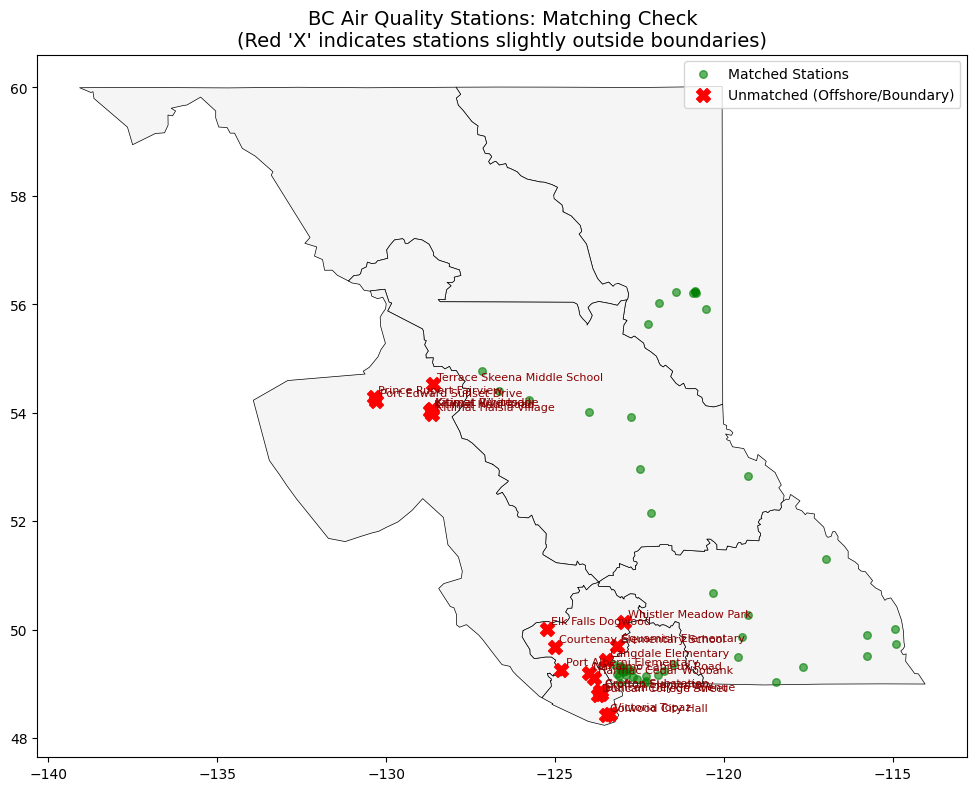

In [7]:
import matplotlib.pyplot as plt

# 准备绘图数据
matched = final_mapping[final_mapping['AIRZONE'].notna()]
unmatched = final_mapping[final_mapping['AIRZONE'].isna()]

fig, ax = plt.subplots(figsize=(12, 12))

# 1. 画出 Air Zone 边界
gdf_zones.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=0.5)

# 2. 画出已成功匹配的站点 (绿色)
if not matched.empty:
    gdf_matched = gpd.GeoDataFrame(matched, geometry=gpd.points_from_xy(matched.LONGITUDE, matched.LATITUDE), crs="EPSG:4326")
    gdf_matched.plot(ax=ax, color='green', markersize=30, label='Matched Stations', alpha=0.6)

# 3. 画出未能匹配的 21 个站点 (红色大点)
if not unmatched.empty:
    gdf_unmatched = gpd.GeoDataFrame(unmatched, geometry=gpd.points_from_xy(unmatched.LONGITUDE, unmatched.LATITUDE), crs="EPSG:4326")
    gdf_unmatched.plot(ax=ax, color='red', markersize=100, marker='X', label='Unmatched (Offshore/Boundary)')
    
    # 给未匹配站点加上名字标注
    for x, y, label in zip(gdf_unmatched.geometry.x, gdf_unmatched.geometry.y, gdf_unmatched['STATION_NAME']):
        ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", fontsize=8, color='darkred')

plt.title("BC Air Quality Stations: Matching Check\n(Red 'X' indicates stations slightly outside boundaries)", fontsize=14)
plt.legend()
plt.show()

In [8]:
# 根据图片观察到的地理位置进行强制映射
coastal_manual_map = {
    # --- 南部：归入 Georgia Strait (乔治亚海峡/温哥华岛) ---
    'Colwood City Hall': 'Georgia Strait',
    'Victoria Topaz': 'Georgia Strait',
    'Duncan College Street': 'Georgia Strait',
    'Duncan Deykin Avenue': 'Georgia Strait',
    'Crofton Elementary': 'Georgia Strait',
    'Crofton Substation': 'Georgia Strait',
    'Nanaimo Labieux Road': 'Georgia Strait',
    'Harmac Cedar Woobank': 'Georgia Strait',
    'Port Alberni Elementary': 'Georgia Strait',
    'Courtenay Elementary School': 'Georgia Strait',
    'Elk Falls Dogwood': 'Georgia Strait',
    'Langdale Elementary': 'Georgia Strait',
    'Squamish Elementary': 'Georgia Strait',
    'Whistler Meadow Park': 'Georgia Strait',
    
    
    # --- 中北部：归入 Coastal Mountain (或根据你 GeoJSON 的具体名称，如 Pacific) ---
    #'Whistler Meadow Park': 'Coastal Mountain',
    'Kitimat Haisla Village': 'Coastal Mountain',
    'Kitimat Haul Road': 'Coastal Mountain',
    'Kitimat Riverlodge': 'Coastal Mountain',
    'Kitimat Whitesail': 'Coastal Mountain',
    'Port Edward Sunset Drive': 'Coastal Mountain',
    'Prince Rupert Fairview': 'Coastal Mountain',
    'Terrace Skeena Middle School': 'Coastal Mountain'
}

# 应用映射到你的 final_mapping 表
final_mapping['AIRZONE'] = final_mapping.apply(
    lambda row: coastal_manual_map.get(row['STATION_NAME'], row['AIRZONE']), 
    axis=1
)

# 检查是否还有 NaN
print(f"修正后剩余未匹配站点数: {final_mapping['AIRZONE'].isna().sum()}")

修正后剩余未匹配站点数: 0


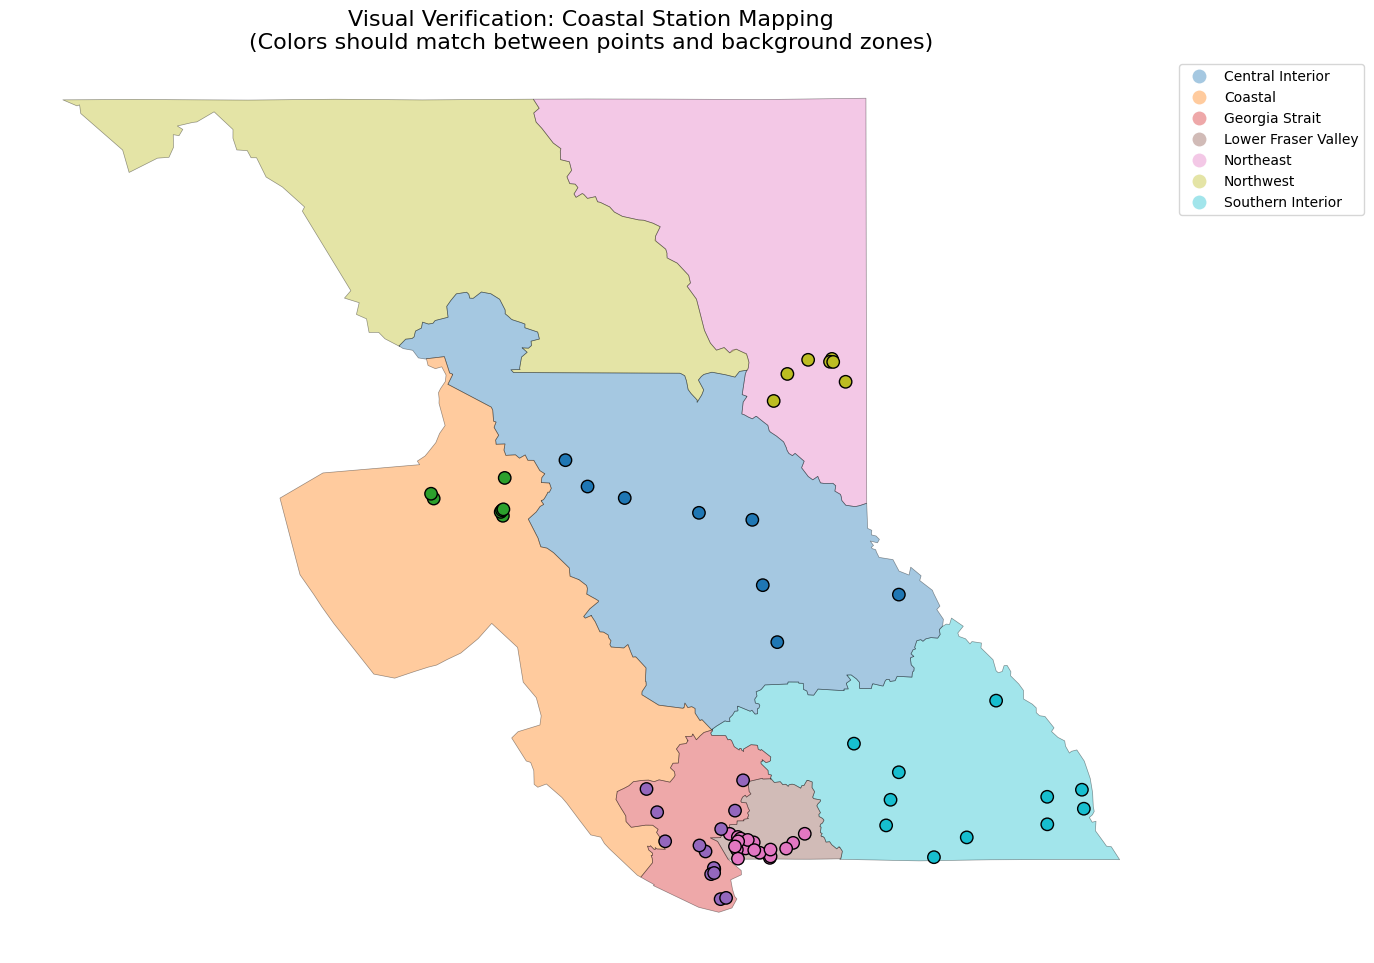

In [9]:
import matplotlib.pyplot as plt

# 1. 确保数据准备就绪
# 之前的 final_mapping 已经有了 AIRZONE 列
gdf_final_points = gpd.GeoDataFrame(
    final_mapping,
    geometry=gpd.points_from_xy(final_mapping.LONGITUDE, final_mapping.LATITUDE),
    crs="EPSG:4326"
)

# 2. 绘图
fig, ax = plt.subplots(figsize=(15, 15))

# --- 图层 1: Airzones (使用 column 参数自动映射) ---
gdf_zones.plot(
    ax=ax,
    column='Airzone', # 直接指定列名
    cmap='tab10',     # 指定调色板
    edgecolor='black',
    linewidth=0.5,
    alpha=0.4,
    legend=True,
    legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
)

# --- 图层 2: 站点 (使用相同的 column 和 cmap 确保颜色对应) ---
gdf_final_points.plot(
    ax=ax,
    column='AIRZONE', # 对应站点表里的区域列
    cmap='tab10',     # 必须与底图使用相同的 cmap
    markersize=80,
    edgecolor='black',
    linewidth=1,
    zorder=2
)

plt.title("Visual Verification: Coastal Station Mapping\n(Colors should match between points and background zones)", fontsize=16)
ax.set_axis_off()
plt.show()

In [10]:
import pandas as pd

# ==========================================
# 1. 确保原始数据已准备好 (2019-2026)
# ==========================================
# 假设 df_combined 是你之前 concat 后的全量数据，
# 如果还没有，我们重新拼接一次：
all_dfs = []

# 历史数据
years = range(2019, 2025)
for year in years:
    fname = f"BC_PM25_{year}_Verified_Summary.csv"
    if os.path.exists(fname):
        df_y = pd.read_csv(fname)
        # 统一时间列名
        if 'DATE_PST' not in df_y.columns:
            df_y['DATE_PST'] = pd.to_datetime(df_y['DATE'] + ' ' + df_y['TIME'])
        all_dfs.append(df_y[['DATE_PST', 'STATION_NAME', 'RAW_VALUE']])

# 实时数据 (2025-2026)
if 'stations_with_location' in locals():
    df_live = stations_with_location.copy()
    df_live['DATE_PST'] = pd.to_datetime(df_live['DATE_PST'])
    all_dfs.append(df_live[['DATE_PST', 'STATION_NAME', 'RAW_VALUE']])

df_raw_all = pd.concat(all_dfs, ignore_index=True)

# ==========================================
# 2. 合并完美的 Mapping 表
# ==========================================
# 使用 inner join 可以自动剔除掉那些无效站点 (如 '10')
merged_df = pd.merge(
    df_raw_all, 
    final_mapping[['STATION_NAME', 'AIRZONE', 'LATITUDE', 'LONGITUDE']], 
    on='STATION_NAME', 
    how='inner'
)

# ==========================================
# 3. 辅助列生成 (方便后续按年/月统计)
# ==========================================
merged_df['DATE_PST'] = pd.to_datetime(merged_df['DATE_PST'])
merged_df['YEAR'] = merged_df['DATE_PST'].dt.year
merged_df['MONTH'] = merged_df['DATE_PST'].dt.month
merged_df['DATE'] = merged_df['DATE_PST'].dt.date

# 排序
merged_df = merged_df.sort_values(by=['AIRZONE', 'STATION_NAME', 'DATE_PST'])

print("✅ merged_df 已生成！")
print(f"总数据行数: {len(merged_df)}")
print(f"覆盖年份: {merged_df['YEAR'].min()} - {merged_df['YEAR'].max()}")
print(f"包含 Air Zones: {merged_df['AIRZONE'].unique().tolist()}")

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/2564873810.py:15: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_y = pd.read_csv(fname)


✅ merged_df 已生成！
总数据行数: 4079867
覆盖年份: 2019 - 2026
包含 Air Zones: ['Central Interior', 'Coastal Mountain', 'Georgia Strait', 'Lower Fraser Valley', 'Northeast', 'Southern Interior']


In [11]:
# 创建临时列标记是否为 NaN (NaN=1, 有数值=0)，排序时 0 靠前
merged_df['is_nan_temp'] = merged_df['RAW_VALUE'].isna().astype(int)

# 排序：站点 -> 时间 -> 有效值优先
df_sorted = merged_df.sort_values(by=['STATION_NAME', 'DATE_PST', 'is_nan_temp'])

# 去重：保留每个站点每小时的第一条（即非空记录）
df_dedupped = df_sorted.drop_duplicates(subset=['STATION_NAME', 'DATE_PST'], keep='first')
df_dedupped = df_dedupped.drop(columns=['is_nan_temp'])

print(f"去重完成，剩余行数: {len(df_dedupped)}")

去重完成，剩余行数: 3937374


In [12]:
def reindex_by_hour(group):
    # 为每个站点生成从其开始到结束的完美 1H 时间轴
    ideal_index = pd.date_range(start=group['DATE_PST'].min(), end=group['DATE_PST'].max(), freq='H')
    # 对齐后，RAW_VALUE 会自动补 NaN，但 STATION_NAME 需要保留
    return group.set_index('DATE_PST').reindex(ideal_index).rename_axis('DATE_PST').reset_index()

# A. 生成时间轴连续的基础表
df_aligned = df_dedupped.groupby('STATION_NAME', group_keys=False).apply(reindex_by_hour)

# B. 回填 AIRZONE 和 坐标 (merge 之后补齐的时间行原本是空的)
# 先提取一份干净的站点-区域对照表
station_info = final_mapping[['STATION_NAME', 'AIRZONE', 'LATITUDE', 'LONGITUDE']].drop_duplicates()

# 重新 merge，让所有补齐的小时行都带上 Air Zone 标签
df_final = pd.merge(
    df_aligned[['STATION_NAME', 'DATE_PST', 'RAW_VALUE']], 
    station_info, 
    on='STATION_NAME', 
    how='left'
)

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/4225010866.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ideal_index = pd.date_range(start=group['DATE_PST'].min(), end=group['DATE_PST'].max(), freq='H')
/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/4225010866.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ideal_index = pd.date_range(start=group['DATE_PST'].min(), end=group['DATE_PST'].max(), freq='H')
/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/4225010866.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ideal_index = pd.date_range(start=group['DATE_PST'].min(), end=group['DATE_PST'].max(), freq='H')
/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/4225010866.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, plea

In [13]:
# 生成时间特征
df_final['YEAR'] = df_final['DATE_PST'].dt.year
df_final['MONTH'] = df_final['DATE_PST'].dt.month
df_final['DATE'] = df_final['DATE_PST'].dt.date

print("🚀 终极清洗流水线执行完毕！")

🚀 终极清洗流水线执行完毕！


In [14]:
# 1. 对每个站点的 DATE_PST 进行差分计算
df_cleaned = df_final.sort_values(['STATION_NAME', 'DATE_PST'])
df_cleaned['time_diff'] = df_cleaned.groupby('STATION_NAME')['DATE_PST'].diff()

# 2. 统计时间间隔的分布
# 正常应为 01:00:00 (1小时)
interval_counts = df_cleaned['time_diff'].value_counts().head(10)
print("--- 常见时间间隔分布 ---")
print(interval_counts)

# 3. 找出非 1 小时的异常间隔 (例如 15min)
abnormal_intervals = df_cleaned[
    (df_cleaned['time_diff'].notna()) & 
    (df_cleaned['time_diff'] != pd.Timedelta(hours=1))
]
print(f"\n检测到 {len(abnormal_intervals)} 处非标准时间间隔 (Gap 或 亚小时频率)")

--- 常见时间间隔分布 ---
time_diff
0 days 01:00:00     3937303
0 days 03:00:00           1
13 days 23:00:00          1
Name: count, dtype: int64

检测到 2 处非标准时间间隔 (Gap 或 亚小时频率)


In [15]:
df_final

,STATION_NAME,DATE_PST,RAW_VALUE,AIRZONE,LATITUDE,LONGITUDE,YEAR,MONTH,DATE
0,Abbotsford A Columbia Street,2019-01-01 01:00:00,14.90379,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01
1,Abbotsford A Columbia Street,2019-01-01 02:00:00,13.80442,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01
2,Abbotsford A Columbia Street,2019-01-01 03:00:00,13.21633,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01
3,Abbotsford A Columbia Street,2019-01-01 04:00:00,15.96628,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01
4,Abbotsford A Columbia Street,2019-01-01 05:00:00,16.60911,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01
...,...,...,...,...,...,...,...,...,...
3937705,Willow Creek Mine,2026-02-10 08:00:00,0.883468,Northeast,55.6355,-122.235639,2026,2,2026-02-10
3937706,Willow Creek Mine,2026-02-10 09:00:00,0.964295,Northeast,55.6355,-122.235639,2026,2,2026-02-10
3937707,Willow Creek Mine,2026-02-10 10:00:00,0.821958,Northeast,55.6355,-122.235639,2026,2,2026-02-10
3937708,Willow Creek Mine,2026-02-10 11:00:00,0.602693,Northeast,55.6355,-122.235639,2026,2,2026-02-10


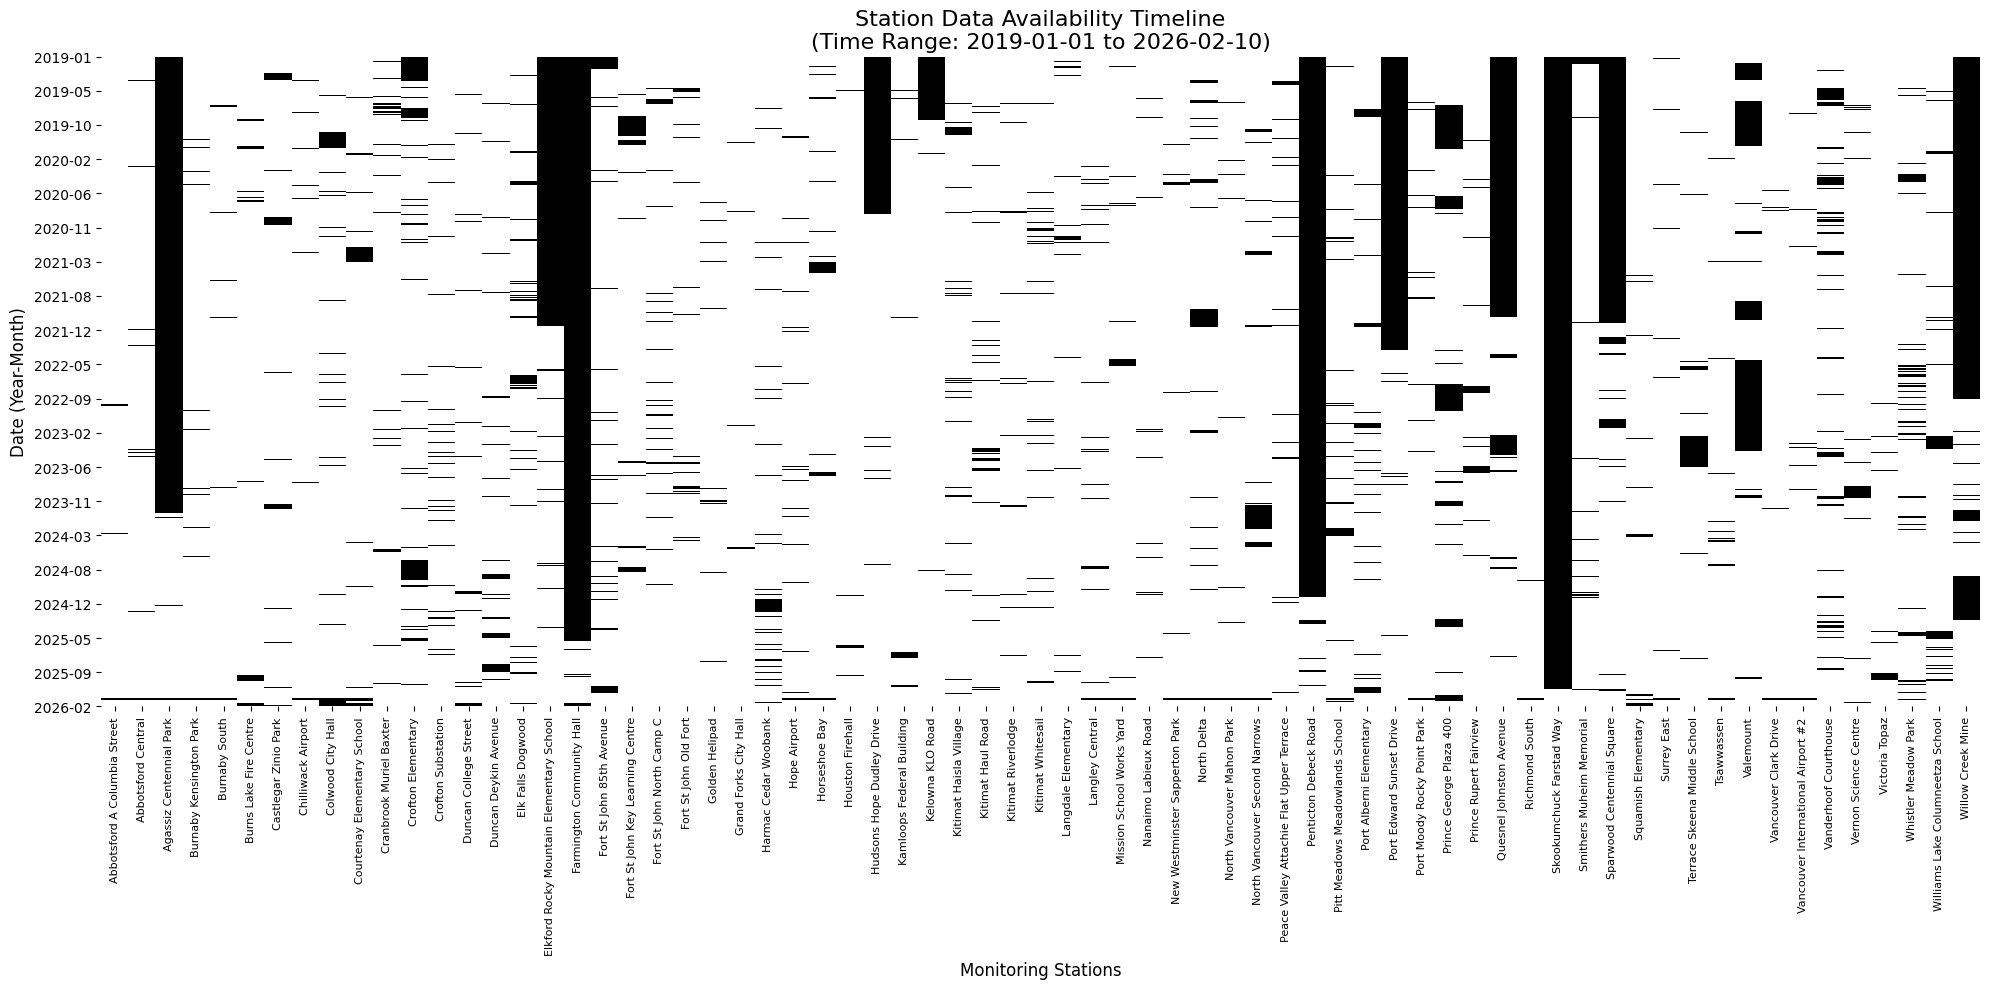

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 准备数据：生成宽格式矩阵 (True=缺失, False=有数据)
# 确保 datetime 是 datetime 格式
df_final['datetime'] = pd.to_datetime(df_final['DATE_PST'])

# pivot_table: 索引是时间，列是站点，值是 PM2.5
# 我们只关心是否缺失，所以用 isna()
pivot_missing = df_final.pivot_table(
    index='datetime', 
    columns='STATION_NAME', 
    values='RAW_VALUE', 
    aggfunc='first' # 任意聚合函数，反正我们要转成布尔值
)

# 转换为布尔矩阵：True 代表缺失 (白色)，False 代表有值 (黑色)
missing_matrix = pivot_missing.isna()

# 2. 绘图
plt.figure(figsize=(20, 10)) # 把图画大一点

# cbar=False: 不需要颜色条，只看黑白
# yticklabels=False: 先关掉默认的标签，我们后面自己画清楚的
ax = sns.heatmap(missing_matrix, cbar=False, cmap='binary', yticklabels=False)

# 3. 【关键步骤】自定义 Y 轴时间标签
# 我们不能显示所有时间，只显示大约 20 个刻度，让图看起来整洁
num_ticks = 20
total_rows = len(missing_matrix)
tick_indices = [int(i) for i in  np.linspace(0, total_rows - 1, num_ticks)]

# 获取对应索引位置的时间字符串 (格式：年-月)
tick_labels = [missing_matrix.index[i].strftime('%Y-%m') for i in tick_indices]

# 将刻度和标签应用到图上
ax.set_yticks(tick_indices)
ax.set_yticklabels(tick_labels, rotation=0, fontsize=10)

# 设置 X 轴（站点名称）字体大小，防止太密看不清
plt.xticks(fontsize=8, rotation=90)

plt.title(f"Station Data Availability Timeline\n(Time Range: {missing_matrix.index.min().date()} to {missing_matrix.index.max().date()})", fontsize=16)
plt.ylabel("Date (Year-Month)", fontsize=12)
plt.xlabel("Monitoring Stations", fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
df_final['RAW_VALUE'] = pd.to_numeric(df_final['RAW_VALUE'], errors='coerce')

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/172875302.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='AIRZONE', y='RAW_VALUE', palette='Set3', ax=ax3, showfliers=False)


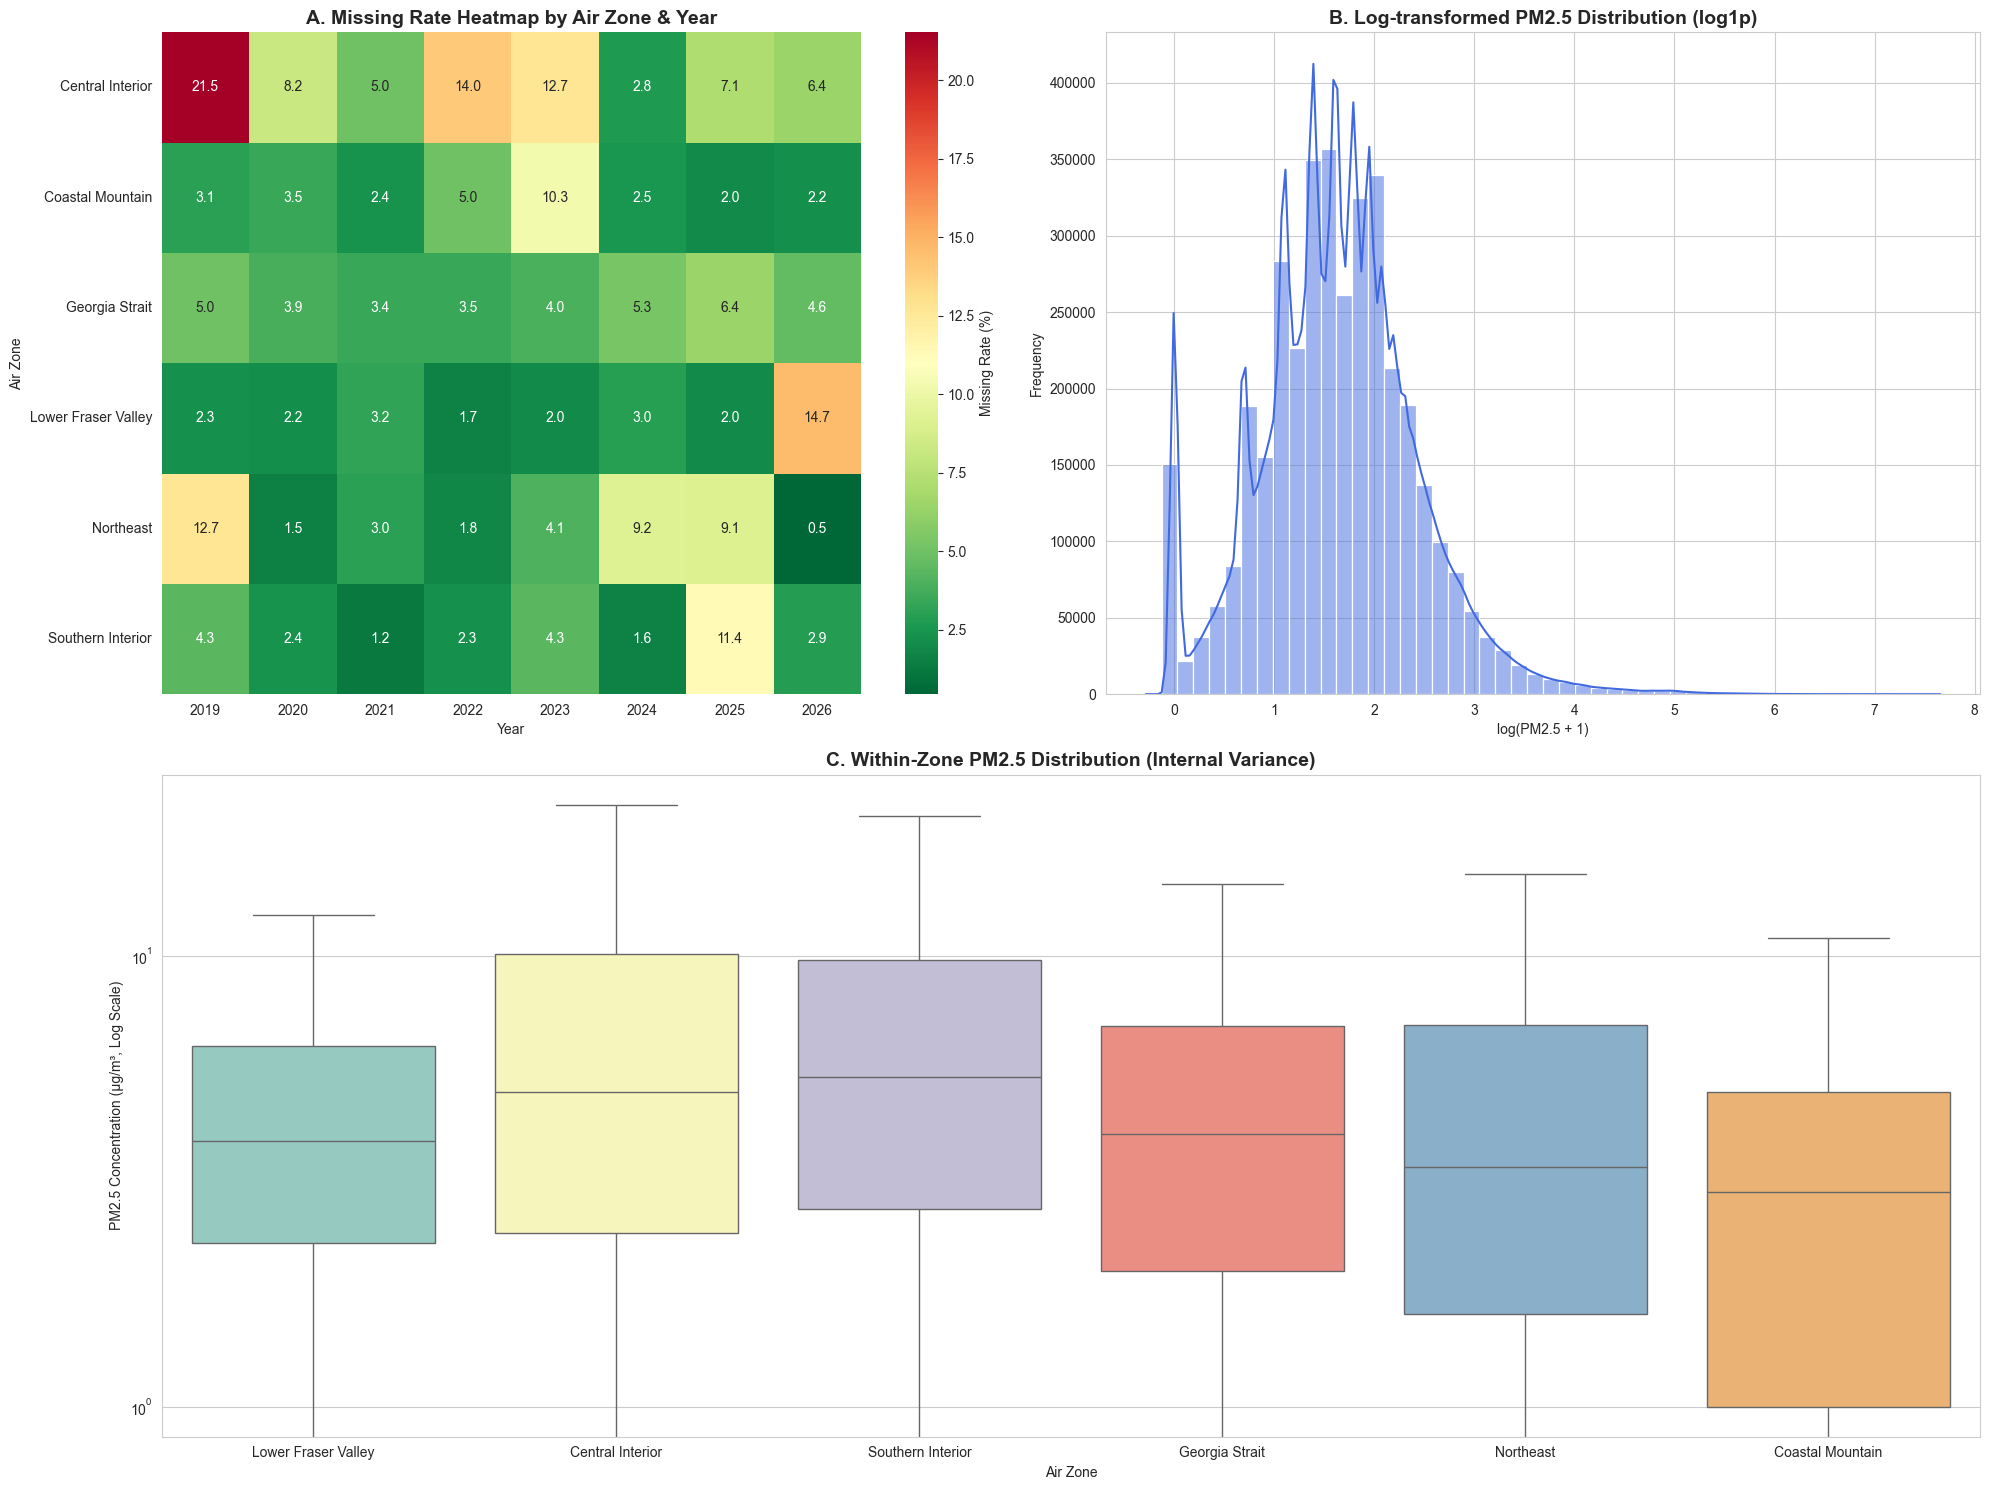

--- 区域内部方差统计 (Std Dev & Var) ---
                       std     var  mean      max
AIRZONE                                          
Central Interior     13.58  184.31  8.81   593.99
Coastal Mountain      4.45   19.78  3.82   230.00
Georgia Strait        8.27   68.33  5.87   380.81
Lower Fraser Valley   8.26   68.27  5.38   420.71
Northeast            26.05  678.47  8.08  2112.48
Southern Interior    18.13  328.55  8.81  1308.15


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局绘图风格
sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- 1. Missing 分布热力图 (Year vs Airzone) ---
ax1 = plt.subplot(2, 2, 1)
missing_pivot = df_final.groupby(['AIRZONE', 'YEAR'])['RAW_VALUE'].apply(
    lambda x: (x.isna().sum() / len(x)) * 100
).unstack()

sns.heatmap(missing_pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax1, cbar_kws={'label': 'Missing Rate (%)'})
ax1.set_title('A. Missing Rate Heatmap by Air Zone & Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Air Zone')

# --- 2. Log1p(PM2.5) 分布图 ---
ax2 = plt.subplot(2, 2, 2)
# 提取非空值并进行 log(x+1) 变换
log_data = np.log1p(df_final['RAW_VALUE'].dropna())
sns.histplot(log_data, kde=True, color='royalblue', bins=50, ax=ax2)
ax2.set_title('B. Log-transformed PM2.5 Distribution (log1p)', fontsize=14, fontweight='bold')
ax2.set_xlabel('log(PM2.5 + 1)')
ax2.set_ylabel('Frequency')

# --- 3. Airzone 内部方差分布 (Boxplot showing Spread) ---
ax3 = plt.subplot(2, 1, 2)
# 使用对数坐标轴来更好地展示 PM2.5 的内部差异（因为原始数据极差很大）
sns.boxplot(data=df_final, x='AIRZONE', y='RAW_VALUE', palette='Set3', ax=ax3, showfliers=False)
ax3.set_yscale('log') # 关键：对数坐标轴
ax3.set_title('C. Within-Zone PM2.5 Distribution (Internal Variance)', fontsize=14, fontweight='bold')
ax3.set_ylabel('PM2.5 Concentration (μg/m³, Log Scale)')
ax3.set_xlabel('Air Zone')

plt.tight_layout()
plt.show()

# --- 打印数值统计摘要 ---
print("--- 区域内部方差统计 (Std Dev & Var) ---")
variance_summary = df_final.groupby('AIRZONE')['RAW_VALUE'].agg(['std', 'var', 'mean', 'max']).round(2)
print(variance_summary)

In [26]:
# 计算每年总记录数、有效记录数及缺失数
annual_record_summary = df_final.groupby('YEAR').agg(
    total_rows=('DATE_PST', 'count'),
    valid_readings=('RAW_VALUE', 'count'),
    missing_readings=('RAW_VALUE', lambda x: x.isna().sum())
).copy()

# 计算有效率百分比
annual_record_summary['completeness_rate_'] = (
    annual_record_summary['valid_readings'] / annual_record_summary['total_rows'] * 100
).round(2)

print("--- 2019-2026 年度数据记录统计汇总 ---")
print(annual_record_summary)

# 如果需要保存为 CSV
# annual_record_summary.to_csv('annual_record_counts_summary.csv')

--- 2019-2026 年度数据记录统计汇总 ---
      total_rows  valid_readings  missing_readings  completeness_rate_
YEAR                                                                  
2019      508732          475755             32977               93.52
2020      520667          502726             17941               96.55
2021      528141          511604             16537               96.87
2022      561039          538225             22814               95.93
2023      569400          539873             29527               94.81
2024      580498          558040             22458               96.13
2025      604438          569314             35124               94.19
2026       64795           60278              4517               93.03


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/585507411.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_missing_all.index, y=monthly_missing_all.values, palette='viridis')


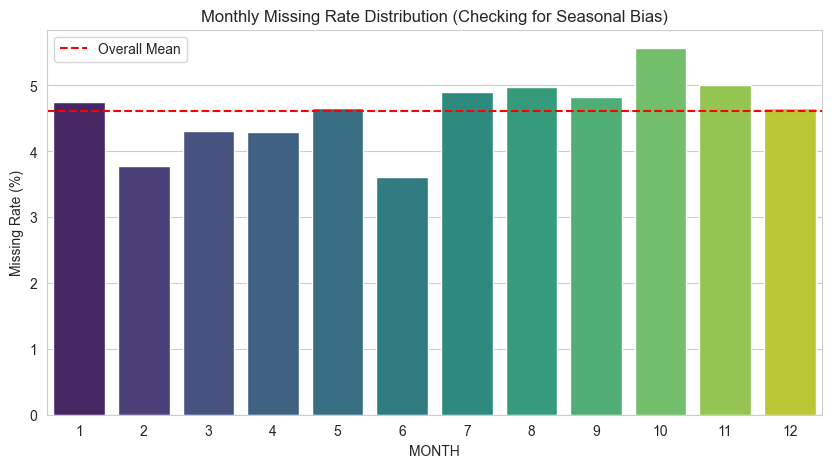

In [27]:
# 计算全省每月的平均缺失率
monthly_missing_all = df_final.groupby('MONTH')['RAW_VALUE'].apply(lambda x: x.isna().mean() * 100)

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_missing_all.index, y=monthly_missing_all.values, palette='viridis')
plt.title('Monthly Missing Rate Distribution (Checking for Seasonal Bias)')
plt.ylabel('Missing Rate (%)')
plt.axhline(y=df_final['RAW_VALUE'].isna().mean()*100, color='r', linestyle='--', label='Overall Mean')
plt.legend()
plt.show()

In [28]:
# 1. 找出 Central Interior 缺失最严重的日期（Top 10）
central_missing_days = df_final[df_final['AIRZONE'] == 'Central Interior'].groupby('DATE').agg(
    missing_cnt=('RAW_VALUE', lambda x: x.isna().sum()),
    total_cnt=('RAW_VALUE', 'count')
)
central_missing_days['missing_rate'] = central_missing_days['missing_cnt'] / central_missing_days['total_cnt']
top_missing_dates = central_missing_days.sort_values('missing_rate', ascending=False).head(10).index

# 2. 查看这些日期下，其他“数据完整”区域的 PM2.5 表现
other_zones_data = df_final[
    (df_final['DATE'].isin(top_missing_dates)) & 
    (df_final['AIRZONE'] != 'Central Interior')
].groupby(['DATE', 'AIRZONE'])['RAW_VALUE'].mean().unstack()

print("--- 当 Central Interior 大规模缺失时，其他区域的平均浓度 ---")
print(other_zones_data)

--- 当 Central Interior 大规模缺失时，其他区域的平均浓度 ---
AIRZONE     Coastal Mountain  Georgia Strait  Lower Fraser Valley  Northeast  \
DATE                                                                           
2019-07-13          3.565241        3.337612             4.292700  14.600017   
2019-07-14          3.237435        3.546926             4.107488  12.575328   
2019-07-15          3.551365        4.015967             4.930883  12.383758   
2019-07-16          2.457120        3.412559             4.403780   8.470629   
2019-07-17          2.369056        1.369971             2.638088   3.645743   
2020-01-03          2.573292        3.979242             3.557386   2.591832   
2023-03-04          4.268892        3.563351             3.385012   3.048236   
2023-04-16          3.023473        3.057147             3.407915   6.073652   
2023-04-17          1.993188        2.378776             2.525332   2.498187   
2023-04-18          2.543983        2.272065             2.145939   2.954212

In [29]:
# 以 Southern Interior 为例检测随机性
def check_mcar(target_zone):
    # 找到目标区域缺失的时间点
    missing_times = df_final[(df_final['AIRZONE'] == target_zone) & (df_final['RAW_VALUE'].isna())]['DATE_PST']
    valid_times = df_final[(df_final['AIRZONE'] == target_zone) & (df_final['RAW_VALUE'].notna())]['DATE_PST']
    
    # 计算这些时间点，全省其他区域的平均浓度
    avg_when_missing = df_final[df_final['DATE_PST'].isin(missing_times)]['RAW_VALUE'].mean()
    avg_when_valid = df_final[df_final['DATE_PST'].isin(valid_times)]['RAW_VALUE'].mean()
    
    print(f"--- [{target_zone}] 随机性检测 ---")
    print(f"该区域缺失时，全省其他区域均值: {avg_when_missing:.2f}")
    print(f"该区域正常时，全省其他区域均值: {avg_when_valid:.2f}")
    
    diff = ((avg_when_missing - avg_when_valid) / avg_when_valid) * 100
    print(f"浓度差异: {diff:.2f}%")
    if abs(diff) > 20:
        print("⚠️ 警告：检测到明显的非随机缺失倾向 (MNAR)！数据缺失可能与高污染事件正相关。")
    else:
        print("✅ 结论：缺失分布相对随机 (MCAR/MAR)。")

check_mcar('Central Interior')

--- [Central Interior] 随机性检测 ---
该区域缺失时，全省其他区域均值: 6.43
该区域正常时，全省其他区域均值: 6.44
浓度差异: -0.20%
✅ 结论：缺失分布相对随机 (MCAR/MAR)。


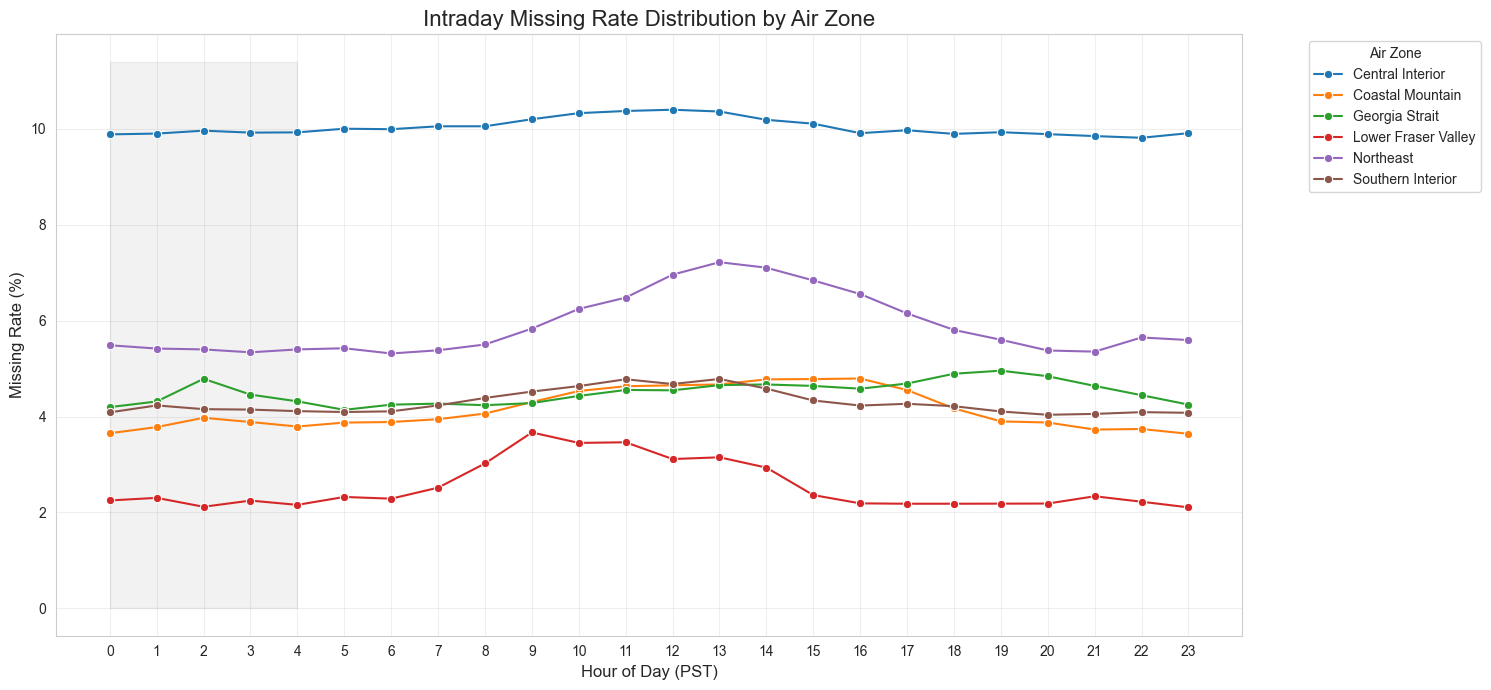

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 提取小时信息
df_final['HOUR'] = df_final['DATE_PST'].dt.hour

# 2. 计算每个小时、每个区域的缺失率
intraday_missing = df_final.groupby(['AIRZONE', 'HOUR'])['RAW_VALUE'].apply(
    lambda x: (x.isna().sum() / len(x)) * 100
).unstack(0)

# 3. 绘图
plt.figure(figsize=(15, 7))
sns.lineplot(data=intraday_missing, dashes=False, marker='o')

plt.title('Intraday Missing Rate Distribution by Air Zone', fontsize=16)
plt.ylabel('Missing Rate (%)', fontsize=12)
plt.xlabel('Hour of Day (PST)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title='Air Zone', bbox_to_anchor=(1.05, 1), loc='upper left')

# 标注出典型的高峰段
plt.fill_between(range(0, 24), 0, intraday_missing.max().max() + 1, 
                 where=(pd.Series(range(24)) >= 0) & (pd.Series(range(24)) <= 4), 
                 color='gray', alpha=0.1, label='Night Maintenance Window')

plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# --- 0) 准备 ---
df = df_final.copy()
df['HOUR'] = df['DATE_PST'].dt.hour
df['is_missing'] = df['RAW_VALUE'].isna().astype(int)

# --- 1) overall: missing 与 hour 是否独立 (卡方检验) ---
ct_all = pd.crosstab(df['HOUR'], df['is_missing'])  # 行: hour, 列: 0/1
chi2, p, dof, expected = chi2_contingency(ct_all)

# Cramér's V (效应量)
n = ct_all.to_numpy().sum()
k = min(ct_all.shape)  # min(#rows,#cols)
cramers_v = np.sqrt(chi2 / (n * (k - 1))) if k > 1 else np.nan

print(f"[Overall] Chi2={chi2:.2f}, dof={dof}, p={p:.3g}, Cramer's V={cramers_v:.4f}")

# --- 2) per-airzone: missing 与 hour 是否独立 (卡方检验) ---
zone_results = []
for zone, g in df.groupby('AIRZONE'):
    ct = pd.crosstab(g['HOUR'], g['is_missing'])
    # 某些小时若全是 0/1 可能导致列缺失，补齐
    if 0 not in ct.columns: ct[0] = 0
    if 1 not in ct.columns: ct[1] = 0
    ct = ct[[0, 1]]

    chi2_z, p_z, dof_z, _ = chi2_contingency(ct)
    n_z = ct.to_numpy().sum()
    k_z = min(ct.shape)
    v_z = np.sqrt(chi2_z / (n_z * (k_z - 1))) if k_z > 1 else np.nan

    zone_results.append((zone, chi2_z, dof_z, p_z, v_z))

zone_results = pd.DataFrame(zone_results, columns=['AIRZONE','chi2','dof','p','cramers_v']).sort_values('p')
print("\n[By Airzone] (sorted by p)")
print(zone_results)

# --- 3) 置换检验：hour-pattern 的“起伏幅度”是否像随机 ---
# 指标：按 hour 的 missing rate 曲线的标准差（越大越“有结构”）
def hour_pattern_stat(sub):
    rate_by_hour = sub.groupby('HOUR')['is_missing'].mean()  # 0-1
    # 补齐 0..23
    rate_by_hour = rate_by_hour.reindex(range(24), fill_value=rate_by_hour.mean())
    return rate_by_hour.std()

def permutation_pvalue(sub, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    obs = hour_pattern_stat(sub)
    vals = np.empty


[Overall] Chi2=727.25, dof=23, p=8.01e-139, Cramer's V=0.0136

[By Airzone] (sorted by p)
               AIRZONE         chi2  dof              p  cramers_v
3  Lower Fraser Valley  1212.450012   23  7.405082e-242   0.030955
4            Northeast   274.192545   23   7.201347e-45   0.026253
1     Coastal Mountain   164.220226   23   2.656018e-23   0.020056
2       Georgia Strait   109.014833   23   3.764348e-13   0.011204
5    Southern Interior    71.119809   23   8.157371e-07   0.011650
0     Central Interior    16.146854   23   8.489103e-01   0.005840


In [31]:
df_final

,STATION_NAME,DATE_PST,RAW_VALUE,AIRZONE,LATITUDE,LONGITUDE,YEAR,MONTH,DATE,datetime,HOUR
0,Abbotsford A Columbia Street,2019-01-01 01:00:00,14.903790,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01,2019-01-01 01:00:00,1
1,Abbotsford A Columbia Street,2019-01-01 02:00:00,13.804420,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01,2019-01-01 02:00:00,2
2,Abbotsford A Columbia Street,2019-01-01 03:00:00,13.216330,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01,2019-01-01 03:00:00,3
3,Abbotsford A Columbia Street,2019-01-01 04:00:00,15.966280,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01,2019-01-01 04:00:00,4
4,Abbotsford A Columbia Street,2019-01-01 05:00:00,16.609110,Lower Fraser Valley,49.0215,-122.326500,2019,1,2019-01-01,2019-01-01 05:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
3937705,Willow Creek Mine,2026-02-10 08:00:00,0.883468,Northeast,55.6355,-122.235639,2026,2,2026-02-10,2026-02-10 08:00:00,8
3937706,Willow Creek Mine,2026-02-10 09:00:00,0.964295,Northeast,55.6355,-122.235639,2026,2,2026-02-10,2026-02-10 09:00:00,9
3937707,Willow Creek Mine,2026-02-10 10:00:00,0.821958,Northeast,55.6355,-122.235639,2026,2,2026-02-10,2026-02-10 10:00:00,10
3937708,Willow Creek Mine,2026-02-10 11:00:00,0.602693,Northeast,55.6355,-122.235639,2026,2,2026-02-10,2026-02-10 11:00:00,11


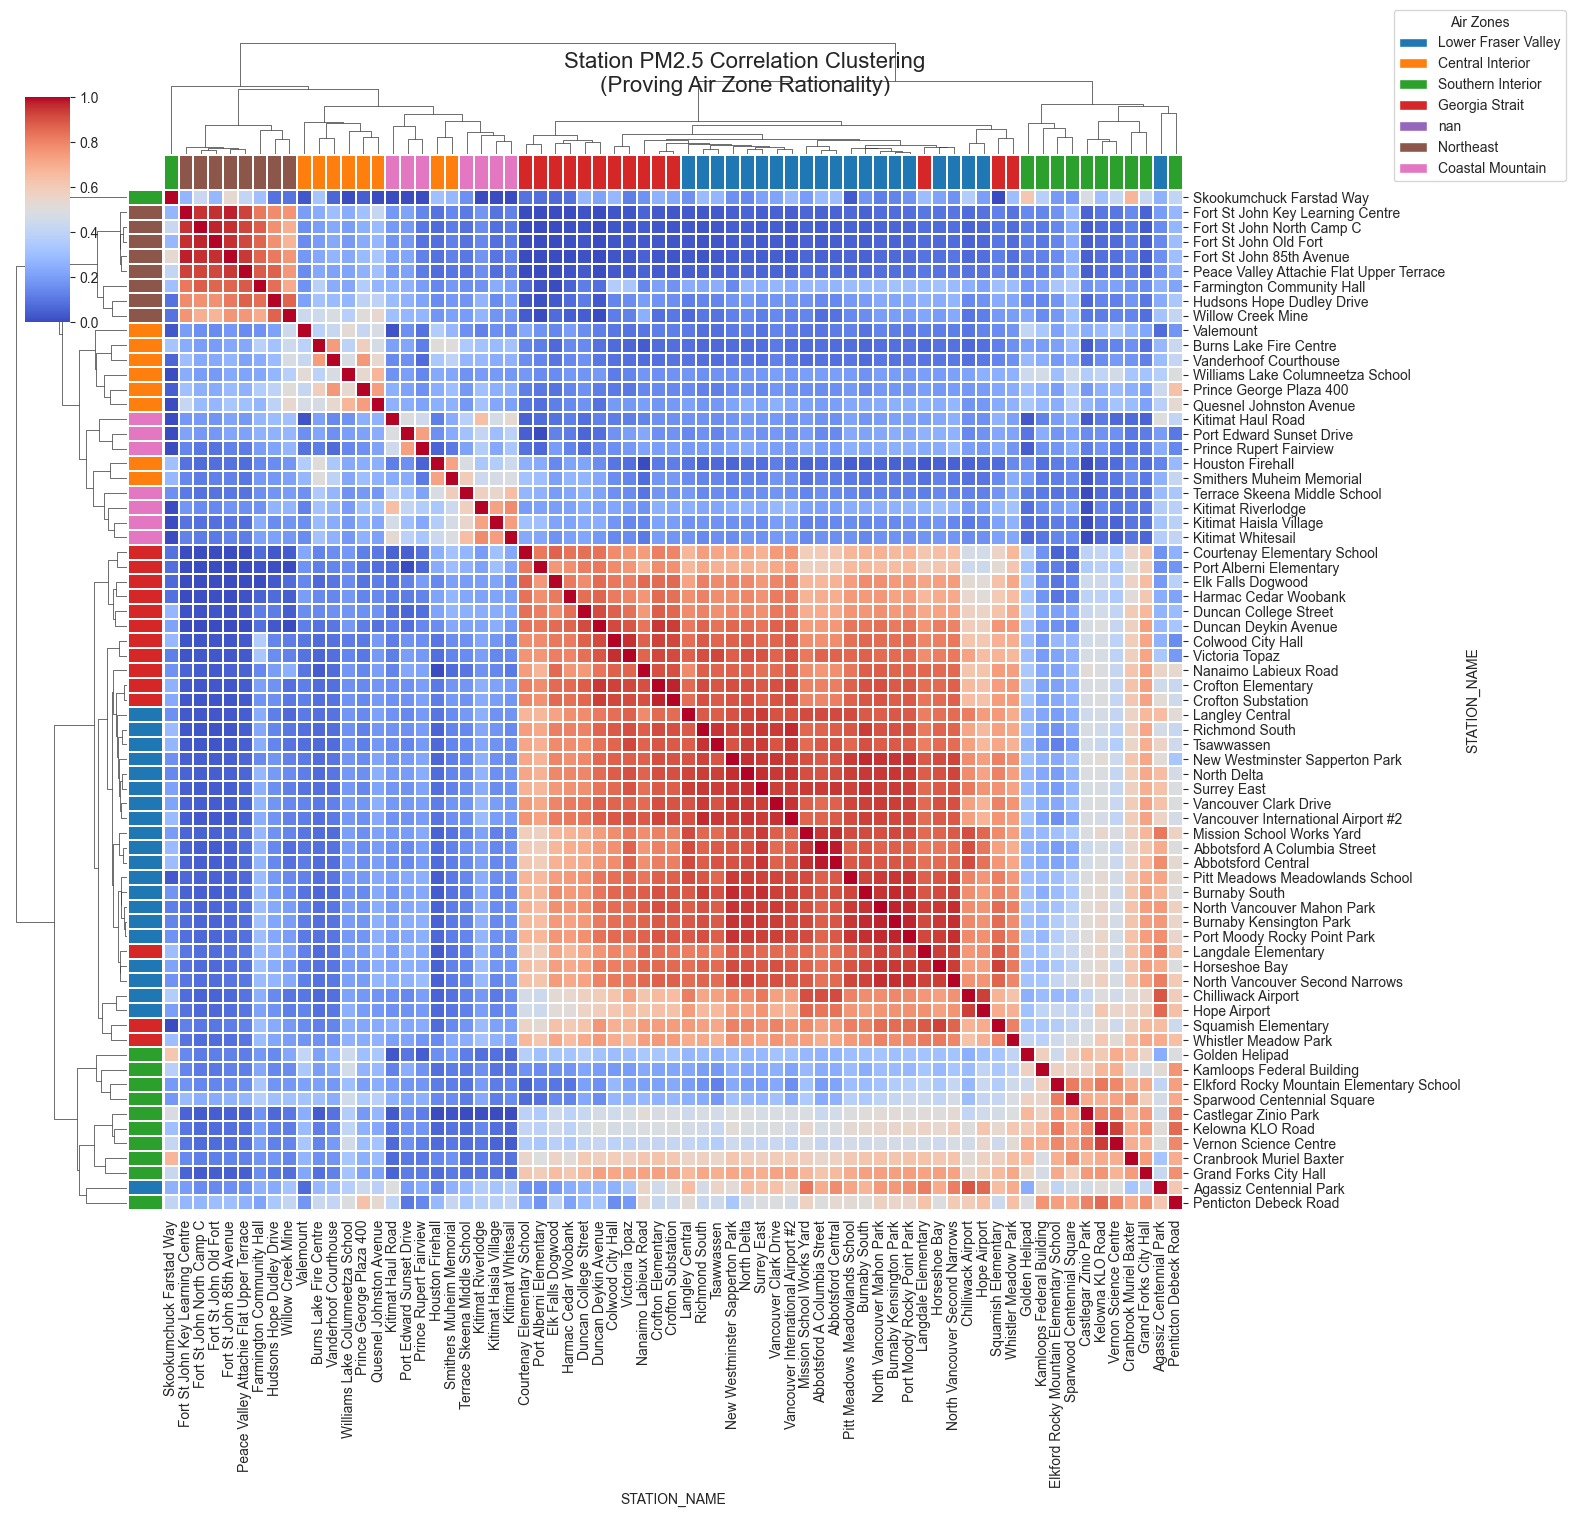

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 建立轻量级站点映射表 (解决崩溃的关键) ---
# 只提取站点和区域的对应关系，每个站点一行
site_info = df_final[['STATION_NAME', 'AIRZONE']].drop_duplicates().set_index('STATION_NAME')

# --- 2. 创建透视表 (直接用 df_final，不要用 merge 后的) ---
# 建议先重采样到日均值，减少计算相关系数时的维度
df_pivot = df_final.pivot_table(
    index='DATE_PST', 
    columns='STATION_NAME', 
    values='RAW_VALUE'
)
df_daily = df_pivot.resample('D').mean()

# --- 3. 计算相关系数 ---
# min_periods=30 确保至少有一个月的重叠数据
corr_matrix = df_daily.corr(min_periods=30)
corr_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')

# --- 4. 颜色映射 (Color Palette) ---
unique_zones = site_info['AIRZONE'].unique()
palette = sns.color_palette("tab10", len(unique_zones))
lut = dict(zip(unique_zones, palette))

# 确保 corr_matrix 中的站点在 site_info 中能找到
row_colors = [lut[site_info.loc[s, 'AIRZONE']] for s in corr_matrix.columns]

# --- 5. 绘制 Clustermap ---
g = sns.clustermap(
    corr_matrix,
    row_colors=row_colors,    
    col_colors=row_colors,    
    cmap="coolwarm",          
    vmin=0, vmax=1,           
    center=0.5,
    figsize=(15, 15),         
    dendrogram_ratio=0.1,
    cbar_pos=(0.02, 0.8, 0.03, 0.15), 
    linewidths=0.1,          
    xticklabels=True,         
    yticklabels=True
)

# --- 6. 整理图例与标题 ---
from matplotlib.patches import Patch
handles = [Patch(facecolor=lut[name]) for name in lut]
g.ax_col_dendrogram.legend(handles, lut.keys(), title='Air Zones', 
                           loc='center left', bbox_to_anchor=(1.2, 0.5))

plt.suptitle("Station PM2.5 Correlation Clustering\n(Proving Air Zone Rationality)", y=0.98, fontsize=16)
plt.show()

--- Top 20 Stations with Highest Missing Rates (2019-2025) ---
STATION_NAME
Skookumchuck Farstad Way            92.830232
Farmington Community Hall           42.619020
Valemount                           28.508808
Willow Creek Mine                   20.497352
Prince George Plaza 400             16.891815
Vanderhoof Courthouse               12.726710
Crofton Elementary                   9.839391
Whistler Meadow Park                 8.317174
Penticton Debeck Road                8.281661
Quesnel Johnston Avenue              8.089265
North Vancouver Second Narrows       7.352486
North Delta                          6.762592
Sparwood Centennial Square           6.750077
Terrace Skeena Middle School         6.721854
Williams Lake Columneetza School     6.298173
Fort St John Key Learning Centre     6.223214
Elk Falls Dogwood                    6.052113
Port Alberni Elementary              5.638209
Fort St John 85th Avenue             5.348151
Duncan Deykin Avenue                 5.248749
Name

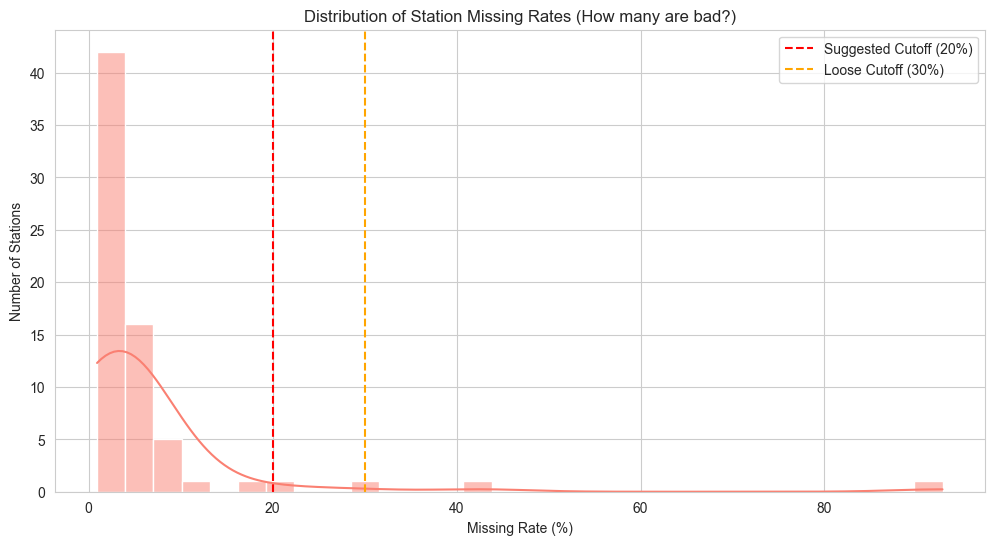

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 选取 2019-2025 的数据进行评估 (2026年还没过完，算缺失率不公平)
eval_df = df_final[df_final['YEAR'].between(2019, 2025)]

# 2. 计算每个站点的缺失率
station_missing_rates = eval_df.groupby('STATION_NAME')['RAW_VALUE'].apply(
    lambda x: x.isna().mean() * 100
).sort_values(ascending=False)

# 3. 打印“重症监护室”名单 (缺失率最高的 Top 20)
print("--- Top 20 Stations with Highest Missing Rates (2019-2025) ---")
print(station_missing_rates.head(20))

# 4. 可视化分布，帮你决定砍在哪里
plt.figure(figsize=(12, 6))
sns.histplot(station_missing_rates, bins=30, kde=True, color='salmon')
plt.axvline(x=20, color='red', linestyle='--', label='Suggested Cutoff (20%)')
plt.axvline(x=30, color='orange', linestyle='--', label='Loose Cutoff (30%)')
plt.title('Distribution of Station Missing Rates (How many are bad?)')
plt.xlabel('Missing Rate (%)')
plt.ylabel('Number of Stations')
plt.legend()
plt.show()

In [37]:
# 1. 定义要剔除的“黑名单” (缺失率 > 10% 的站点)
drop_list = [
    "Skookumchuck Farstad Way",
    "Farmington Community Hall",
    "Valemount",
    "Willow Creek Mine",
    "Prince George Plaza 400",
    "Vanderhoof Courthouse"
]

print(f"准备剔除 {len(drop_list)} 个高缺失站点...")

# 2. 执行剔除操作
# 使用 ~ (取反) 和 isin 来保留“不在黑名单里”的站点
df_clean = df_final[~df_final['STATION_NAME'].isin(drop_list)].copy()

# 3. 验证结果
print("------------------------------------------------")
print(f"原始数据站点数: {df_final['STATION_NAME'].nunique()}")
print(f"清洗后站点数:   {df_clean['STATION_NAME'].nunique()}")
print("------------------------------------------------")
print("剔除完成！现在的 df_clean 是纯净版数据。")

# 4. 再次检查 Air Zone 的生存情况 (防止某个区被删光)
print("\n--- 清洗后各 Air Zone 的剩余站点分布 ---")
print(df_clean['AIRZONE'].value_counts())

准备剔除 6 个高缺失站点...
------------------------------------------------
原始数据站点数: 69
清洗后站点数:   63
------------------------------------------------
剔除完成！现在的 df_clean 是纯净版数据。

--- 清洗后各 Air Zone 的剩余站点分布 ---
AIRZONE
Lower Fraser Valley    1265295
Georgia Strait          868508
Southern Interior       514276
Coastal Mountain        408264
Northeast               358902
Central Interior        286462
Name: count, dtype: int64


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/562578539.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zone_completeness = zone_stats.groupby('AIRZONE').apply(


--- 聚合后的区域数据完整度 (Zone Completeness) ---
AIRZONE
Lower Fraser Valley     99.661534
Central Interior        99.996792
Northeast               99.998396
Southern Interior       99.998396
Coastal Mountain       100.000000
Georgia Strait         100.000000
dtype: float64


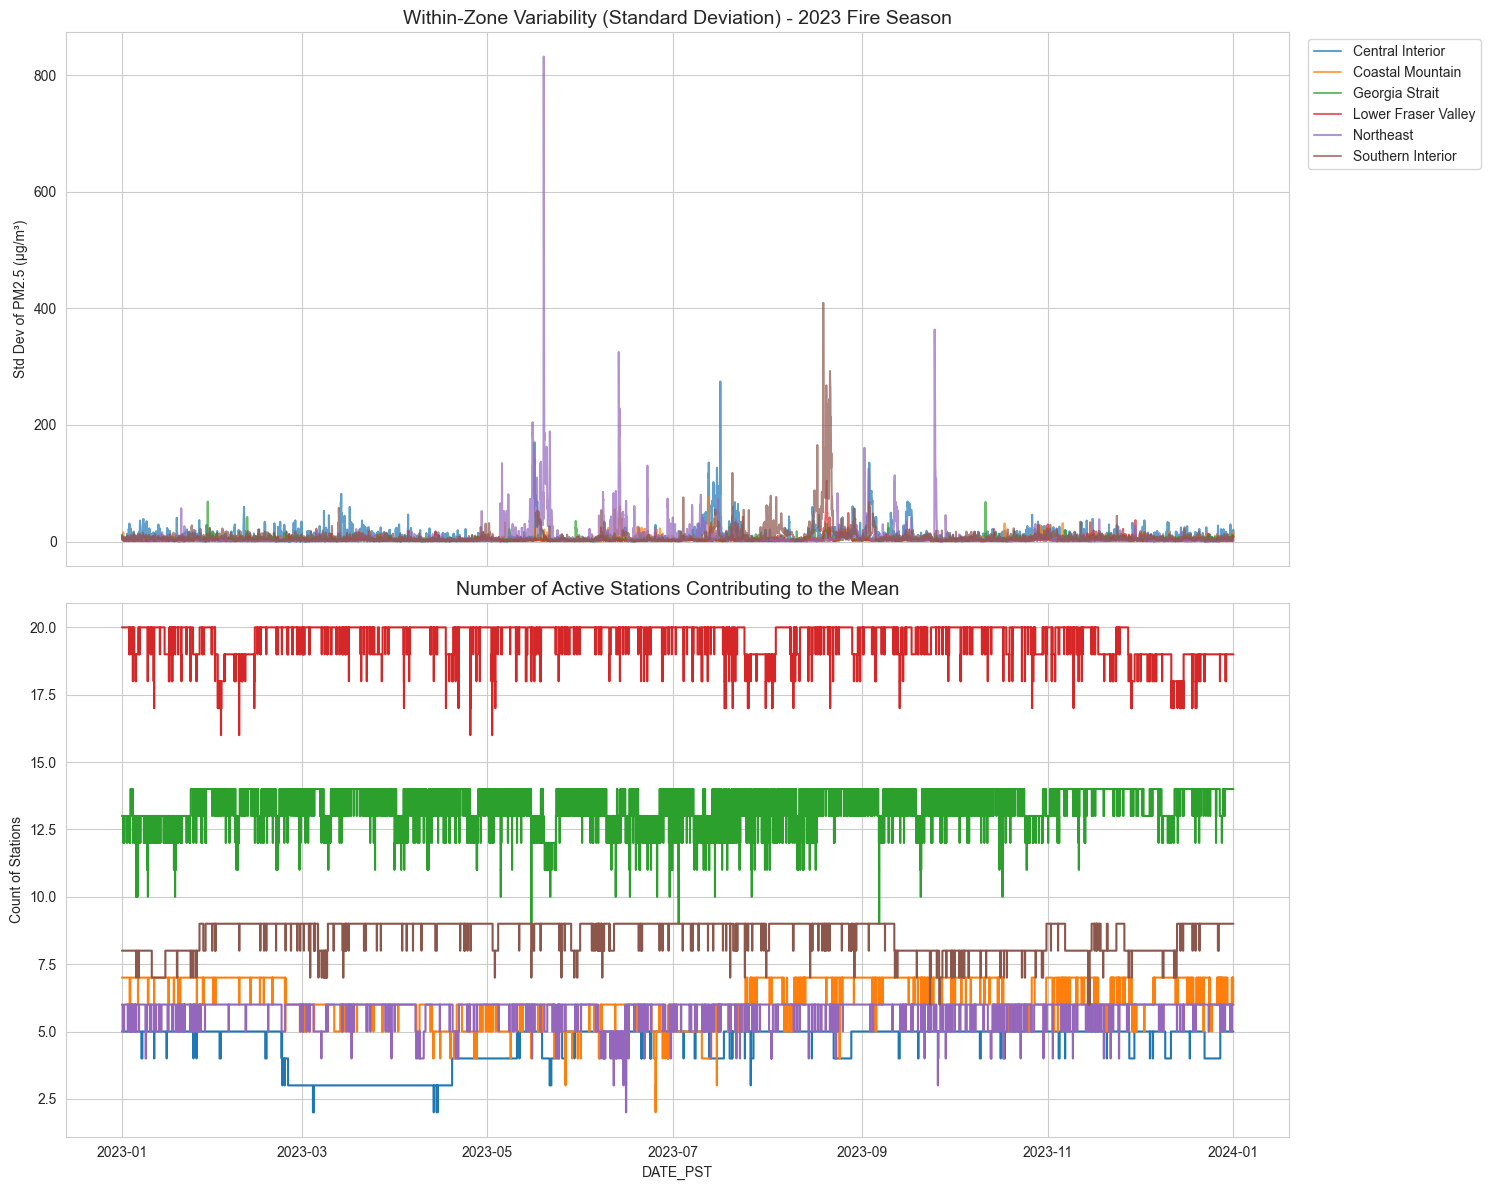

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 计算每个时间点、每个 Air Zone 的统计量
zone_stats = df_clean.groupby(['DATE_PST', 'AIRZONE'])['RAW_VALUE'].agg(
    active_stations='count',   # 这一刻有多少个站点活着
    zone_mean='mean',          # 简单平均
    zone_std='std'             # 内部差异
).reset_index()

# 2. 统计聚合后的 Missing Rate
# 如果 active_stations > 0，说明这个时刻 Zone 是有值的
total_hours = len(df_final['DATE_PST'].unique())
zone_completeness = zone_stats.groupby('AIRZONE').apply(
    lambda x: (x['active_stations'] > 0).sum() / total_hours * 100
)

print("--- 聚合后的区域数据完整度 (Zone Completeness) ---")
print(zone_completeness.sort_values())

# --- 绘图验证 ---
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# 图 1: 区域内部差异 (Standard Deviation within Zone)
# 我们只看 2023 年（火灾年），因为这时候差异通常最大
subset_2023 = zone_stats[zone_stats['DATE_PST'].dt.year == 2023]

sns.lineplot(data=subset_2023, x='DATE_PST', y='zone_std', hue='AIRZONE', alpha=0.7, ax=axes[0])
axes[0].set_title('Within-Zone Variability (Standard Deviation) - 2023 Fire Season', fontsize=14)
axes[0].set_ylabel('Std Dev of PM2.5 (μg/m³)')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# 图 2: 活跃站点数量变化 (检查是否有站点掉线导致平均值跳变)
sns.lineplot(data=subset_2023, x='DATE_PST', y='active_stations', hue='AIRZONE', drawstyle='steps-post', ax=axes[1])
axes[1].set_title('Number of Active Stations Contributing to the Mean', fontsize=14)
axes[1].set_ylabel('Count of Stations')
axes[1].legend().remove() # 图例同上

plt.tight_layout()
plt.show()

In [48]:
df_clean

,STATION_NAME,DATE_PST,RAW_VALUE,AIRZONE,LATITUDE,LONGITUDE,YEAR,MONTH,DATE,datetime,HOUR,Log_PM25
0,Abbotsford A Columbia Street,2019-01-01 01:00:00,14.903790,Lower Fraser Valley,49.02150,-122.326500,2019,1,2019-01-01,2019-01-01 01:00:00,1,2.766557
1,Abbotsford A Columbia Street,2019-01-01 02:00:00,13.804420,Lower Fraser Valley,49.02150,-122.326500,2019,1,2019-01-01,2019-01-01 02:00:00,2,2.694926
2,Abbotsford A Columbia Street,2019-01-01 03:00:00,13.216330,Lower Fraser Valley,49.02150,-122.326500,2019,1,2019-01-01,2019-01-01 03:00:00,3,2.654391
3,Abbotsford A Columbia Street,2019-01-01 04:00:00,15.966280,Lower Fraser Valley,49.02150,-122.326500,2019,1,2019-01-01,2019-01-01 04:00:00,4,2.831228
4,Abbotsford A Columbia Street,2019-01-01 05:00:00,16.609110,Lower Fraser Valley,49.02150,-122.326500,2019,1,2019-01-01,2019-01-01 05:00:00,5,2.868416
...,...,...,...,...,...,...,...,...,...,...,...,...
3908221,Williams Lake Columneetza School,2026-02-10 08:00:00,4.894731,Central Interior,52.14428,-122.150391,2026,2,2026-02-10,2026-02-10 08:00:00,8,1.774059
3908222,Williams Lake Columneetza School,2026-02-10 09:00:00,8.469566,Central Interior,52.14428,-122.150391,2026,2,2026-02-10,2026-02-10 09:00:00,9,2.248083
3908223,Williams Lake Columneetza School,2026-02-10 10:00:00,6.057776,Central Interior,52.14428,-122.150391,2026,2,2026-02-10,2026-02-10 10:00:00,10,1.954130
3908224,Williams Lake Columneetza School,2026-02-10 11:00:00,6.899682,Central Interior,52.14428,-122.150391,2026,2,2026-02-10,2026-02-10 11:00:00,11,2.066823


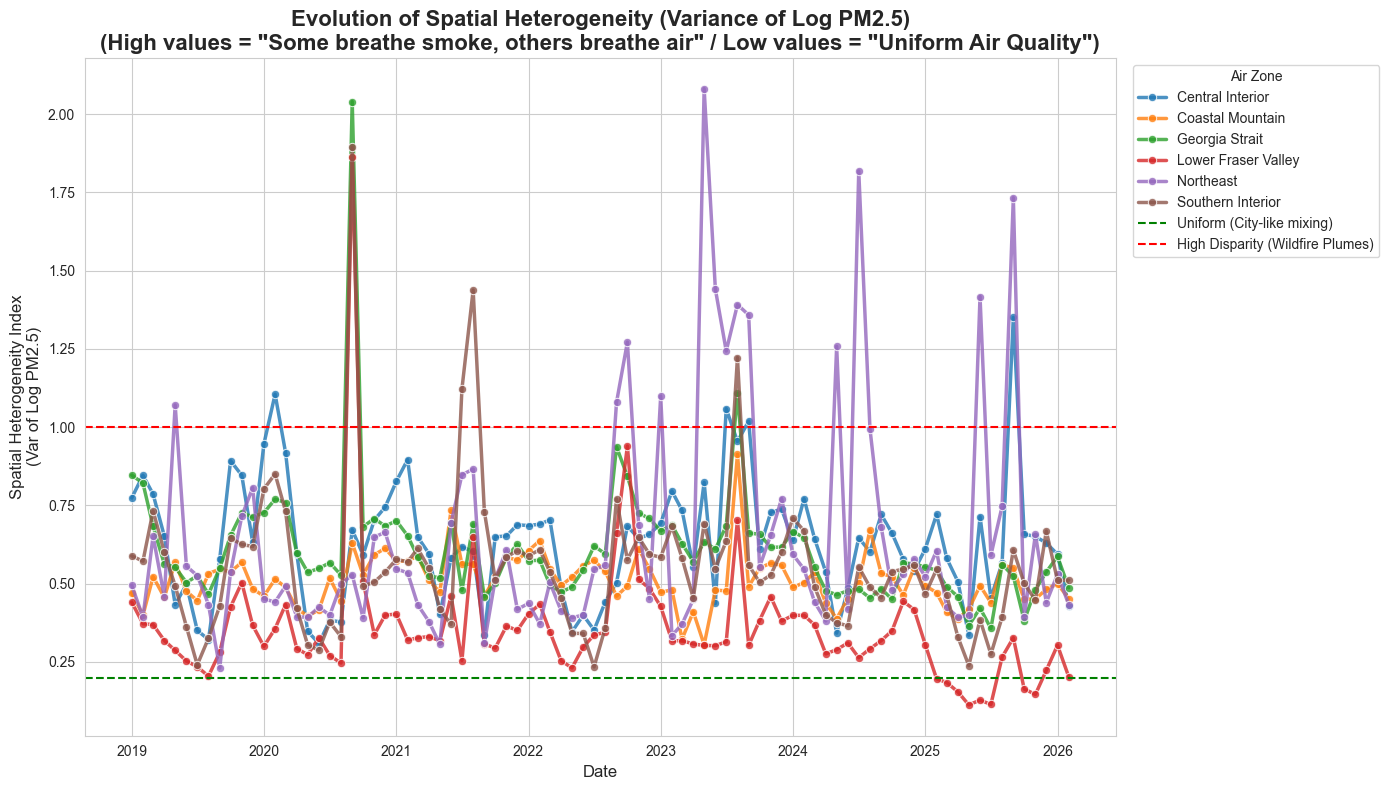

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 确保数据纯净 (剔除那6个坏站)
# 这一步至关重要，坏站点会制造虚假的方差
drop_list = ["Skookumchuck Farstad Way", "Farmington Community Hall", 
             "Valemount", "Willow Creek Mine", 
             "Prince George Plaza 400", "Vanderhoof Courthouse"]
df_clean = df_final[~df_final['STATION_NAME'].isin(drop_list)].copy()

# 2. 计算 Log PM2.5 (量级)
# 先取 Log，把 500 变成 6.2，把 5 变成 1.8
df_clean['Log_PM25'] = np.log1p(df_clean['RAW_VALUE'])

# 3. 按月计算“空间不均匀性” (Spatial Heterogeneity)
# 计算每个月、每个区域内，Log_PM25 的方差
monthly_heterogeneity = df_clean.groupby(['YEAR', 'MONTH', 'AIRZONE'])['Log_PM25'].var().reset_index()
monthly_heterogeneity.rename(columns={'Log_PM25': 'Heterogeneity_Index'}, inplace=True)

# 创建时间列用于绘图
monthly_heterogeneity['Date'] = pd.to_datetime(monthly_heterogeneity[['YEAR', 'MONTH']].assign(DAY=1))

# 4. 绘图：时序折线图
sns.set_style("whitegrid")

plt.figure(figsize=(14, 8))

# 使用折线图展示趋势
sns.lineplot(
    data=monthly_heterogeneity,
    x='Date',
    y='Heterogeneity_Index',
    hue='AIRZONE',
    palette='tab10',
    linewidth=2.5,
    marker='o',      # 标出数据点
    markersize=6,
    alpha=0.8
)

# 5. 添加辅助说明
plt.title('Evolution of Spatial Heterogeneity (Variance of Log PM2.5)\n(High values = "Some breathe smoke, others breathe air" / Low values = "Uniform Air Quality")', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Spatial Heterogeneity Index\n(Var of Log PM2.5)', fontsize=12)

# 添加阈值参考线
plt.axhline(y=0.2, color='green', linestyle='--', label='Uniform (City-like mixing)')
plt.axhline(y=1.0, color='red', linestyle='--', label='High Disparity (Wildfire Plumes)')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Air Zone')
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 确保使用清洗后的数据
if 'df_clean' not in locals():
    # 防御性代码
    # df_clean = pd.read_parquet("BC_PM25_Cleaned_v1.parquet")
    pass

# 2. 特征工程：确保 Log 转换已完成
df_clean['Log_PM25'] = np.log1p(df_clean['RAW_VALUE'])

# 3. 核心聚合：按【时间点、区域】取中位数
# 这会将数据行数从 ~300万行 (站点级) 压缩到 ~30万行 (区域级)
df_hourly_median = df_clean.groupby(['DATE_PST', 'AIRZONE'])['Log_PM25'].median().reset_index()

# 重命名列以示区分
df_hourly_median.rename(columns={'Log_PM25': 'Hourly_Median_LogPM25'}, inplace=True)

# 4. 保存这个珍贵的中间表
# 这个 CSV 文件大小适中，非常适合后续分析
df_hourly_median.to_csv("BC_PM25_Hourly_Spatial_Median.csv", index=False)
print("✅ 已计算并保存小时级空间中位数: BC_PM25_Hourly_Spatial_Median.csv")
print(f"数据形状: {df_hourly_median.shape}")
print(df_hourly_median.head())

✅ 已计算并保存小时级空间中位数: BC_PM25_Hourly_Spatial_Median.csv
数据形状: (374038, 3)
             DATE_PST              AIRZONE  Hourly_Median_LogPM25
0 2019-01-01 01:00:00     Central Interior               1.705184
1 2019-01-01 01:00:00     Coastal Mountain               1.296808
2 2019-01-01 01:00:00       Georgia Strait               3.455226
3 2019-01-01 01:00:00  Lower Fraser Valley               2.626532
4 2019-01-01 01:00:00            Northeast               0.479687


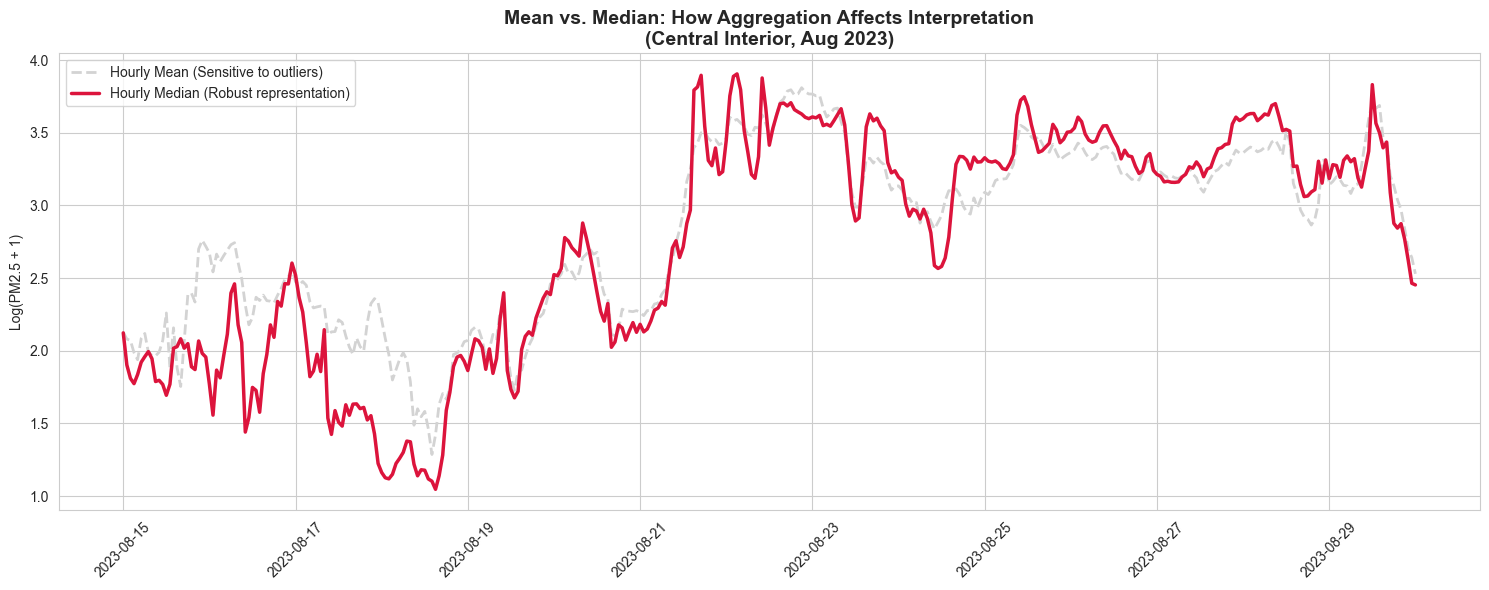

In [52]:
# 选取一个典型的火灾严重区域 (比如 Central Interior) 和时间段
target_zone = 'Central Interior'
start_date = '2023-08-15'
end_date = '2023-08-30'

# 1. 准备均值数据作为对比
zone_mean = df_clean[
    (df_clean['AIRZONE'] == target_zone) & 
    (df_clean['DATE_PST'].between(start_date, end_date))
].groupby('DATE_PST')['Log_PM25'].mean()

# 2. 准备中位数数据 (刚才算好的)
zone_median = df_hourly_median[
    (df_hourly_median['AIRZONE'] == target_zone) & 
    (df_hourly_median['DATE_PST'].between(start_date, end_date))
].set_index('DATE_PST')['Hourly_Median_LogPM25']

# 3. 绘图对比
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

plt.plot(zone_mean.index, zone_mean, color='lightgray', linewidth=2, linestyle='--', label='Hourly Mean (Sensitive to outliers)')
plt.plot(zone_median.index, zone_median, color='crimson', linewidth=2.5, label='Hourly Median (Robust representation)')

plt.title(f'Mean vs. Median: How Aggregation Affects Interpretation\n({target_zone}, Aug 2023)', fontsize=14, fontweight='bold')
plt.ylabel('Log(PM2.5 + 1)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 假设你已经有了 df_hourly_median
# 如果没有，请先加载你刚才保存的文件
# df_hourly_median = pd.read_csv("BC_PM25_Hourly_Spatial_Median.csv", parse_dates=['DATE_PST'])

# 2. 数据透视与重采样 (关键步骤)
# 我们必须把“隐形的缺失”（时间断档）变成“显形的 NaN”
pivot_df = df_hourly_median.pivot(
    index='DATE_PST', 
    columns='AIRZONE', 
    values='Hourly_Median_LogPM25'
)

# 生成完整的时间轴 (从开始到结束，每小时一格)
full_idx = pd.date_range(start=pivot_df.index.min(), end=pivot_df.index.max(), freq='H')
pivot_df = pivot_df.reindex(full_idx)

# 3. 计算缺失统计量
missing_stats = pivot_df.isna().mean() * 100
print("--- 各区域聚合后的小时级缺失率 (%) ---")
print(missing_stats.sort_values(ascending=False))


--- 各区域聚合后的小时级缺失率 (%) ---
AIRZONE
Lower Fraser Valley    0.338466
Central Interior       0.003208
Northeast              0.001604
Southern Interior      0.001604
Coastal Mountain       0.000000
Georgia Strait         0.000000
dtype: float64


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/1056608828.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(start=pivot_df.index.min(), end=pivot_df.index.max(), freq='H')


In [57]:
import pandas as pd
import numpy as np

# 1. 准备数据：转为宽表 (Wide Format)
# 行=时间, 列=区域, 值=Log_PM25中位数
df_wide = df_hourly_median.pivot(
    index='DATE_PST', 
    columns='AIRZONE', 
    values='Hourly_Median_LogPM25'
)

# 2. 建立完整的时间骨架 (Full Hourly Index)
# 这一步能把那些“隐形”的缺失时间点暴露出来，变成 NaN
full_idx = pd.date_range(start=df_wide.index.min(), end=df_wide.index.max(), freq='H')
df_wide = df_wide.reindex(full_idx)

# 3. 执行插值 (Linear Interpolation)
# method='time': 根据时间距离进行插值 (处理非等间距缺失时最准确，虽然后里是等间距的)
# limit_direction='both': 头尾如果缺了也补上
df_imputed = df_wide.interpolate(method='time', limit_direction='both')

# 4. 最终体检
print("--- 最终完整性检查 (Target: 0) ---")
print(df_imputed.isna().sum())

# 5. 保存为“建模专用矩阵”
# index_label='Date': 确保第一列有名字
df_imputed.to_csv("BC_PM25_Final_Matrix_Imputed.csv", index_label='Date')

print("\n✅ 数据已完美补全！")
print(f"保存路径: BC_PM25_Final_Matrix_Imputed.csv")
print(f"时间范围: {df_imputed.index.min()} 至 {df_imputed.index.max()}")
print(f"总小时数: {len(df_imputed)}")
print("现在，所有区域都是 100% 完整的，可以直接喂给 SARIMA 模型了。")

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/333197992.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(start=df_wide.index.min(), end=df_wide.index.max(), freq='H')


--- 最终完整性检查 (Target: 0) ---
AIRZONE
Central Interior       0
Coastal Mountain       0
Georgia Strait         0
Lower Fraser Valley    0
Northeast              0
Southern Interior      0
dtype: int64

✅ 数据已完美补全！
保存路径: BC_PM25_Final_Matrix_Imputed.csv
时间范围: 2019-01-01 01:00:00 至 2026-02-10 12:00:00
总小时数: 62340
现在，所有区域都是 100% 完整的，可以直接喂给 SARIMA 模型了。


In [73]:
df_imputed

AIRZONE,Central Interior,Coastal Mountain,Georgia Strait,Lower Fraser Valley,Northeast,Southern Interior
2019-01-01 01:00:00,1.705184,1.296808,3.455226,2.626532,0.479687,3.348351
2019-01-01 02:00:00,1.771578,1.051050,3.433987,2.469588,0.354538,3.093402
2019-01-01 03:00:00,1.676538,1.700599,3.433987,2.406862,0.622932,3.204917
2019-01-01 04:00:00,2.115041,1.354025,3.295837,2.397335,0.619321,3.114750
2019-01-01 05:00:00,1.694164,0.895880,3.218876,2.354927,0.450588,3.056461
...,...,...,...,...,...,...
2026-02-10 08:00:00,2.158007,1.098612,1.479865,1.504077,1.947984,1.948716
2026-02-10 09:00:00,2.388524,1.386294,1.675429,1.531322,2.098636,2.122448
2026-02-10 10:00:00,1.633901,1.386294,1.583723,1.424509,1.886921,1.608515
2026-02-10 11:00:00,1.706915,0.757832,0.876614,1.350307,1.593633,1.457543


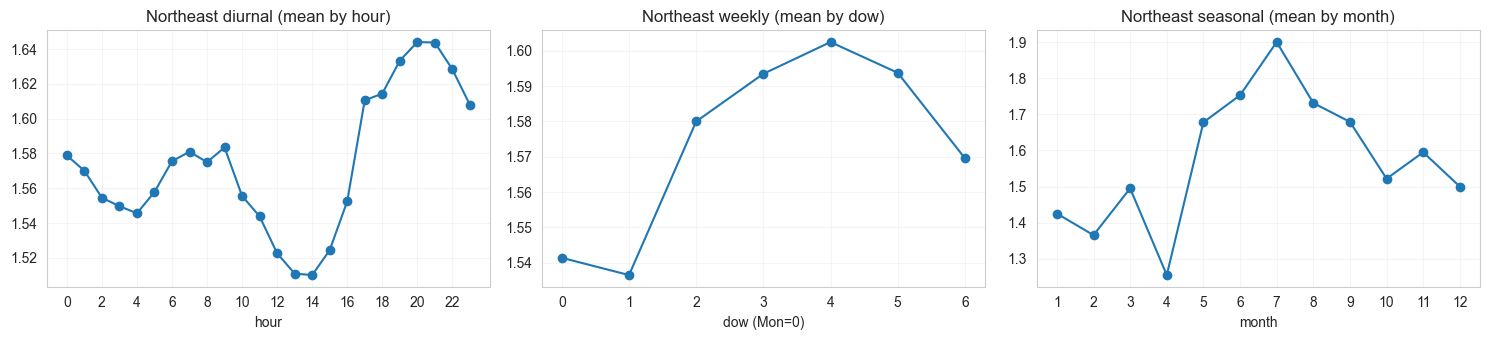

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

zone = "Northeast"  # 换成任意列名
y = df_imputed[zone].copy()

# 1) 日内：按小时平均
hour_mean = y.groupby(y.index.hour).mean()

# 2) 周内：按星期几平均（0=周一）
dow_mean = y.groupby(y.index.dayofweek).mean()

# 3) 年内：按一年中的日子平均（建议先按月更稳）
month_mean = y.groupby(y.index.month).mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].plot(hour_mean.index, hour_mean.values, marker='o')
axes[0].set_title(f"{zone} diurnal (mean by hour)")
axes[0].set_xlabel("hour"); axes[0].grid(alpha=0.2); axes[0].set_xticks(range(0,24,2))

axes[1].plot(dow_mean.index, dow_mean.values, marker='o')
axes[1].set_title(f"{zone} weekly (mean by dow)")
axes[1].set_xlabel("dow (Mon=0)"); axes[1].grid(alpha=0.2); axes[1].set_xticks(range(7))

axes[2].plot(month_mean.index, month_mean.values, marker='o')
axes[2].set_title(f"{zone} seasonal (mean by month)")
axes[2].set_xlabel("month"); axes[2].grid(alpha=0.2); axes[2].set_xticks(range(1,13))

plt.tight_layout()
plt.show()


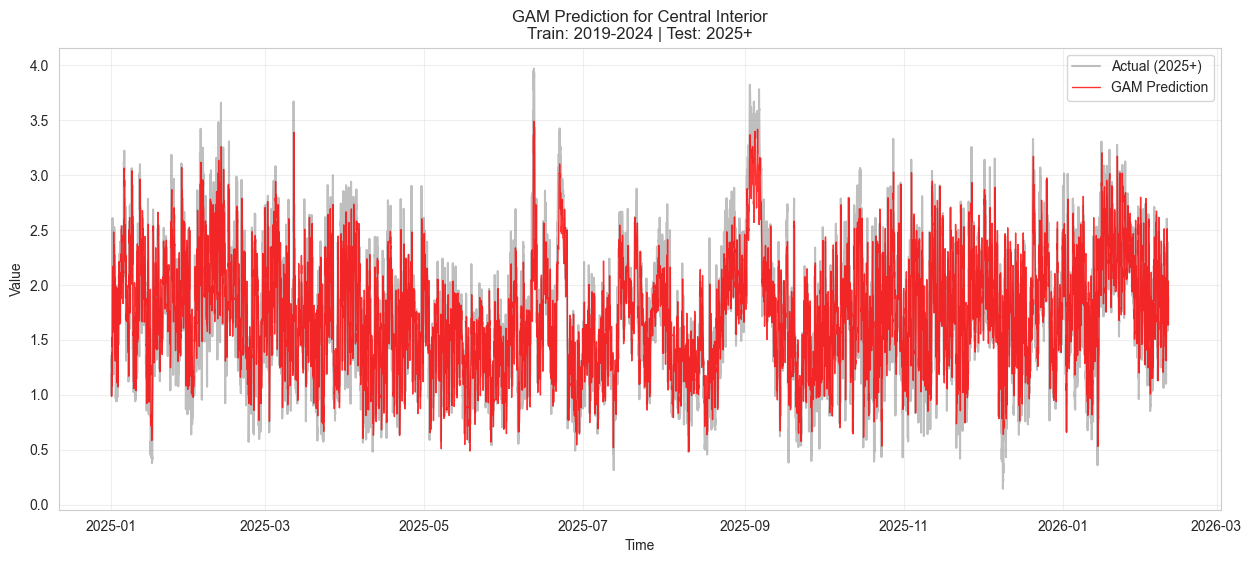

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     50.8045
Link Function:                     IdentityLink Log Likelihood:                                -24614.5772
Number of Samples:                        52604 AIC:                                            49332.7633
                                                AICc:                                           49332.8674
                                                GCV:                                                0.1497
                                                Scale:                                              0.3865
                                                Pseudo R-Squared:                                   0.6674
Feature Function                  Lam

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/943480602.py:67: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, f

# --- 假设 df_imputed 已经在内存中 ---
# 目标列
target_col = 'Central Interior' 

# 1. 特征工程
data = df_imputed[[target_col]].copy()
data.rename(columns={target_col: 'y'}, inplace=True)

# 构造滞后特征：使用3小时前的数据 (t-3) 预测现在 (t)
data['lag_3'] = data['y'].shift(3)

# 构造时间规律特征
data['hour'] = data.index.hour           # 日内 (0-23)
data['weekday'] = data.index.dayofweek   # 周内 (0-6)
data['dayofyear'] = data.index.dayofyear # 季节 (1-366)

# 去除因 shift 产生的头部空值
data.dropna(inplace=True)

# 2. 数据集划分 (严格修正：训练集包含 2024 全年)
# 训练集：2019-01-01 00:00:00 到 2024-12-31 23:00:00
train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')

# 预测集：2025-01-01 以后
test_mask = data.index >= '2025-01-01'

X_train = data.loc[train_mask, ['lag_3', 'hour', 'weekday', 'dayofyear']]
y_train = data.loc[train_mask, 'y']

X_test = data.loc[test_mask, ['lag_3', 'hour', 'weekday', 'dayofyear']]
y_test = data.loc[test_mask, 'y']

# 3. 建立 GAM 模型 (修正：移除 cyclic 参数)
# s(0): lag_3
# s(1): hour
# s(2): weekday
# s(3): dayofyear
# n_splines 可以根据特征的粒度调整，例如小时设为 20 左右，季节设为 12-20
gam = LinearGAM(
    s(0) + 
    s(1, n_splines=20) + 
    s(2, n_splines=7) + 
    s(3, n_splines=12)
).fit(X_train, y_train)

# 4. 预测与绘图 (2025年以后)
predictions = gam.predict(X_test)

plt.figure(figsize=(15, 6))
# 画出真实值
plt.plot(y_test.index, y_test, label='Actual (2025+)', color='gray', alpha=0.5)
# 画出预测值
plt.plot(y_test.index, predictions, label='GAM Prediction', color='red', alpha=0.8, linewidth=1)

plt.title(f'GAM Prediction for {target_col}\nTrain: 2019-2024 | Test: 2025+')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 查看模型统计信息
print(gam.summary())

--- 2025-01 局部评估 ---
MSE: 0.1503
R² : 0.5087


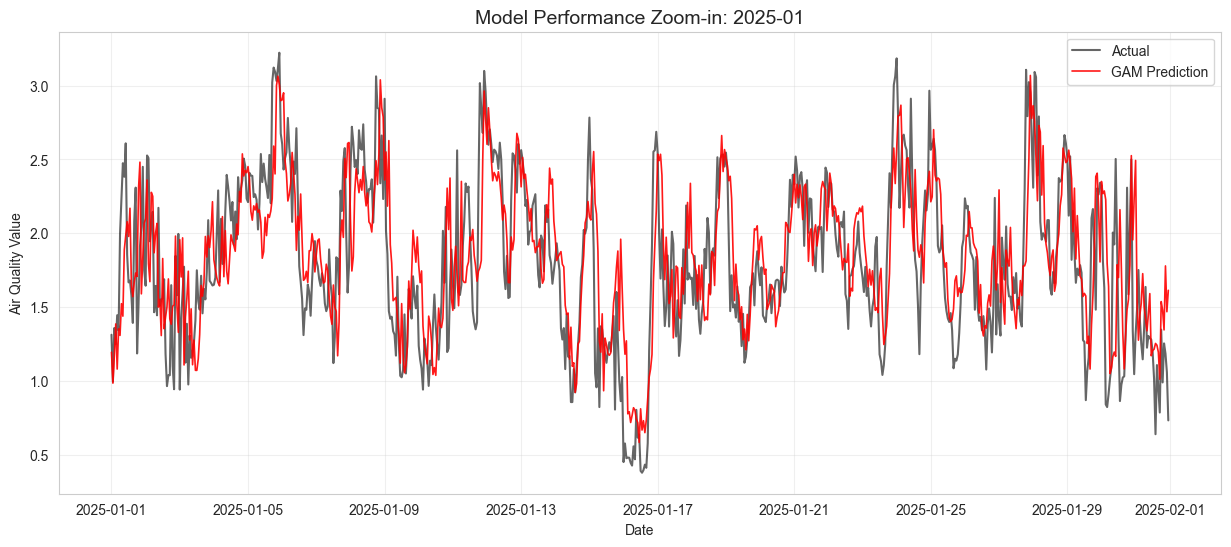

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 将预测结果和真实值对齐放入一个 DataFrame，方便切片
# 注意：确保这里的 y_test 和 predictions 是上一段代码生成的
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
}, index=y_test.index)

# 2. 选择具体的一个月进行观察 (例如 2025年1月)
target_month = '2025-01' 
subset = results_df.loc[target_month]

# 3. 绘图
plt.figure(figsize=(15, 6))

# 画真实值 (灰色，稍粗)
plt.plot(subset.index, subset['Actual'], 
         label='Actual', color='black', alpha=0.6, linewidth=1.5)

# 画预测值 (红色，稍细)
plt.plot(subset.index, subset['Predicted'], 
         label='GAM Prediction', color='red', alpha=0.9, linewidth=1.2)

# 标注
plt.title(f'Model Performance Zoom-in: {target_month}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Air Quality Value')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. 计算这个月的局部误差指标 (可选)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(subset['Actual'], subset['Predicted'])
r2 = r2_score(subset['Actual'], subset['Predicted'])
print(f"--- {target_month} 局部评估 ---")
print(f"MSE: {mse:.4f}")
print(f"R² : {r2:.4f}")

plt.show()

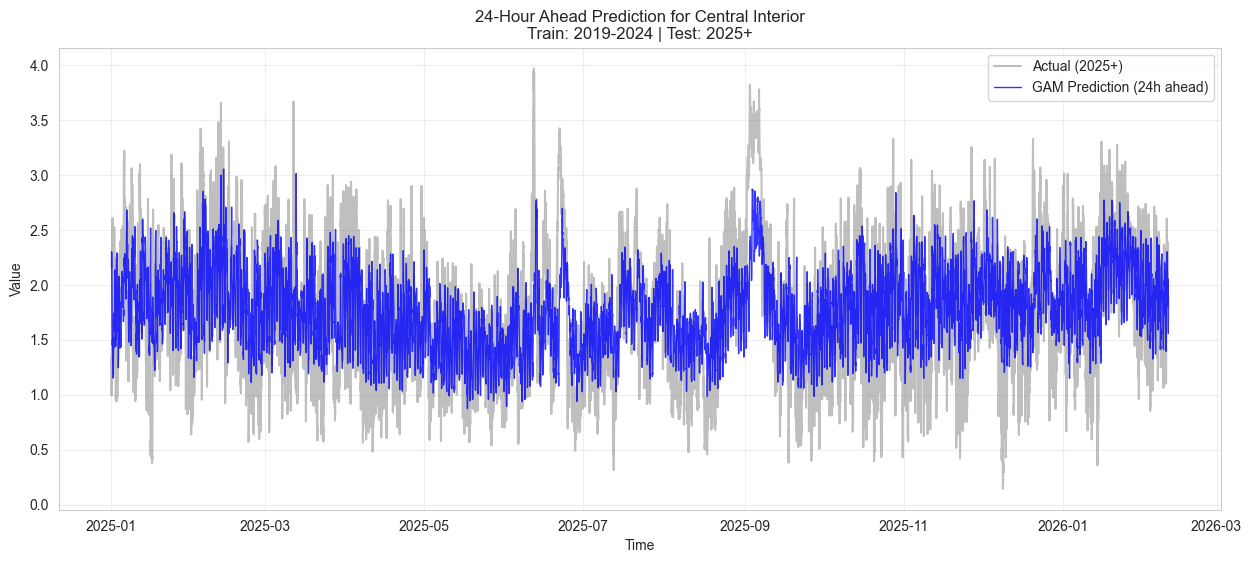

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     50.8013
Link Function:                     IdentityLink Log Likelihood:                                 -42258.615
Number of Samples:                        52583 AIC:                                            84620.8325
                                                AICc:                                           84620.9366
                                                GCV:                                                0.2929
                                                Scale:                                              0.5407
                                                Pseudo R-Squared:                                    0.349
Feature Function                  Lam

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/1432225257.py:62: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, f

# --- 假设 df_imputed 已经在内存中 ---
target_col = 'Central Interior' 

# 1. 特征工程
data = df_imputed[[target_col]].copy()
data.rename(columns={target_col: 'y'}, inplace=True)

# 【核心修改】：构造24小时滞后特征 (t-24) 用于预测 (t)
data['lag_24'] = data['y'].shift(24)

# 构造时间规律特征 (保持不变)
data['hour'] = data.index.hour           
data['weekday'] = data.index.dayofweek   
data['dayofyear'] = data.index.dayofyear 

# 去除因 shift(24) 产生的头部24个空值
data.dropna(inplace=True)

# 2. 数据集划分 (保持不变)
# 训练集：2019-2024
train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
# 预测集：2025以后
test_mask = data.index >= '2025-01-01'

X_train = data.loc[train_mask, ['lag_24', 'hour', 'weekday', 'dayofyear']]
y_train = data.loc[train_mask, 'y']

X_test = data.loc[test_mask, ['lag_24', 'hour', 'weekday', 'dayofyear']]
y_test = data.loc[test_mask, 'y']

# 3. 建立 GAM 模型
# s(0) 现在代表 lag_24 的影响
# s(1) hour, s(2) weekday, s(3) dayofyear 保持参数不变
gam = LinearGAM(
    s(0) + 
    s(1, n_splines=20) + 
    s(2, n_splines=7) + 
    s(3, n_splines=12)
).fit(X_train, y_train)

# 4. 预测与绘图
predictions = gam.predict(X_test)

plt.figure(figsize=(15, 6))
# 真实值
plt.plot(y_test.index, y_test, label='Actual (2025+)', color='gray', alpha=0.5)
# 预测值
plt.plot(y_test.index, predictions, label='GAM Prediction (24h ahead)', color='blue', alpha=0.8, linewidth=1)

plt.title(f'24-Hour Ahead Prediction for {target_col}\nTrain: 2019-2024 | Test: 2025+')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. 输出模型概况与局部细节
print(gam.summary())

# 计算简单的评价指标对比
from sklearn.metrics import r2_score
print(f"Pseudo R-Squared (Train): {gam.statistics_['pseudo_r2']['explained_deviance']:.4f}")
print(f"R-Squared (Test 2025+): {r2_score(y_test, predictions):.4f}")

In [78]:
from sklearn.metrics import r2_score

# 1. 获取必要参数
# n: 样本数量 (2025年以后的数据行数)
n = len(y_test)

# p: 模型使用的有效自由度 (Effective Degrees of Freedom)
# pygam 会自动计算这个值，代表模型实际上用了多少“参数”
p = gam.statistics_['edof'] 

# R2: 普通 R-Squared
r2 = r2_score(y_test, predictions)

# 2. 计算 Adjusted R-Squared 公式
# Adj_R2 = 1 - (1 - R2) * ( (n - 1) / (n - p - 1) )
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Sample Size (n): {n}")
print(f"Effective DoF (p): {p:.2f}")
print("-" * 30)
print(f"R-Squared:          {r2:.6f}")
print(f"Adjusted R-Squared: {adj_r2:.6f}")

# 3. 判定
if abs(r2 - adj_r2) < 0.01:
    print("\n[结论] 两者几乎相等。说明模型没有因为'特征过多'而虚高 R2。")
    print("当前 0.31 的分数低并不是因为过拟合，而是因为 24小时后的天气变化确实难以仅靠历史规律预测。")
else:
    print("\n[结论] 差距较大，模型可能过于复杂。")

Sample Size (n): 9733
Effective DoF (p): 50.80
------------------------------
R-Squared:          0.314768
Adjusted R-Squared: 0.311173

[结论] 两者几乎相等。说明模型没有因为'特征过多'而虚高 R2。
当前 0.31 的分数低并不是因为过拟合，而是因为 24小时后的天气变化确实难以仅靠历史规律预测。


开始训练 6 个区域的 GAM 模型 (Train: 2019-2024, Predict: 2025+)...

正在处理: Central Interior (1/6)...
正在处理: Coastal Mountain (2/6)...
正在处理: Georgia Strait (3/6)...
正在处理: Lower Fraser Valley (4/6)...
正在处理: Northeast (5/6)...
正在处理: Southern Interior (6/6)...


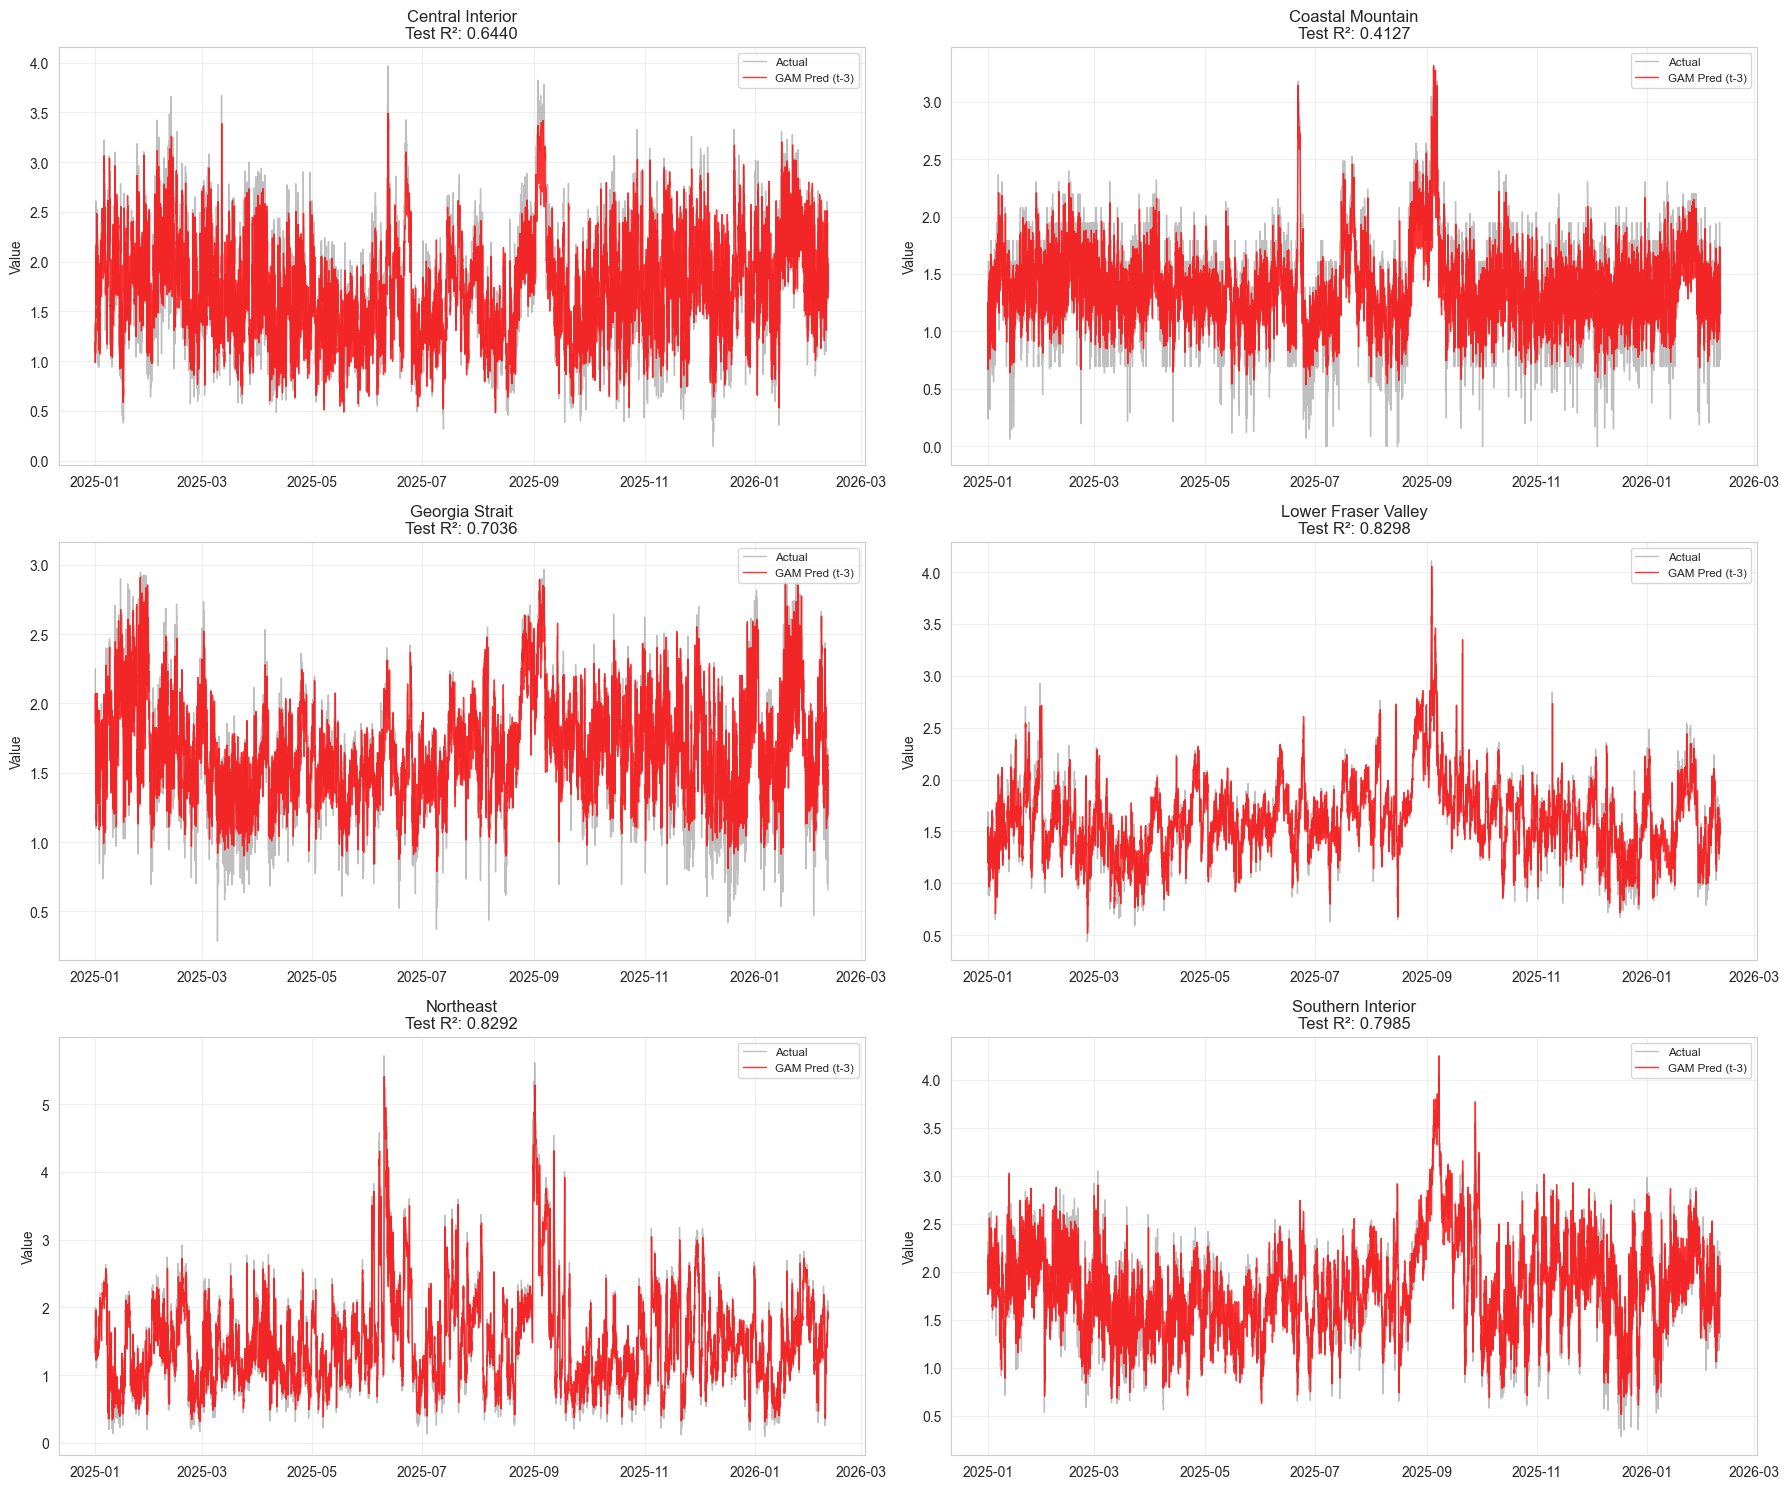


=== 模型性能汇总 (按 R² 排序) ===
                Region  Test R2 (2025+)  Test MSE
3  Lower Fraser Valley         0.829760  0.025670
4            Northeast         0.829159  0.101317
5    Southern Interior         0.798451  0.057766
2       Georgia Strait         0.703644  0.052534
0     Central Interior         0.644046  0.133218
1     Coastal Mountain         0.412658  0.105429


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from pygam import LinearGAM, s, f
from sklearn.metrics import r2_score, mean_squared_error

# --- 假设 df_imputed 已经在内存中 ---

# 1. 获取所有需要预测的区域列名
target_columns = df_imputed.columns.tolist()
n_targets = len(target_columns)

# 2. 设置画布布局 (自动计算行数，每行放2张图)
n_cols = 2
n_rows = math.ceil(n_targets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() # 展平方便索引

# 用于存储每个区域的模型评分
metrics_summary = []

print(f"开始训练 {n_targets} 个区域的 GAM 模型 (Train: 2019-2024, Predict: 2025+)...\n")

for i, region in enumerate(target_columns):
    print(f"正在处理: {region} ({i+1}/{n_targets})...")
    
    # --- A. 数据准备 (与之前逻辑完全一致) ---
    data = df_imputed[[region]].copy()
    data.rename(columns={region: 'y'}, inplace=True)
    
    # 特征工程：滞后3小时 + 时间规律
    data['lag_3'] = data['y'].shift(3)
    data['hour'] = data.index.hour
    data['weekday'] = data.index.dayofweek
    data['dayofyear'] = data.index.dayofyear
    
    data.dropna(inplace=True)
    
    # --- B. 数据划分 ---
    # 训练集：2019-01-01 至 2024-12-31
    train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
    # 预测集：2025-01-01 以后
    test_mask = data.index >= '2025-01-01'
    
    X_train = data.loc[train_mask, ['lag_3', 'hour', 'weekday', 'dayofyear']]
    y_train = data.loc[train_mask, 'y']
    
    X_test = data.loc[test_mask, ['lag_3', 'hour', 'weekday', 'dayofyear']]
    y_test = data.loc[test_mask, 'y']
    
    # --- C. 建立并训练 GAM 模型 ---
    # s(0): lag_3, s(1): hour(20), s(2): weekday(7), s(3): season(12)
    gam = LinearGAM(
        s(0) + 
        s(1, n_splines=20) + 
        s(2, n_splines=7) + 
        s(3, n_splines=12)
    ).fit(X_train, y_train)
    
    # --- D. 预测与评估 ---
    predictions = gam.predict(X_test)
    
    # 计算 R2 (测试集)
    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    
    metrics_summary.append({
        'Region': region,
        'Test R2 (2025+)': r2,
        'Test MSE': mse
    })
    
    # --- E. 绘图 (绘制在对应的子图上) ---
    ax = axes[i]
    # 画真实值 (2025+)
    ax.plot(y_test.index, y_test, label='Actual', color='gray', alpha=0.5, linewidth=1)
    # 画预测值
    ax.plot(y_test.index, predictions, label='GAM Pred (t-3)', color='red', alpha=0.8, linewidth=1)
    
    ax.set_title(f'{region}\nTest R²: {r2:.4f}')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, alpha=0.3)

# 处理多余的空白子图 (如果有的话)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- F. 输出评分汇总表 ---
metrics_df = pd.DataFrame(metrics_summary).sort_values(by='Test R2 (2025+)', ascending=False)
print("\n=== 模型性能汇总 (按 R² 排序) ===")
print(metrics_df)

正在生成 2026-01-01 至 2026-01-07 的预测对比图...


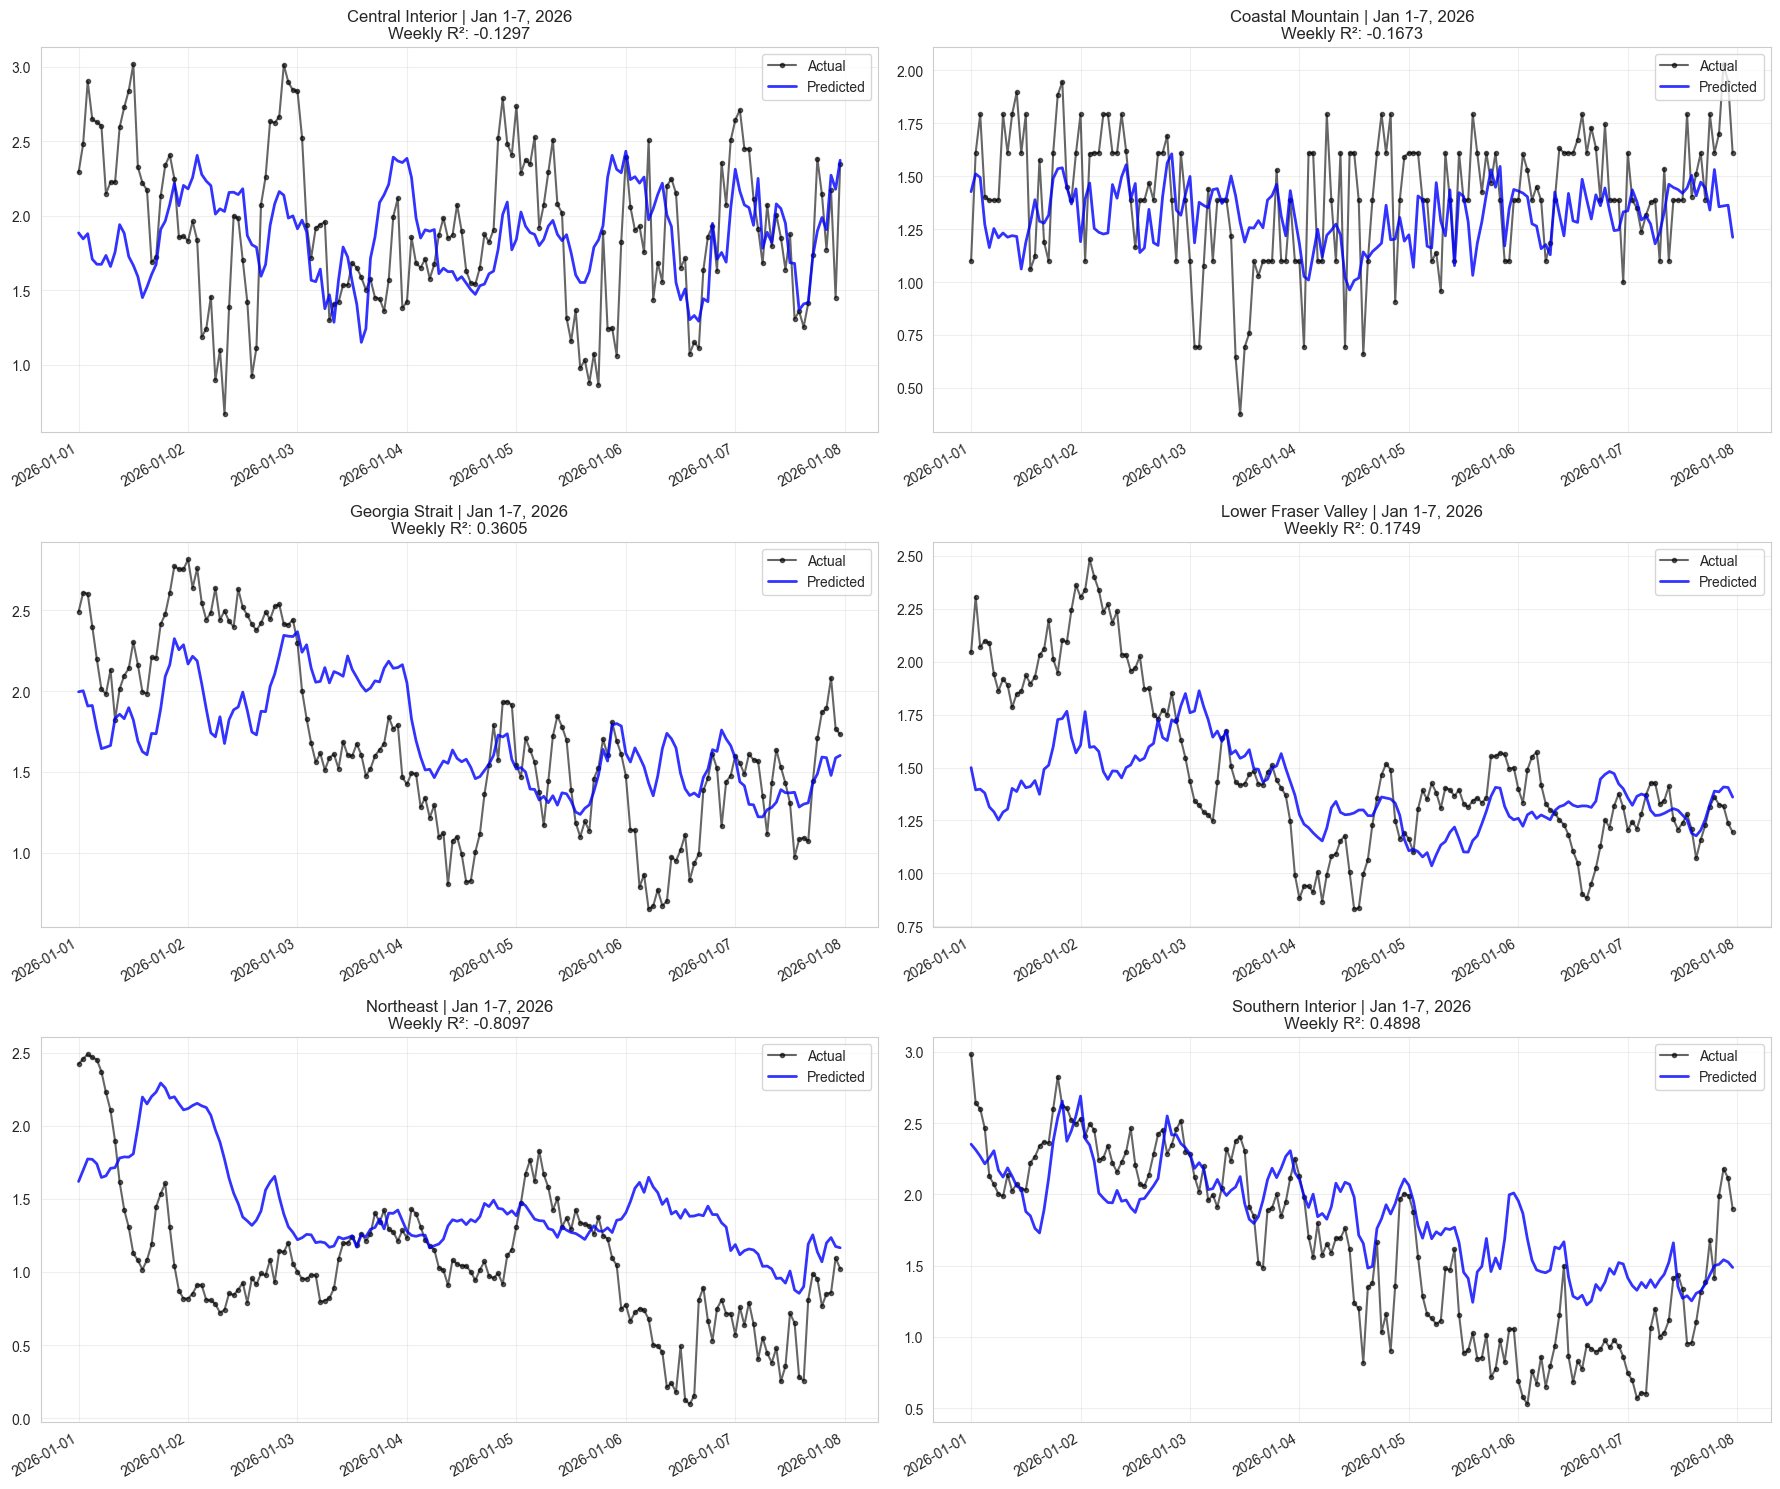

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from pygam import LinearGAM, s
from sklearn.metrics import r2_score

# --- 假设 df_imputed 已经在内存中 ---

target_columns = df_imputed.columns.tolist()
n_targets = len(target_columns)

# 设置 2026 年 1 月第一周的绘图区间
plot_start = '2026-01-01'
plot_end = '2026-01-07 23:59:59'

# 设置画布布局
n_cols = 2
n_rows = math.ceil(n_targets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

print(f"正在生成 2026-01-01 至 2026-01-07 的预测对比图...")

for i, region in enumerate(target_columns):
    # --- A. 数据处理 (保持 lag_24 预测一天以后) ---
    data = df_imputed[[region]].copy()
    data.rename(columns={region: 'y'}, inplace=True)
    data['lag_24'] = data['y'].shift(24)
    data['hour'] = data.index.hour
    data['weekday'] = data.index.dayofweek
    data['dayofyear'] = data.index.dayofyear
    data.dropna(inplace=True)
    
    # --- B. 数据划分 ---
    train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
    test_mask = data.index >= '2025-01-01'
    
    X_train = data.loc[train_mask, ['lag_24', 'hour', 'weekday', 'dayofyear']]
    y_train = data.loc[train_mask, 'y']
    X_test = data.loc[test_mask, ['lag_24', 'hour', 'weekday', 'dayofyear']]
    y_test = data.loc[test_mask, 'y']
    
    # --- C. 训练模型 ---
    gam = LinearGAM(s(0) + s(1, n_splines=20) + s(2, n_splines=7) + s(3, n_splines=12)).fit(X_train, y_train)
    
    # --- D. 预测并切片 (关键步骤) ---
    full_preds = gam.predict(X_test)
    results = pd.DataFrame({'Actual': y_test, 'Predicted': full_preds}, index=y_test.index)
    
    # 仅提取 2026-01-01 到 2026-01-07 的数据
    weekly_subset = results.loc[plot_start:plot_end]
    
    # 计算该周内的局部 R2
    weekly_r2 = r2_score(weekly_subset['Actual'], weekly_subset['Predicted'])
    
    # --- E. 绘图 ---
    ax = axes[i]
    ax.plot(weekly_subset.index, weekly_subset['Actual'], label='Actual', color='black', alpha=0.6, marker='o', markersize=3)
    ax.plot(weekly_subset.index, weekly_subset['Predicted'], label='Predicted', color='blue', alpha=0.8, linewidth=2)
    
    ax.set_title(f'{region} | Jan 1-7, 2026\nWeekly R²: {weekly_r2:.4f}', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    # 自动旋转日期标签防止重叠
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 清理多余图表
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

正在生成 3小时提前预测对比图 (区间: 2026-01-01 至 2026-01-07)...


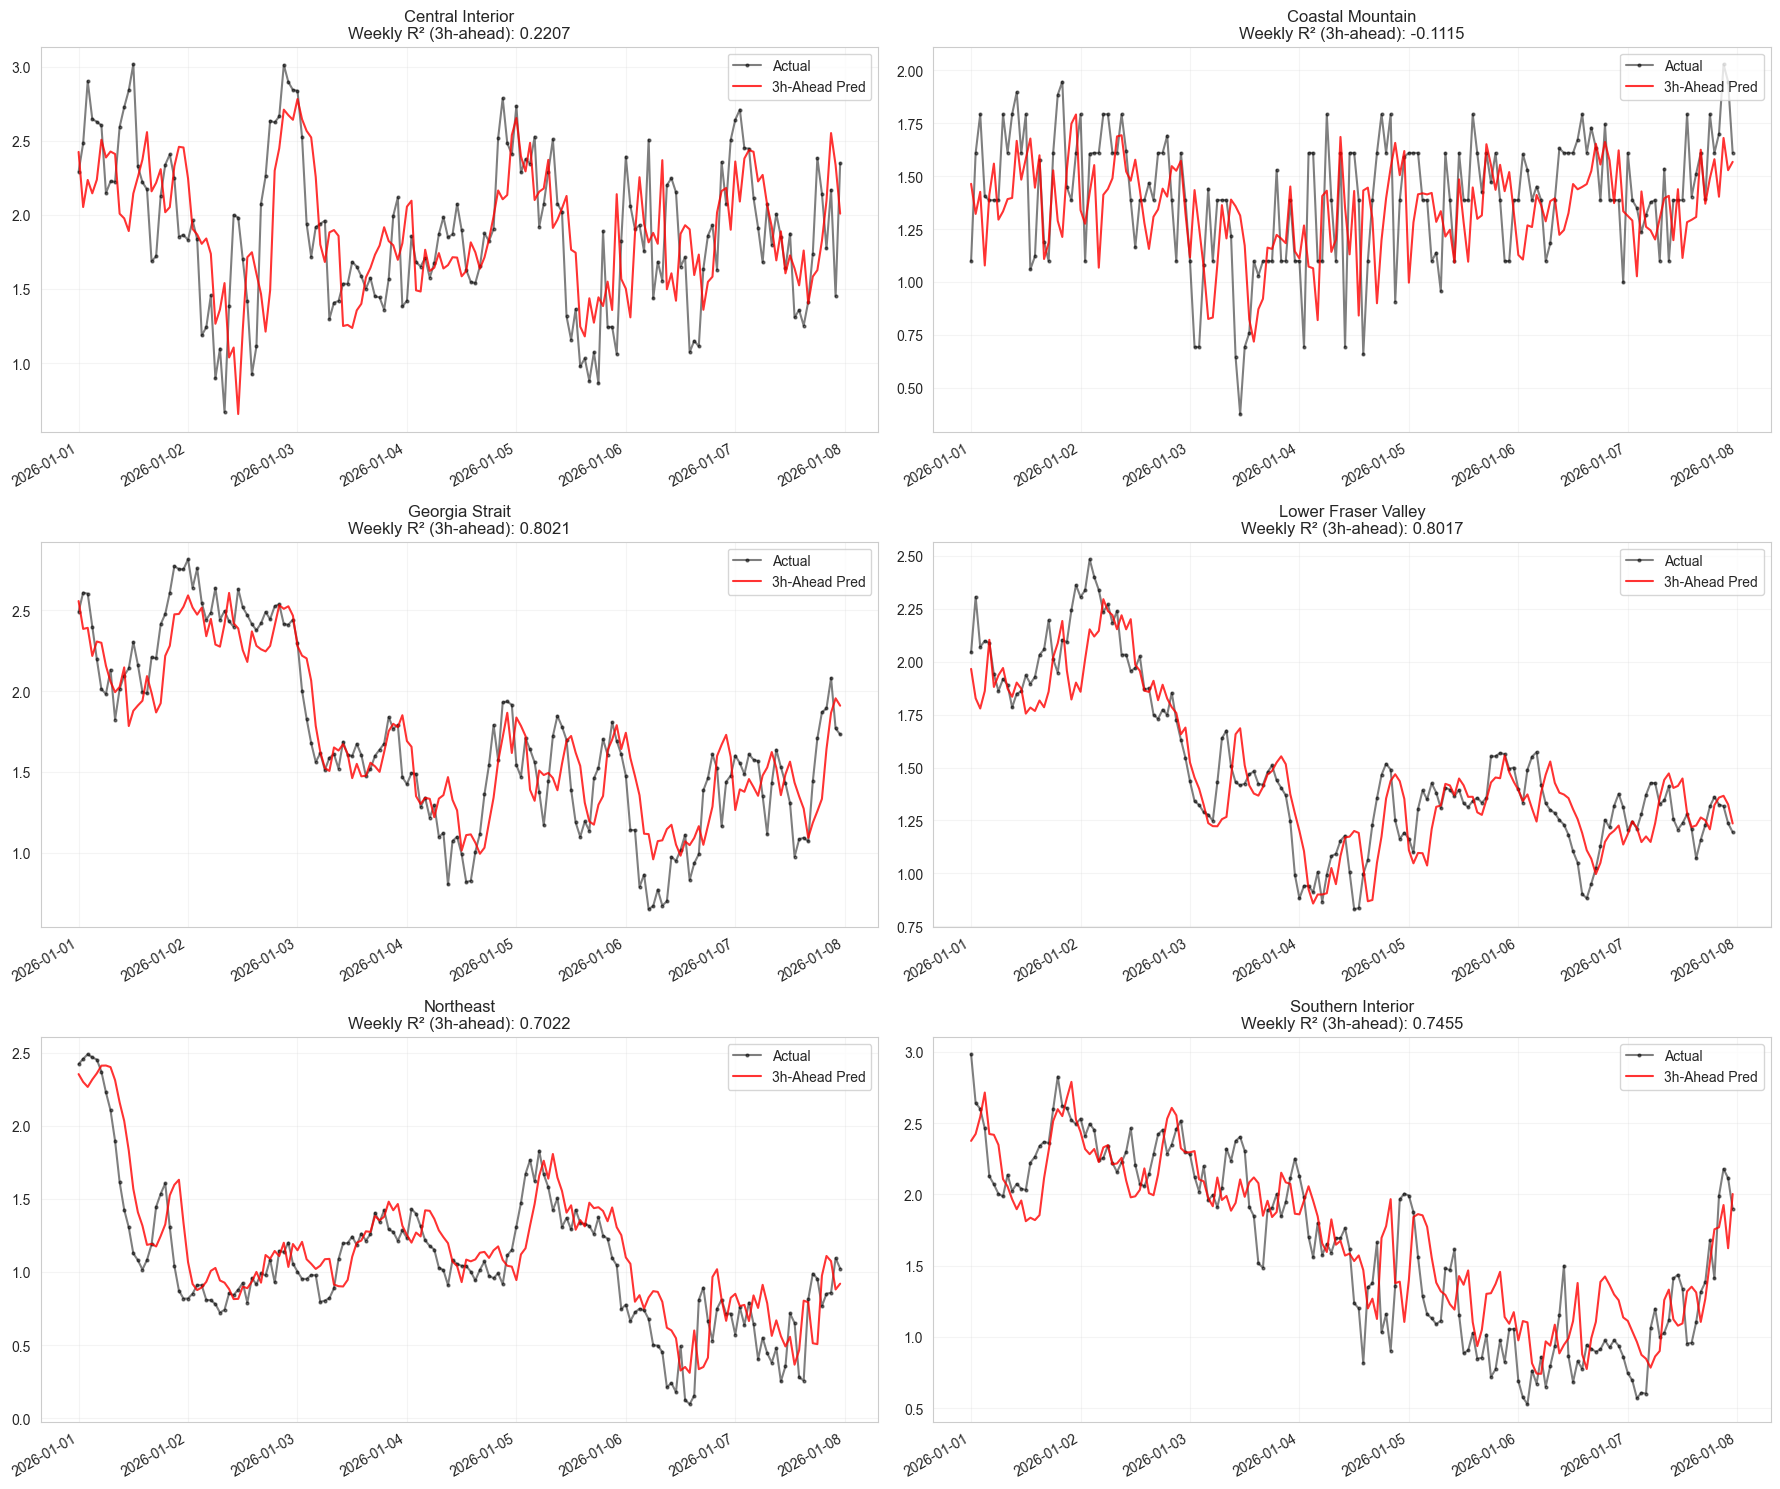

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from pygam import LinearGAM, s
from sklearn.metrics import r2_score

# --- 假设 df_imputed 已经在内存中 ---

target_columns = df_imputed.columns.tolist()
n_targets = len(target_columns)

# 定义观察时间：2026年1月1日到7日
plot_start = '2026-01-01'
plot_end = '2026-01-07 23:59:59'

# 设置画布
n_cols = 2
n_rows = math.ceil(n_targets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

print(f"正在生成 3小时提前预测对比图 (区间: 2026-01-01 至 2026-01-07)...")

for i, region in enumerate(target_columns):
    # --- A. 特征工程 (改回 3 小时滞后) ---
    data = df_imputed[[region]].copy()
    data.rename(columns={region: 'y'}, inplace=True)
    data['lag_3'] = data['y'].shift(3)
    data['hour'] = data.index.hour
    data['weekday'] = data.index.dayofweek
    data['dayofyear'] = data.index.dayofyear
    data.dropna(inplace=True)
    
    # --- B. 数据划分 (2019-2024 训练) ---
    train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
    test_mask = data.index >= '2025-01-01'
    
    X_train = data.loc[train_mask, ['lag_3', 'hour', 'weekday', 'dayofyear']]
    y_train = data.loc[train_mask, 'y']
    X_test = data.loc[test_mask, ['lag_3', 'hour', 'weekday', 'dayofyear']]
    y_test = data.loc[test_mask, 'y']
    
    # --- C. 训练模型 ---
    gam = LinearGAM(s(0) + s(1, n_splines=20) + s(2, n_splines=7) + s(3, n_splines=12)).fit(X_train, y_train)
    
    # --- D. 预测并切片到 2026 年 1 月第一周 ---
    full_preds = gam.predict(X_test)
    results = pd.DataFrame({'Actual': y_test, 'Predicted': full_preds}, index=y_test.index)
    
    weekly_subset = results.loc[plot_start:plot_end]
    
    # 计算本周局部的 R2
    weekly_r2 = r2_score(weekly_subset['Actual'], weekly_subset['Predicted'])
    
    # --- E. 绘图 ---
    ax = axes[i]
    ax.plot(weekly_subset.index, weekly_subset['Actual'], label='Actual', color='black', alpha=0.5, marker='.', markersize=4)
    ax.plot(weekly_subset.index, weekly_subset['Predicted'], label='3h-Ahead Pred', color='red', alpha=0.8, linewidth=1.5)
    
    ax.set_title(f'{region}\nWeekly R² (3h-ahead): {weekly_r2:.4f}', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 移除多余子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [83]:
baseline = X_test['lag_3'].values  # 或 data['lag_3'] 对齐
r2_baseline = r2_score(y_test, baseline)
r2_gam = r2_score(y_test, full_preds)
print("R2 baseline(lag3):", r2_baseline)
print("R2 GAM:", r2_gam)
print("ΔR2:", r2_gam - r2_baseline)


R2 baseline(lag3): 0.7348349248859491
R2 GAM: 0.7984505860266475
ΔR2: 0.06361566114069839


开始训练 6 个区域的 24h 提前预测模型...


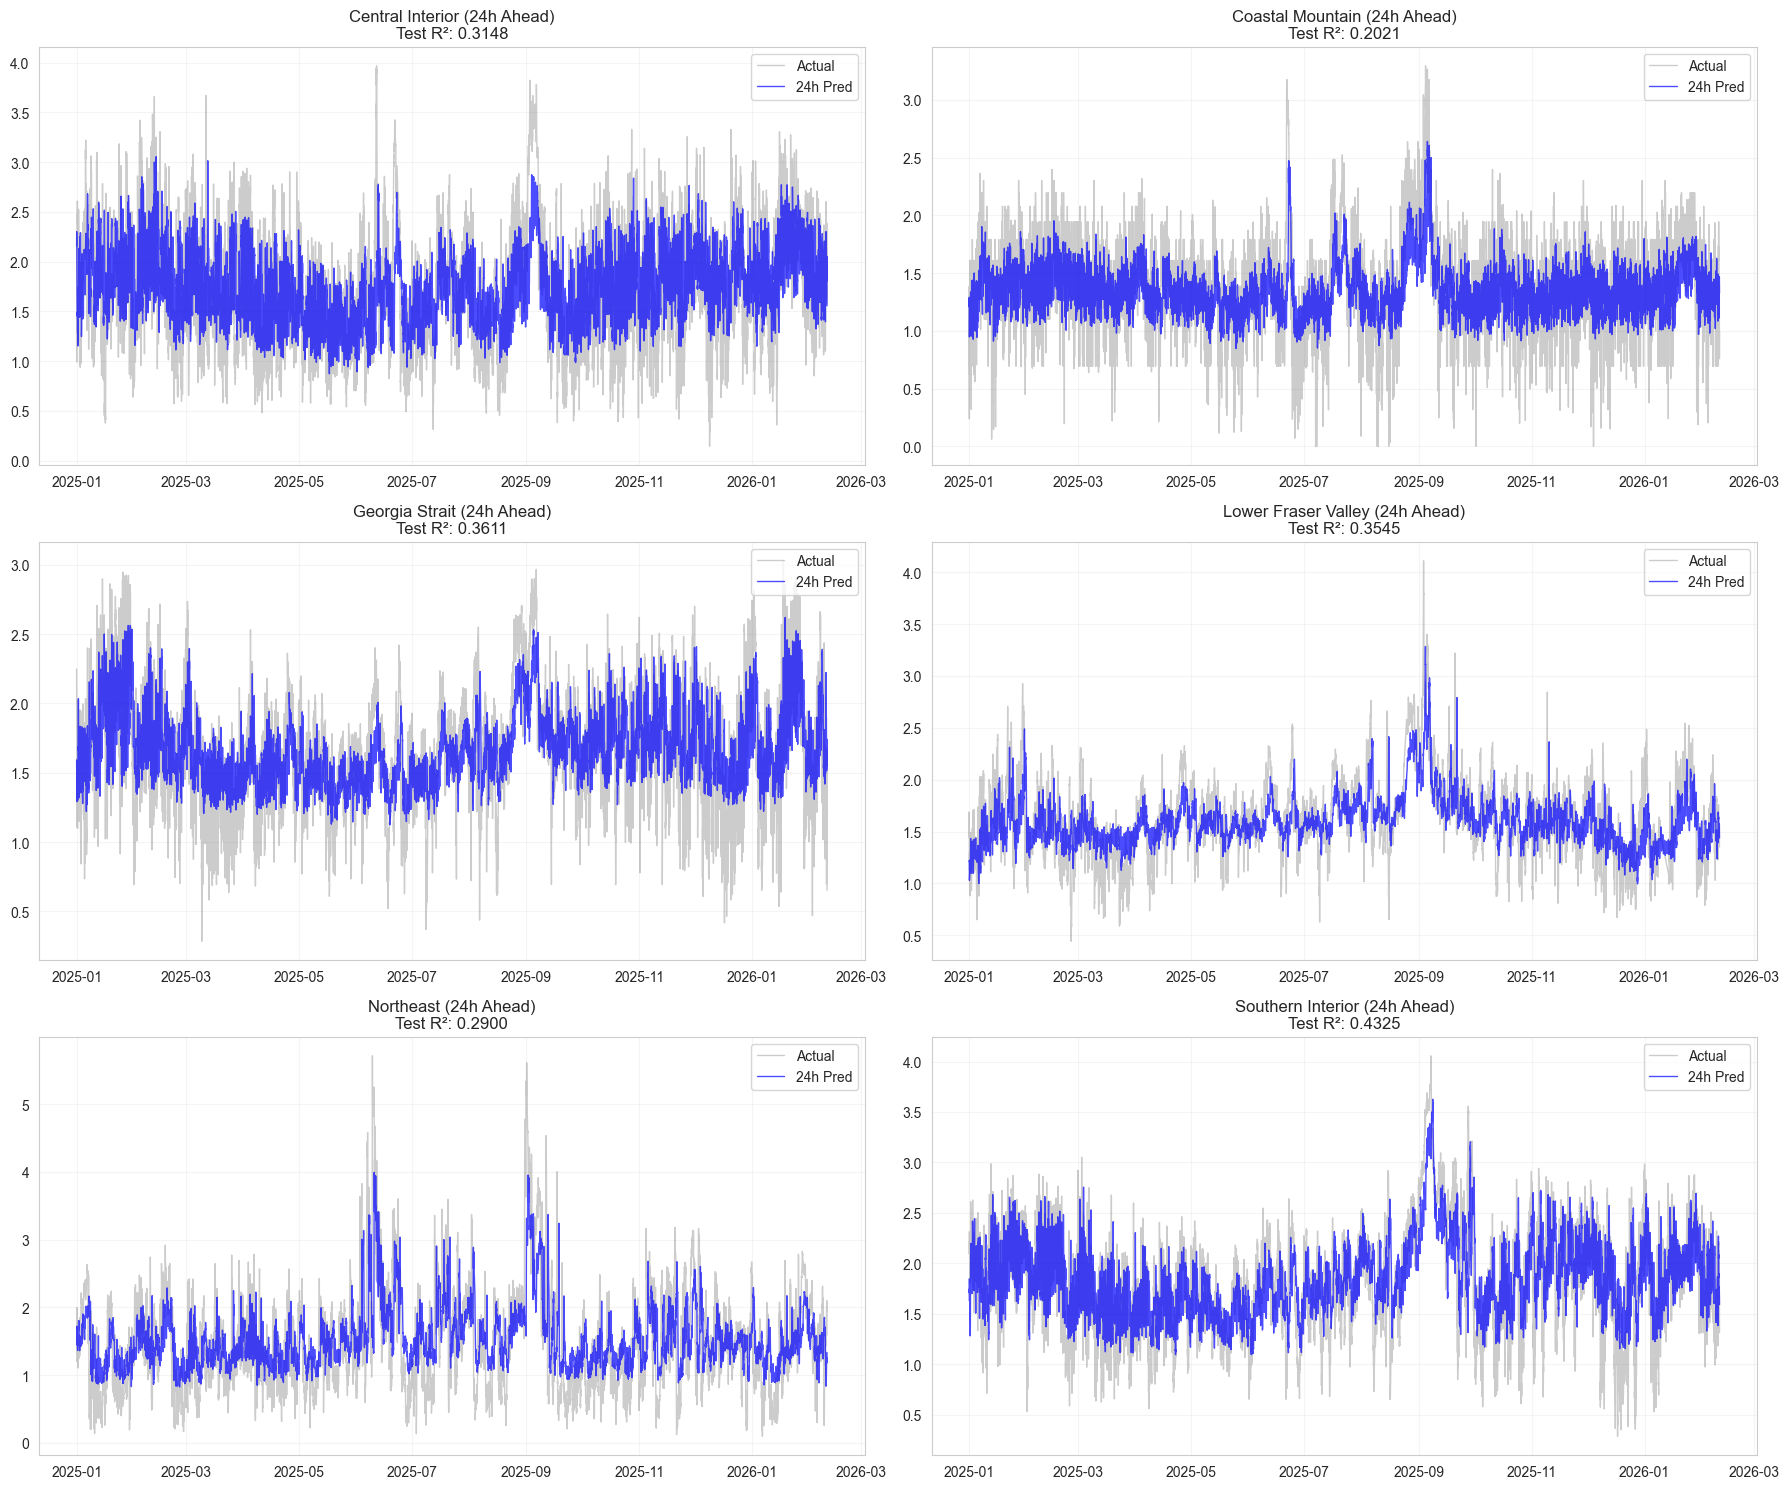


=== 全地区 24小时提前预测 性能排行榜 ===
                Region  24h_Test_R2  24h_Test_MSE
5    Southern Interior     0.432470      0.162659
2       Georgia Strait     0.361066      0.113262
3  Lower Fraser Valley     0.354471      0.097336
0     Central Interior     0.314768      0.256452
4            Northeast     0.290028      0.421047
1     Coastal Mountain     0.202103      0.143224


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from pygam import LinearGAM, s
from sklearn.metrics import r2_score, mean_squared_error

# --- 假设 df_imputed 已经在内存中 ---

# 1. 获取所有区域
target_columns = df_imputed.columns.tolist()
n_targets = len(target_columns)

# 2. 设置画布布局 (每行2张图)
n_cols = 2
n_rows = math.ceil(n_targets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# 存储各区域 24h 预测性能
metrics_24h = []

print(f"开始训练 {n_targets} 个区域的 24h 提前预测模型...")

for i, region in enumerate(target_columns):
    # --- A. 特征工程 (针对 24 小时滞后) ---
    data = df_imputed[[region]].copy()
    data.rename(columns={region: 'y'}, inplace=True)
    
    # 【核心】：使用 24 小时前的数据作为特征
    data['lag_24'] = data['y'].shift(24)
    data['hour'] = data.index.hour
    data['weekday'] = data.index.dayofweek
    data['dayofyear'] = data.index.dayofyear
    
    data.dropna(inplace=True)
    
    # --- B. 数据划分 ---
    # 训练集：2019-2024 全量
    train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
    # 预测集：2025年以后
    test_mask = data.index >= '2025-01-01'
    
    X_train = data.loc[train_mask, ['lag_24', 'hour', 'weekday', 'dayofyear']]
    y_train = data.loc[train_mask, 'y']
    
    X_test = data.loc[test_mask, ['lag_24', 'hour', 'weekday', 'dayofyear']]
    y_test = data.loc[test_mask, 'y']
    
    # --- C. 训练 GAM ---
    # 保持同样的自由度设置，观察 24h 跨度下的表现
    gam = LinearGAM(
        s(0) +                     # lag_24
        s(1, n_splines=20) +       # 依然使用 20 捕捉复杂的日内波动
        s(2, n_splines=7) +        # 周内
        s(3, n_splines=12)         # 季节
    ).fit(X_train, y_train)
    
    # --- D. 预测与评估 ---
    preds = gam.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    
    metrics_24h.append({
        'Region': region,
        '24h_Test_R2': r2,
        '24h_Test_MSE': mse
    })
    
    # --- E. 绘图 ---
    ax = axes[i]
    ax.plot(y_test.index, y_test, label='Actual', color='gray', alpha=0.4, linewidth=1)
    ax.plot(y_test.index, preds, label='24h Pred', color='blue', alpha=0.7, linewidth=1)
    
    ax.set_title(f'{region} (24h Ahead)\nTest R²: {r2:.4f}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

# 清理多余子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- F. 性能对比汇总 ---
df_performance = pd.DataFrame(metrics_24h).sort_values(by='24h_Test_R2', ascending=False)
print("\n=== 全地区 24小时提前预测 性能排行榜 ===")
print(df_performance)

开始训练 6 个区域的 24h 提前预测模型...


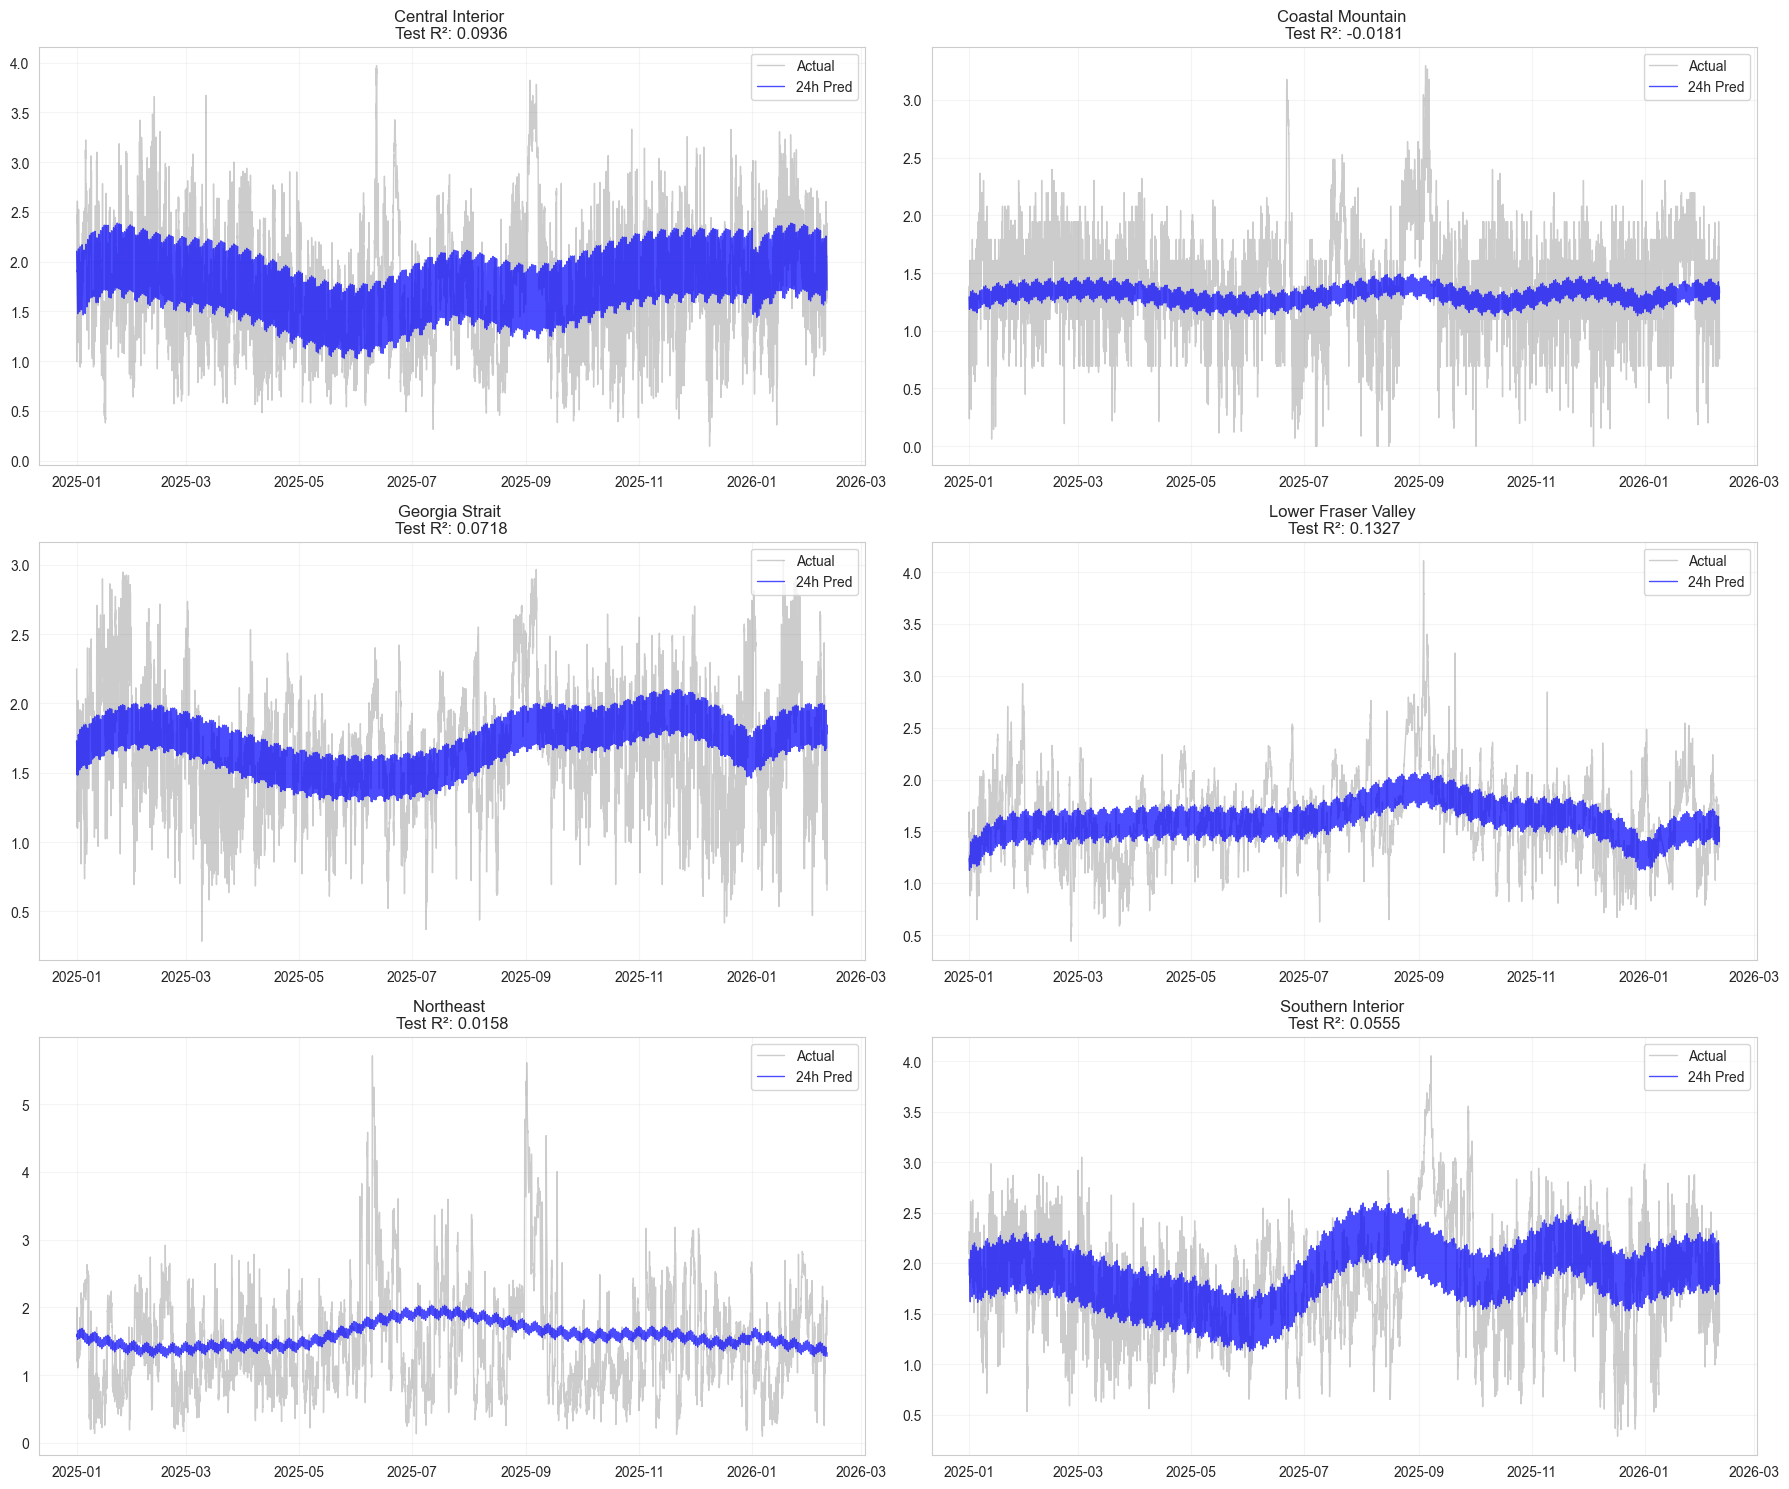


=== 全地区 24小时提前预测 性能排行榜 ===
                Region  24h_Test_R2  24h_Test_MSE
3  Lower Fraser Valley     0.132652      0.130783
0     Central Interior     0.093581      0.339232
2       Georgia Strait     0.071797      0.164541
5    Southern Interior     0.055522      0.270695
4            Northeast     0.015822      0.583665
1     Coastal Mountain    -0.018106      0.182752


In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from pygam import LinearGAM, s
from sklearn.metrics import r2_score, mean_squared_error

# --- 假设 df_imputed 已经在内存中 ---

# 1. 获取所有区域
target_columns = df_imputed.columns.tolist()
n_targets = len(target_columns)

# 2. 设置画布布局 (每行2张图)
n_cols = 2
n_rows = math.ceil(n_targets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# 存储各区域 24h 预测性能
metrics_24h = []

print(f"开始训练 {n_targets} 个区域的 24h 提前预测模型...")

for i, region in enumerate(target_columns):
    # --- A. 特征工程 (针对 24 小时滞后) ---
    data = df_imputed[[region]].copy()
    data.rename(columns={region: 'y'}, inplace=True)
    
    # 【核心】：使用 24 小时前的数据作为特征
    #data['lag_24'] = data['y'].shift(24)
    data['hour'] = data.index.hour
    data['weekday'] = data.index.dayofweek
    data['dayofyear'] = data.index.dayofyear
    
    data.dropna(inplace=True)
    
    # --- B. 数据划分 ---
    # 训练集：2019-2024 全量
    train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
    # 预测集：2025年以后
    test_mask = data.index >= '2025-01-01'
    
    X_train = data.loc[train_mask, ['hour', 'weekday', 'dayofyear']]
    y_train = data.loc[train_mask, 'y']
    
    X_test = data.loc[test_mask, ['hour', 'weekday', 'dayofyear']]
    y_test = data.loc[test_mask, 'y']
    
    # --- C. 训练 GAM ---
    # 保持同样的自由度设置，观察 24h 跨度下的表现
    gam = LinearGAM(
        s(0, n_splines=20) +       # 依然使用 20 捕捉复杂的日内波动
        s(1, n_splines=7) +        # 周内
        s(2, n_splines=12)         # 季节
    ).fit(X_train, y_train)
    
    # --- D. 预测与评估 ---
    preds = gam.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    
    metrics_24h.append({
        'Region': region,
        '24h_Test_R2': r2,
        '24h_Test_MSE': mse
    })
    
    # --- E. 绘图 ---
    ax = axes[i]
    ax.plot(y_test.index, y_test, label='Actual', color='gray', alpha=0.4, linewidth=1)
    ax.plot(y_test.index, preds, label='24h Pred', color='blue', alpha=0.7, linewidth=1)
    
    ax.set_title(f'{region} \nTest R²: {r2:.4f}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

# 清理多余子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- F. 性能对比汇总 ---
df_performance = pd.DataFrame(metrics_24h).sort_values(by='24h_Test_R2', ascending=False)
print("\n=== 全地区 24小时提前预测 性能排行榜 ===")
print(df_performance)


Step 1: Training Time-Only Model...
Step 2: Training Residual Model (Lag Correction)...


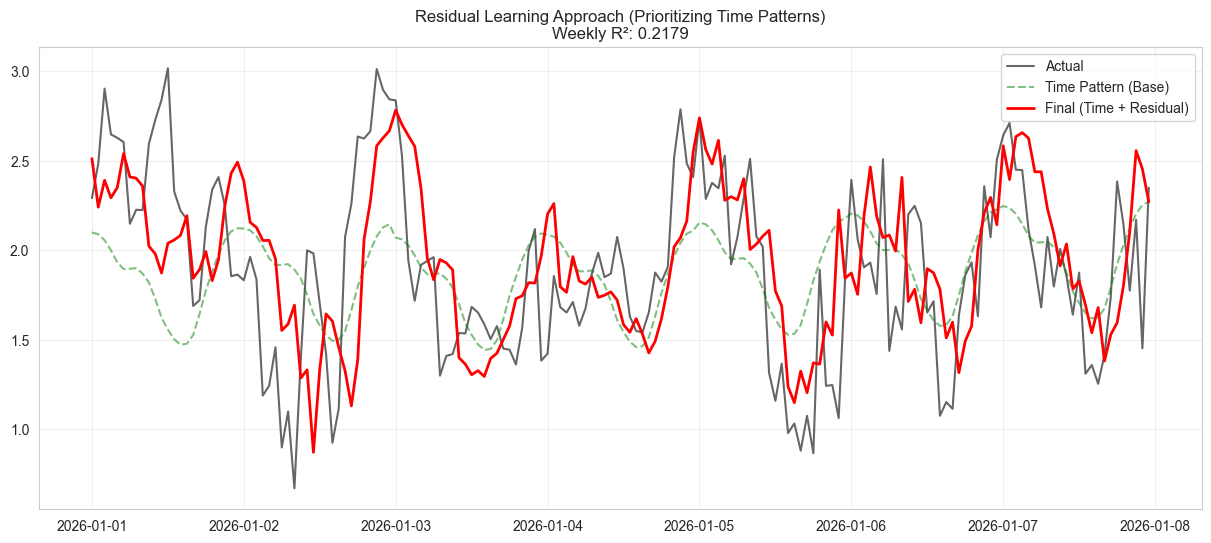

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
from sklearn.metrics import r2_score

# --- 假设 df_imputed 已经在内存中 ---
target_col = 'Central Interior' # 你可以选择一个最严重的区域测试

# 1. 数据准备
data = df_imputed[[target_col]].copy()
data.rename(columns={target_col: 'y'}, inplace=True)

# 特征构造
data['lag_3'] = data['y'].shift(3)
data['hour'] = data.index.hour
data['weekday'] = data.index.dayofweek
data['dayofyear'] = data.index.dayofyear
data.dropna(inplace=True)

# 划分训练集 (2019-2024) 和 测试集 (2025+)
train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
test_mask = data.index >= '2025-01-01'

X_train = data.loc[train_mask]
y_train = data.loc[train_mask, 'y']
X_test = data.loc[test_mask]
y_test = data.loc[test_mask, 'y']

# ==========================================
# 第一步：训练 Base Model (纯时间规律)
# ==========================================
print("Step 1: Training Time-Only Model...")
# 只用 hour, weekday, dayofyear
gam_time = LinearGAM(
    s(0, n_splines=20) +  # hour
    s(1, n_splines=7) +   # weekday
    s(2, n_splines=12)    # dayofyear
).fit(X_train[['hour', 'weekday', 'dayofyear']], y_train)

# 得到时间规律的预测值
train_time_pred = gam_time.predict(X_train[['hour', 'weekday', 'dayofyear']])
test_time_pred = gam_time.predict(X_test[['hour', 'weekday', 'dayofyear']])

# ==========================================
# 第二步：计算残差 (Residuals)
# ==========================================
# 残差 = 真实值 - 时间规律预测值
train_residuals = y_train - train_time_pred

# ==========================================
# 第三步：训练 Residual Model (用 lag_3 修正残差)
# ==========================================
print("Step 2: Training Residual Model (Lag Correction)...")
# 用 lag_3 预测 残差
gam_resid = LinearGAM(
    s(0) # lag_3
).fit(X_train[['lag_3']], train_residuals)

# 预测残差
test_resid_pred = gam_resid.predict(X_test[['lag_3']])

# ==========================================
# 第四步：最终合并
# ==========================================
# 最终预测 = 时间规律 + 修正后的残差
final_pred = test_time_pred + test_resid_pred

# ==========================================
# 绘图验证 (2026年1月1日-7日)
# ==========================================
plot_data = pd.DataFrame({
    'Actual': y_test,
    'Time_Only': test_time_pred,
    'Final_Pred': final_pred
}, index=y_test.index)

subset = plot_data.loc['2026-01-01':'2026-01-07 23:59:59']
r2_final = r2_score(subset['Actual'], subset['Final_Pred'])

plt.figure(figsize=(15, 6))

# 1. 真实值
plt.plot(subset.index, subset['Actual'], color='black', label='Actual', alpha=0.6, linewidth=1.5)

# 2. 纯时间模型 (展示底层的日内规律)
plt.plot(subset.index, subset['Time_Only'], color='green', label='Time Pattern (Base)', linestyle='--', alpha=0.5)

# 3. 最终预测 (时间 + 残差修正)
plt.plot(subset.index, subset['Final_Pred'], color='red', label='Final (Time + Residual)', linewidth=2)

plt.title(f'Residual Learning Approach (Prioritizing Time Patterns)\nWeekly R²: {r2_final:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

正在尝试【预测差值法 (Delta Prediction)】(区间: 2026-01-01 至 2026-01-07)...


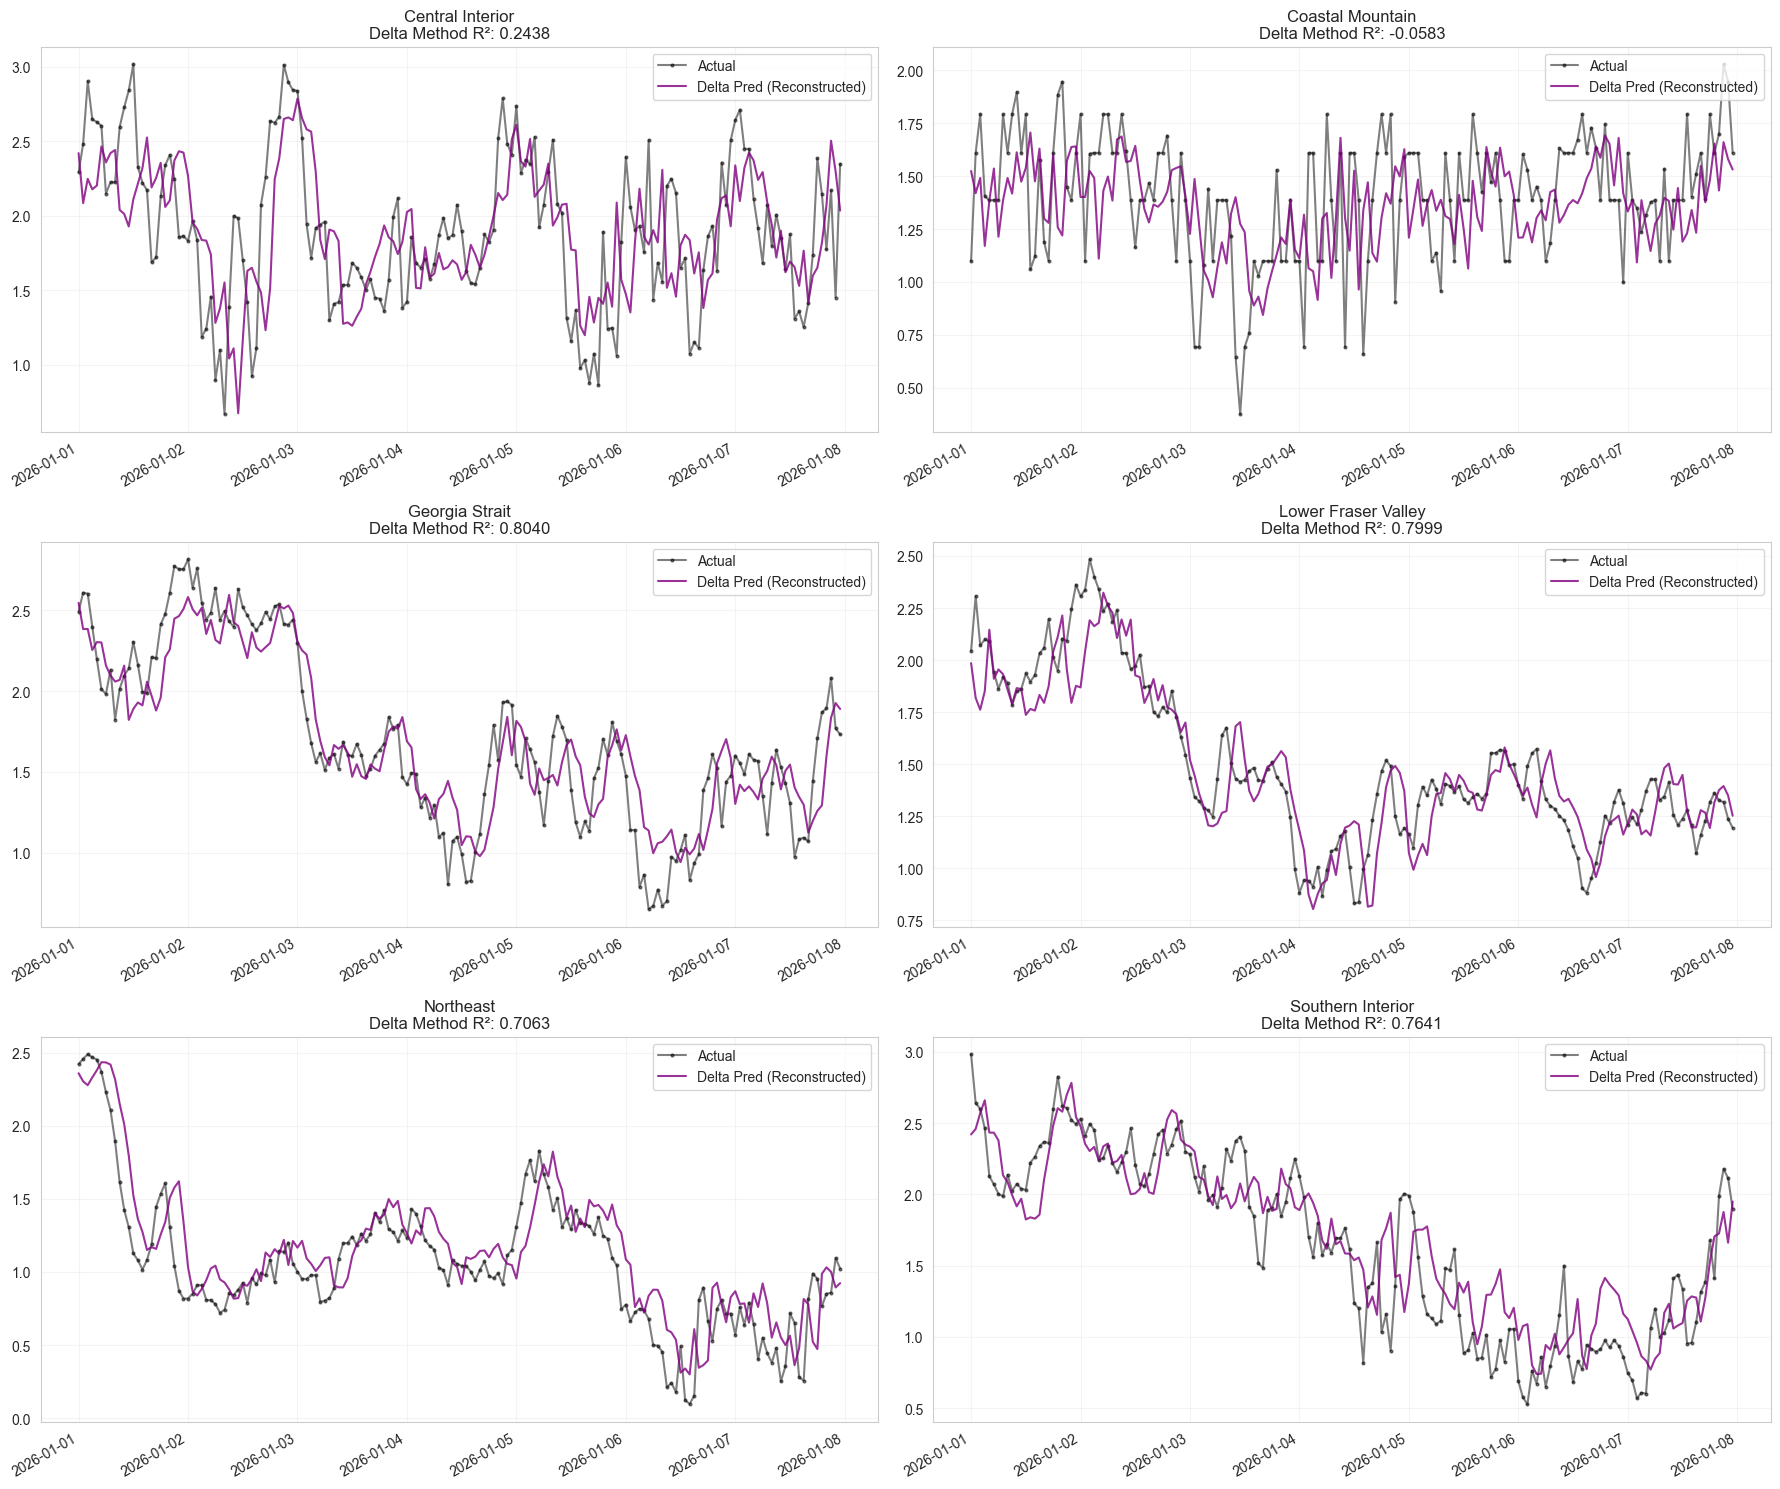

                Region  Weekly R2
2       Georgia Strait   0.803957
3  Lower Fraser Valley   0.799938
5    Southern Interior   0.764109
4            Northeast   0.706316
0     Central Interior   0.243776
1     Coastal Mountain  -0.058344


In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from pygam import LinearGAM, s, l
from sklearn.metrics import r2_score

# --- 假设 df_imputed 已经在内存中 ---

target_columns = df_imputed.columns.tolist()
n_targets = len(target_columns)

# 绘图区间：2026年1月1日-7日
plot_start = '2026-01-01'
plot_end = '2026-01-07 23:59:59'

# 设置画布
n_cols = 2
n_rows = math.ceil(n_targets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

metrics_delta = []

print(f"正在尝试【预测差值法 (Delta Prediction)】(区间: 2026-01-01 至 2026-01-07)...")

for i, region in enumerate(target_columns):
    # --- A. 数据准备 ---
    data = df_imputed[[region]].copy()
    data.rename(columns={region: 'y'}, inplace=True)
    
    # 1. 基础特征
    data['lag_3'] = data['y'].shift(3)
    
    # 2. 【核心目标】构建差值 Target (当前值 - 3小时前的值)
    data['diff_target'] = data['y'] - data['lag_3']
    
    # 3. 辅助特征：之前的趋势 (Momentum)
    # 含义：3小时前的那一刻，是在上升还是下降？(t-3) - (t-6)
    data['prev_diff'] = data['y'].shift(3) - data['y'].shift(6)
    
    # 时间特征
    data['hour'] = data.index.hour
    data['weekday'] = data.index.dayofweek
    data['dayofyear'] = data.index.dayofyear
    
    data.dropna(inplace=True)
    
    # --- B. 数据划分 ---
    train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
    test_mask = data.index >= '2025-01-01'
    
    # 注意：X 中包含 lag_3，因为“当前的绝对水平”会影响“变化的幅度”（均值回归）
    feature_cols = ['lag_3', 'prev_diff', 'hour', 'weekday', 'dayofyear']
    
    X_train = data.loc[train_mask, feature_cols]
    y_train_diff = data.loc[train_mask, 'diff_target'] # 训练目标是差值
    
    X_test = data.loc[test_mask, feature_cols]
    y_test_actual = data.loc[test_mask, 'y']           # 测试验证用绝对值
    
    # --- C. 训练模型 (预测差值) ---
    # s(0): lag_3 (绝对值高的时候，变化量可能偏负)
    # s(1): prev_diff (之前的趋势强，接下来的趋势可能继续强)
    # s(2): hour (日内变化规律，例如早高峰通常是正增量)
    gam = LinearGAM(
        s(0) +                   # lag_3
        s(1) +                   # prev_diff (Momentum)
        s(2, n_splines=20) +     # hour
        s(3, n_splines=7) +      # weekday
        s(4, n_splines=12)       # season
    ).fit(X_train, y_train_diff)
    
    # --- D. 预测与还原 ---
    # 1. 预测差值
    pred_diff = gam.predict(X_test)
    
    # 2. 【关键】还原绝对值： 预测值 = 3小时前的值 + 预测的变化量
    # 注意：这里我们使用测试集中真实的 lag_3 (模拟实时预测场景)
    final_pred = X_test['lag_3'] + pred_diff
    
    # --- E. 评估与切片 ---
    results = pd.DataFrame({'Actual': y_test_actual, 'Predicted': final_pred}, index=y_test_actual.index)
    weekly_subset = results.loc[plot_start:plot_end]
    
    # 计算还原后的 R2
    weekly_r2 = r2_score(weekly_subset['Actual'], weekly_subset['Predicted'])
    metrics_delta.append({'Region': region, 'Weekly R2': weekly_r2})
    
    # --- F. 绘图 ---
    ax = axes[i]
    # 真实值
    ax.plot(weekly_subset.index, weekly_subset['Actual'], label='Actual', color='black', alpha=0.5, marker='.', markersize=4)
    # 预测值
    ax.plot(weekly_subset.index, weekly_subset['Predicted'], label='Delta Pred (Reconstructed)', color='purple', alpha=0.8, linewidth=1.5)
    
    ax.set_title(f'{region}\nDelta Method R²: {weekly_r2:.4f}', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 清理多余子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 输出汇总
print(pd.DataFrame(metrics_delta).sort_values(by='Weekly R2', ascending=False))

修正后的 SARIMA Rolling R²: 0.1538


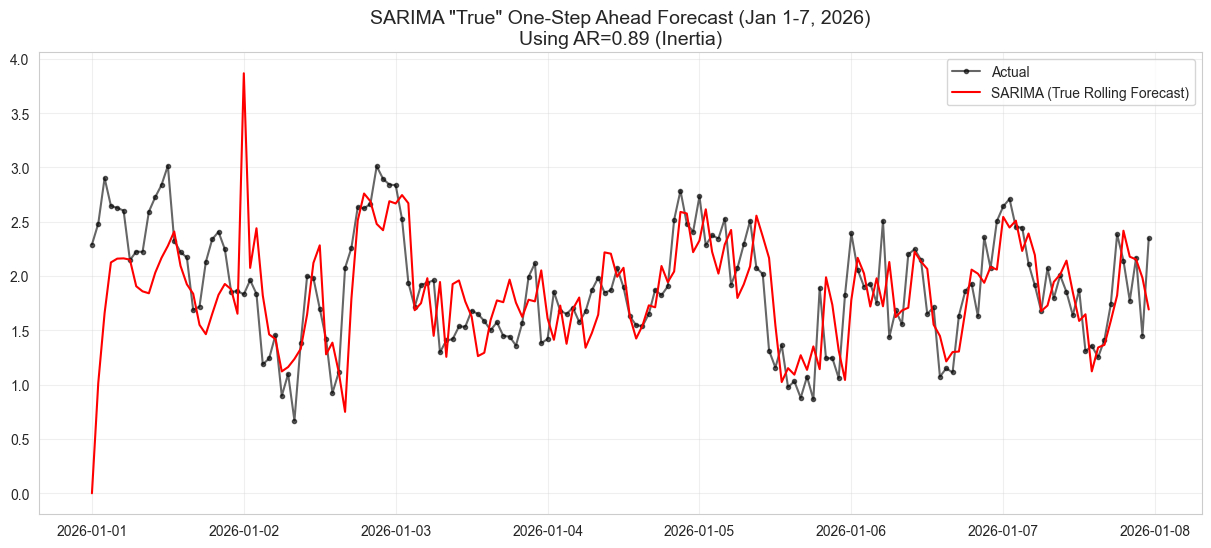

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

# --- 假设 df_imputed 已经在内存中 ---
target_region = 'Central Interior'

# 1. 准备数据
train_start = '2025-10-01'
train_end = '2025-12-31 23:00:00'
test_start = '2026-01-01'
test_end = '2026-01-07 23:00:00'

series = df_imputed[target_region]
train_data = series.loc[train_start:train_end]
test_data = series.loc[test_start:test_end]

# 2. 训练模型 (只用旧数据训练参数)
# 注意：这一步和之前一样，是为了获取 AR 和 MA 的系数
model_train = SARIMAX(train_data, 
                      order=(1, 0, 1), 
                      seasonal_order=(0, 1, 1, 24),
                      enforce_stationarity=False, 
                      enforce_invertibility=False)
results_train = model_train.fit(disp=False)

# 3. 【核心修正】将测试集数据“追加”到模型中
# apply() 方法会将新数据放入模型，但【不重新训练参数】(非常快)
# 这样模型就拥有了 2026年1月 的记忆，可以进行真正的 One-Step 预测
results_updated = results_train.apply(test_data)

# 4. 进行预测 (现在 dynamic=False 会生效了)
# 获取测试集时间段内的“拟合值” (In-sample prediction)
pred = results_updated.fittedvalues

# 5. 评估
r2 = r2_score(test_data, pred)
print(f"修正后的 SARIMA Rolling R²: {r2:.4f}")

# 6. 绘图
plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data, label='Actual', color='black', alpha=0.6, marker='.')
plt.plot(pred.index, pred, label='SARIMA (True Rolling Forecast)', color='red', linewidth=1.5)
plt.title(f'SARIMA "True" One-Step Ahead Forecast (Jan 1-7, 2026)\nUsing AR={results_train.params["ar.L1"]:.2f} (Inertia)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

发现 [Central Interior] 的最佳空间预警邻居是: Southern Interior (Corr: 0.39)
正在训练 XGBoost 模型 (捕捉非线性突变)...


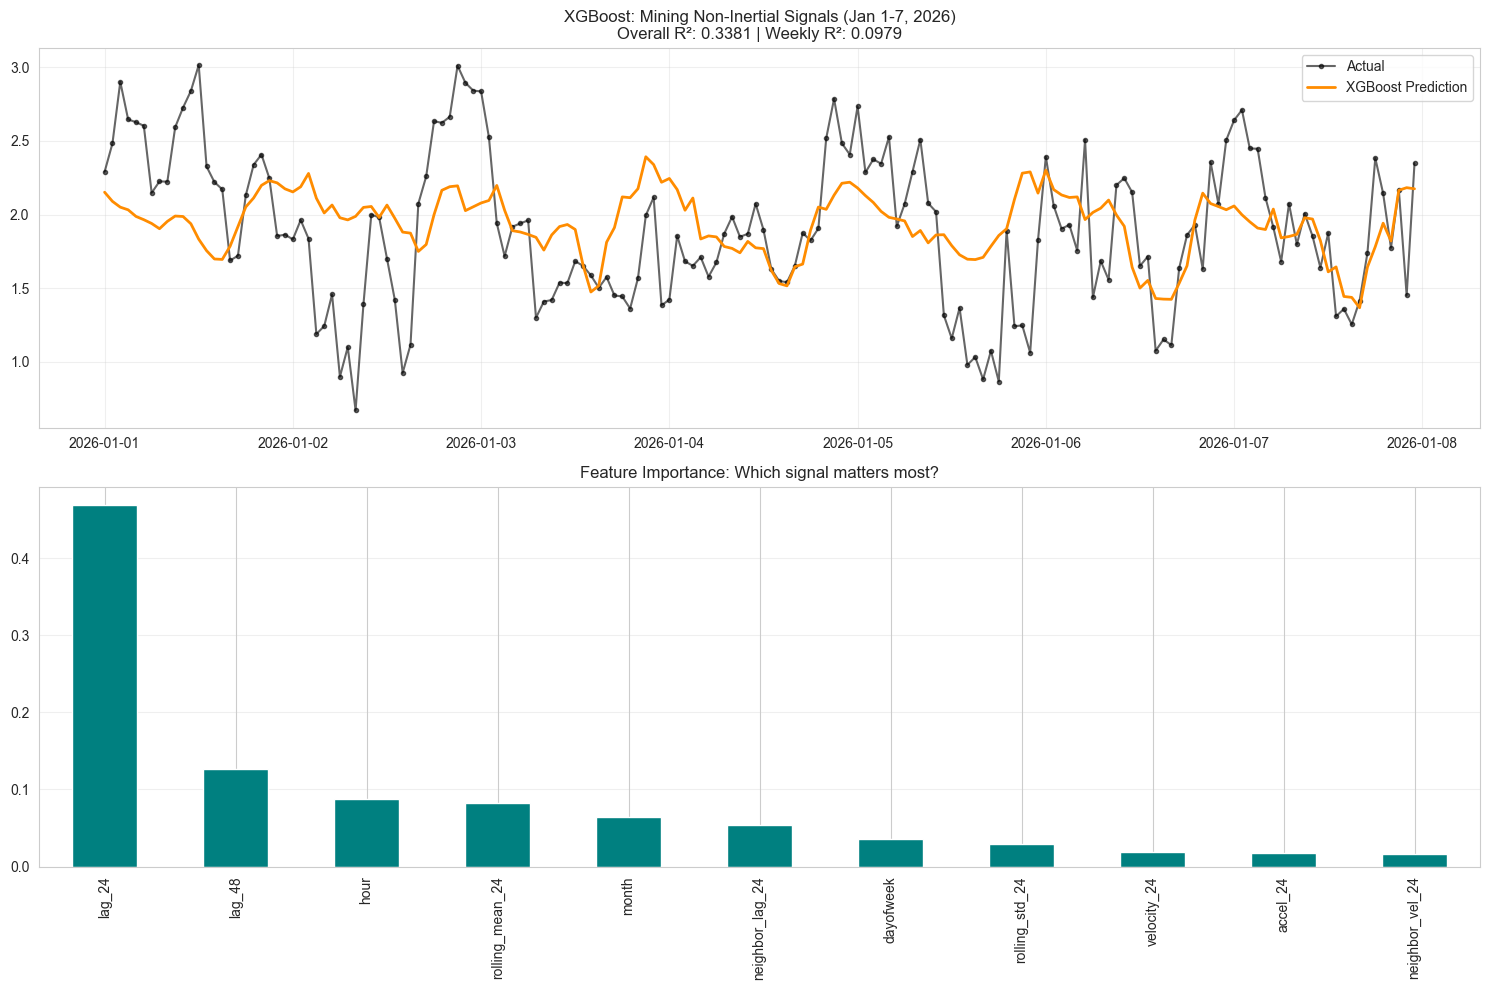

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# --- 假设 df_imputed 已经在内存中 ---
target_region = 'Central Interior' 
target_col = target_region

# 1. === 高级特征工程 (保持不变) ===
df_feat = df_imputed.copy()

# (1) 基础惯性
df_feat['lag_24'] = df_feat[target_col].shift(24)
df_feat['lag_48'] = df_feat[target_col].shift(48)

# (2) 动力学特征
df_feat['velocity_24'] = df_feat[target_col].shift(24) - df_feat[target_col].shift(25)
df_feat['accel_24'] = (df_feat[target_col].shift(24) - df_feat[target_col].shift(25)) - \
                      (df_feat[target_col].shift(25) - df_feat[target_col].shift(26))

# (3) 空间特征
corrs = df_imputed.corr()[target_col].drop(target_col)
best_neighbor = corrs.idxmax()
print(f"发现 [{target_region}] 的最佳空间预警邻居是: {best_neighbor} (Corr: {corrs.max():.2f})")

df_feat['neighbor_lag_24'] = df_feat[best_neighbor].shift(24)
df_feat['neighbor_vel_24'] = df_feat[best_neighbor].shift(24) - df_feat[best_neighbor].shift(25)

# (4) 统计特征
df_feat['rolling_mean_24'] = df_feat[target_col].shift(24).rolling(window=24).mean()
df_feat['rolling_std_24'] = df_feat[target_col].shift(24).rolling(window=24).std()

# (5) 时间特征
df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month

df_feat['y_target'] = df_feat[target_col]

# 2. === 数据清洗与划分 ===
df_feat.dropna(inplace=True)

train_mask = (df_feat.index >= '2019-01-01') & (df_feat.index <= '2024-12-31 23:59:59')
test_mask = df_feat.index >= '2025-01-01'

features = ['lag_24', 'lag_48', 'velocity_24', 'accel_24', 
            'neighbor_lag_24', 'neighbor_vel_24', 
            'rolling_mean_24', 'rolling_std_24',
            'hour', 'dayofweek', 'month']

X_train = df_feat.loc[train_mask, features]
y_train = df_feat.loc[train_mask, 'y_target']
X_test = df_feat.loc[test_mask, features]
y_test = df_feat.loc[test_mask, 'y_target']

# 3. === XGBoost 建模 (修正版) ===
print("正在训练 XGBoost 模型 (捕捉非线性突变)...")

# 【核心修正】：early_stopping_rounds 移到这里了
xgb = XGBRegressor(
    n_estimators=500,     
    learning_rate=0.05,   
    max_depth=6,          
    subsample=0.8,        
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50  # <--- 注意：移到了构造函数里
)

# fit() 中只保留 eval_set 和 verbose
xgb.fit(X_train, y_train, 
        eval_set=[(X_test, y_test)], 
        verbose=False)

# 4. === 预测与评估 ===
preds = xgb.predict(X_test)

results = pd.DataFrame({'Actual': y_test, 'Predicted': preds}, index=y_test.index)
subset = results.loc['2026-01-01':'2026-01-07 23:59:59']

r2_full = r2_score(y_test, preds)
r2_subset = r2_score(subset['Actual'], subset['Predicted'])

# 5. === 绘图 ===
plt.figure(figsize=(15, 10))

# 子图1: 预测曲线对比
plt.subplot(2, 1, 1)
plt.plot(subset.index, subset['Actual'], label='Actual', color='black', alpha=0.6, marker='.')
plt.plot(subset.index, subset['Predicted'], label='XGBoost Prediction', color='darkorange', linewidth=2)
plt.title(f'XGBoost: Mining Non-Inertial Signals (Jan 1-7, 2026)\nOverall R²: {r2_full:.4f} | Weekly R²: {r2_subset:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 特征重要性
plt.subplot(2, 1, 2)
importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind='bar', color='teal')
plt.title('Feature Importance: Which signal matters most?')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

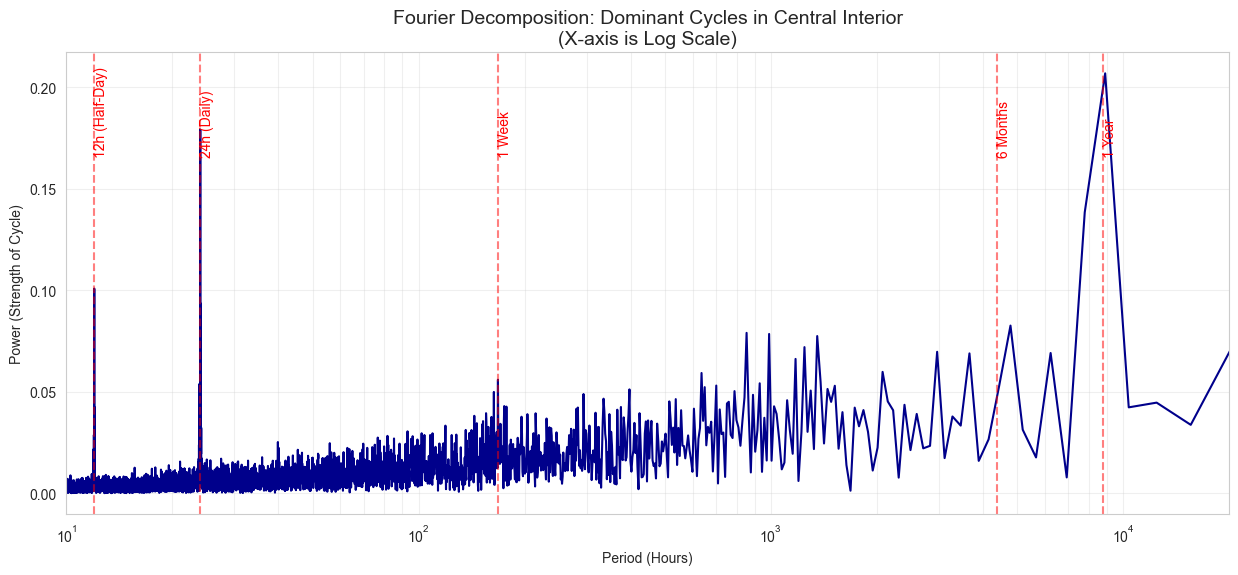

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# --- 假设 df_imputed 已经在内存中 ---
# 选择一个代表性区域，例如 'Central Interior'
target_region = 'Central Interior'
data_series = df_imputed[target_region].dropna()

# 1. 准备 FFT 数据
N = len(data_series)
T = 1.0  # 采样间隔：1小时

# 执行快速傅立叶变换
yf = fft(data_series.values)
xf = fftfreq(N, T)[:N//2] # 取正频率部分

# 计算功率谱 (Power Spectrum)
power = 2.0/N * np.abs(yf[0:N//2])

# 2. 转换频率为“周期 (小时)”以便人类阅读
# Period = 1 / Frequency
# 为了绘图，我们忽略直流分量 (index 0)
periods = 1 / xf[1:]
power_plot = power[1:]

# 3. 绘图：频谱分析
plt.figure(figsize=(15, 6))
plt.semilogx(periods, power_plot, color='darkblue', linewidth=1.5)

# 标注关键周期
target_periods = [12, 24, 168, 8760/2, 8760] # 12h, 24h, 1周, 半年, 1年
labels = ['12h (Half-Day)', '24h (Daily)', '1 Week', '6 Months', '1 Year']

for p, l in zip(target_periods, labels):
    # 找到最接近该周期的索引
    idx = np.abs(periods - p).argmin()
    plt.axvline(x=p, color='red', linestyle='--', alpha=0.5)
    plt.text(p, max(power_plot)*0.8, l, rotation=90, verticalalignment='bottom', color='red')

plt.title(f'Fourier Decomposition: Dominant Cycles in {target_region}\n(X-axis is Log Scale)', fontsize=14)
plt.xlabel('Period (Hours)')
plt.ylabel('Power (Strength of Cycle)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.xlim(10, 20000) # 限制显示范围：从10小时到2年以上
plt.show()

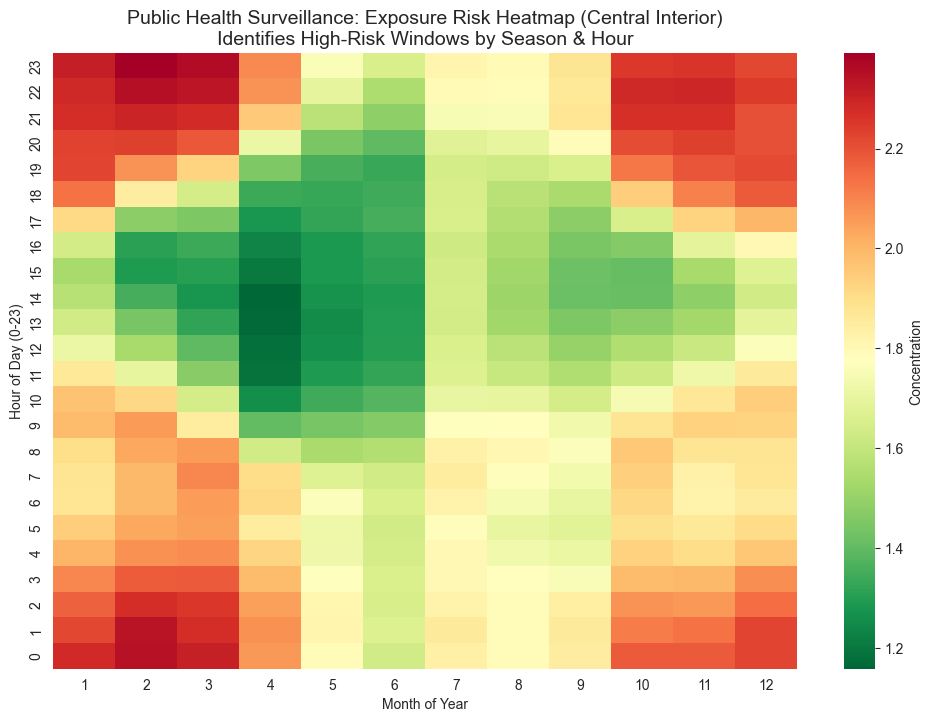

In [106]:
import seaborn as sns

# 1. 构造时间特征
df_viz = df_imputed[[target_region]].copy()
df_viz.columns = ['Pollutant']
df_viz['Hour'] = df_viz.index.hour
df_viz['Month'] = df_viz.index.month

# 2. 构建透视表：横轴月份，纵轴小时
# 聚合方式用 'mean' 看平均水平，也可以用 'max' 看极端风险
pivot_table = df_viz.pivot_table(values='Pollutant', index='Hour', columns='Month', aggfunc='mean')

# 3. 绘制热力图
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='RdYlGn_r', annot=False, fmt=".1f", cbar_kws={'label': 'Concentration'})

# 装饰图表
plt.title(f'Public Health Surveillance: Exposure Risk Heatmap ({target_region})\nIdentifies High-Risk Windows by Season & Hour', fontsize=14)
plt.xlabel('Month of Year')
plt.ylabel('Hour of Day (0-23)')
plt.gca().invert_yaxis() # 让0点在下面，23点在上面，符合直觉
plt.show()

正在训练 Tensor Product GAM (Lag + Hour x Season Interaction)...


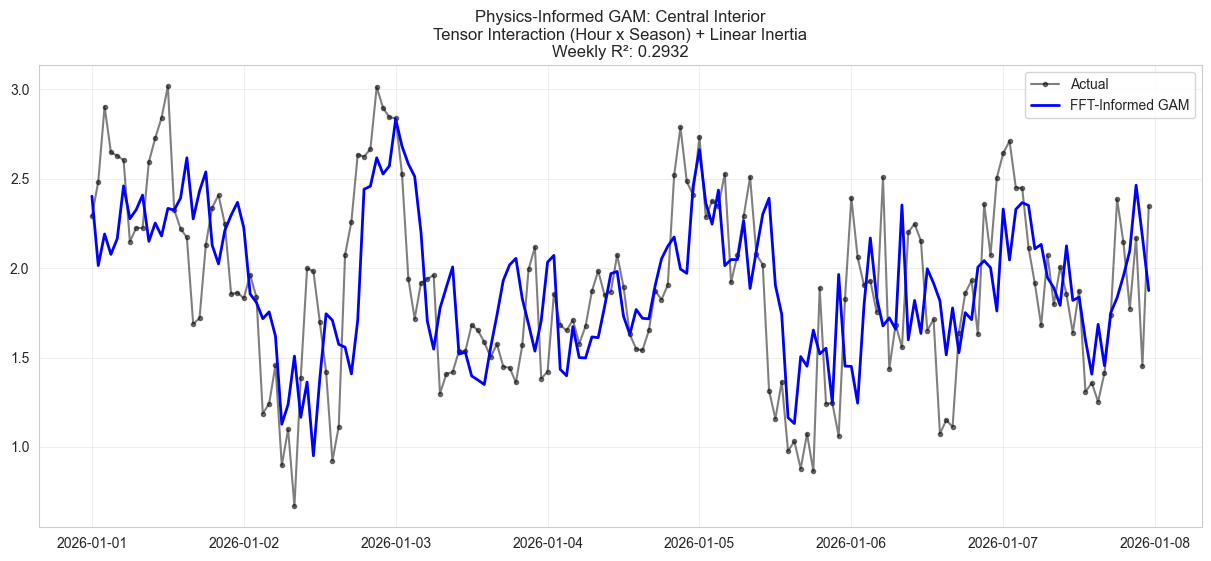

<Figure size 1200x800 with 0 Axes>

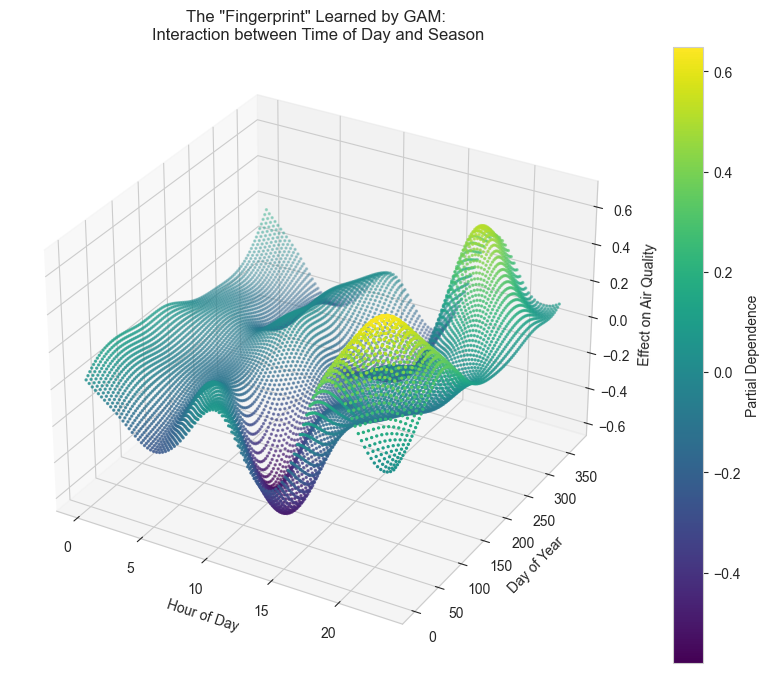

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     73.5382
Link Function:                     IdentityLink Log Likelihood:                                -21636.8511
Number of Samples:                        52604 AIC:                                            43422.7786
                                                AICc:                                            43422.993
                                                GCV:                                                0.1338
                                                Scale:                                              0.3653
                                                Pseudo R-Squared:                                    0.703
Feature Function                  Lam

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_23306/912489454.py:100: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pygam import LinearGAM, s, te, l
from sklearn.metrics import r2_score

# --- 假设 df_imputed 已经在内存中 ---
target_region = 'Central Interior'

# 1. === 特征工程 (配合 FFT 发现) ===
data = df_imputed[[target_region]].copy()
data.columns = ['y']

# (A) 惯性项 (应对 FFT 中的高频噪音)
data['lag_3'] = data['y'].shift(3)

# (B) 周期项 (对应 FFT 的两大尖峰)
# 为了让样条函数更好地拟合首尾，我们可以把特征复制一份做铺垫，
# 但在这里我们直接用高自由度的样条来拟合
data['hour'] = data.index.hour
data['dayofyear'] = data.index.dayofyear

data.dropna(inplace=True)

# 划分数据
train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
test_mask = data.index >= '2025-01-01'

X_train = data.loc[train_mask, ['lag_3', 'hour', 'dayofyear']]
y_train = data.loc[train_mask, 'y']
X_test = data.loc[test_mask, ['lag_3', 'hour', 'dayofyear']]
y_test = data.loc[test_mask, 'y']

# 2. === 定义“物理感知” GAM 模型 ===

# 公式设计思路：
# 1. l(0): 对 lag_3 使用线性项 (Linear Term)。
#    原因：惯性通常是线性的 (昨天高，今天也高)。用样条可能会过拟合。
#
# 2. te(1, 2): 对 hour 和 dayofyear 使用张量积 (Tensor Product)。
#    原因：这是核心！它允许“日内规律”随“季节”变化。
#    n_splines=[12, 10]: 
#       - hour (12): 对应 FFT 的 24h 和 12h 峰值，需要足够的自由度描绘双峰。
#       - dayofyear (10): 对应 FFT 的 1 Year 峰值，描绘季节缓变。

print("正在训练 Tensor Product GAM (Lag + Hour x Season Interaction)...")
gam = LinearGAM(
    l(0) +                   # Inertia (Lag_3)
    te(1, 2, n_splines=[12, 10]) # Interaction: Hour x Season
).fit(X_train, y_train)

# 3. === 预测与评估 ===
predictions = gam.predict(X_test)
r2 = r2_score(y_test, predictions)

# 4. === 可视化结果 ===
# 截取 2026年1月1日-7日
plot_data = pd.DataFrame({'Actual': y_test, 'Predicted': predictions}, index=y_test.index)
subset = plot_data.loc['2026-01-01':'2026-01-07 23:59:59']
subset_r2 = r2_score(subset['Actual'], subset['Predicted'])

plt.figure(figsize=(15, 6))
plt.plot(subset.index, subset['Actual'], label='Actual', color='black', alpha=0.5, marker='.')
plt.plot(subset.index, subset['Predicted'], label='FFT-Informed GAM', color='blue', linewidth=2)

plt.title(f'Physics-Informed GAM: {target_region}\nTensor Interaction (Hour x Season) + Linear Inertia\nWeekly R²: {subset_r2:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. === 可视化张量积 (查看季节和小时是如何互动的) ===
# 这张图非常酷，它能展示“模型眼中的空气质量指纹”
plt.figure(figsize=(12, 8))
XX = gam.generate_X_grid(term=1) # 生成网格
Z = gam.partial_dependence(term=1, X=XX) # 计算偏依赖

# 注意：pygam 的绘图比较原始，这里我们用 contourf 手动画
# 重新组织数据形状以便绘图
H = XX[:, 1] # hour
D = XX[:, 2] # dayofyear
Z_mesh = Z.reshape(100, 100) # pygam 默认生成 100x100 网格

# 创建透视表风格的矩阵
# 由于 generate_X_grid 生成的是展平的，为了简单展示，我们直接画 3D 表面
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 因为 pygam 网格化的问题，这里用散点图近似展示曲面
p = ax.scatter(H, D, Z, c=Z, cmap='viridis', s=2)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Year')
ax.set_zlabel('Effect on Air Quality')
plt.title('The "Fingerprint" Learned by GAM: \nInteraction between Time of Day and Season')
plt.colorbar(p, label='Partial Dependence')
plt.show()

print(gam.summary())

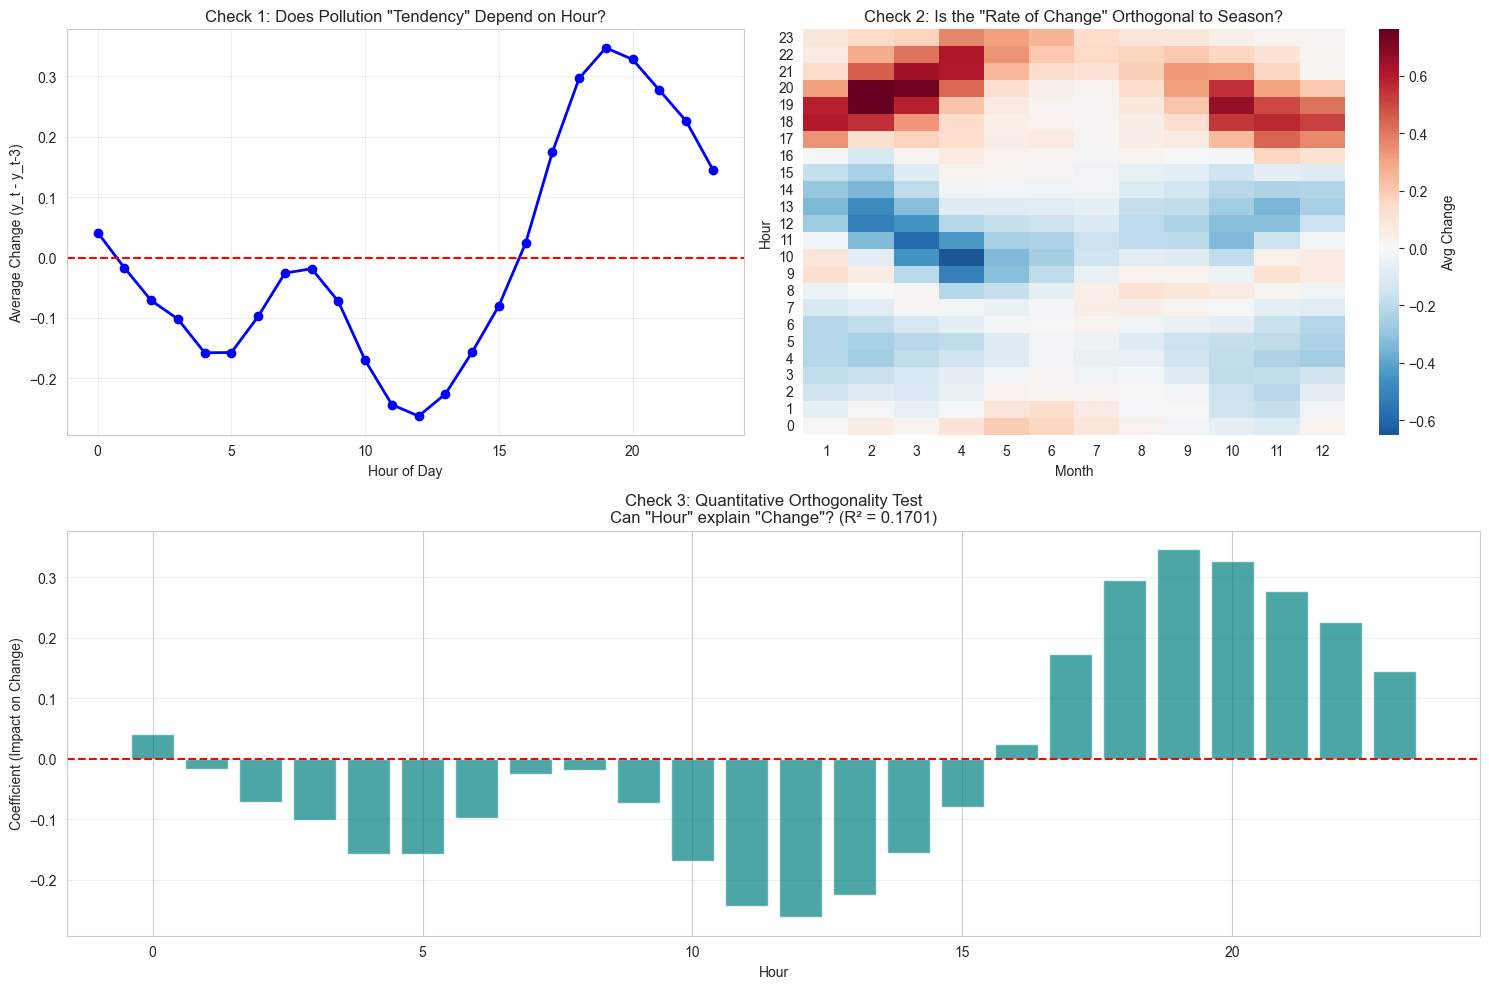

正交性量化指标 (R²): 0.1701
解读: 如果 R² 接近 0，则是正交的；如果 R² > 0.05，说明不正交（变化率本身有时间规律）。


In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# --- 假设 df_imputed 已经在内存中 ---
target_region = 'Central Interior'

# 1. 构造“3h 拆分数据” (3-Hour Difference)
data = df_imputed[[target_region]].copy()
data.columns = ['y']

# 定义拆分：当前值 - 3小时前的值 (即去除惯性基准)
# 这代表了：在这3小时内，空气质量“改变”了多少
data['diff_3h'] = data['y'] - data['y'].shift(3)

# 时间特征
data['hour'] = data.index.hour
data['month'] = data.index.month

data.dropna(inplace=True)

# 2. === 视觉检验：变化量 vs 时间 ===

plt.figure(figsize=(15, 10))

# (A) 小时均值图：看“变化方向”是否有规律
# 如果正交，这条线应该是一条躺在 0 上的直线
plt.subplot(2, 2, 1)
hourly_diff = data.groupby('hour')['diff_3h'].mean()
plt.plot(hourly_diff.index, hourly_diff.values, 'b-o', linewidth=2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Check 1: Does Pollution "Tendency" Depend on Hour?')
plt.xlabel('Hour of Day')
plt.ylabel('Average Change (y_t - y_t-3)')
plt.grid(True, alpha=0.3)

# (B) 热力图：季节 x 小时 的变化指纹
# 红色代表该时段倾向于变脏(积累)，蓝色代表倾向于变干净(消散)
plt.subplot(2, 2, 2)
pivot_diff = data.pivot_table(values='diff_3h', index='hour', columns='month', aggfunc='mean')
sns.heatmap(pivot_diff, cmap='RdBu_r', center=0, cbar_kws={'label': 'Avg Change'})
plt.title('Check 2: Is the "Rate of Change" Orthogonal to Season?')
plt.xlabel('Month')
plt.ylabel('Hour')
plt.gca().invert_yaxis()

# 3. === 定量检验：正交性测试 ===
# 我们做一个简单的线性回归：用 Time 来预测 Change
# 如果 R2 很低 (接近0)，说明 Time 无法解释 Change，即正交
# 如果 R2 较高，说明 Change 依然受 Time 控制

# 构造独热编码 (One-Hot) 以捕捉非线性时间关系
X_time = pd.get_dummies(data['hour'], prefix='h')
y_diff = data['diff_3h']

reg = LinearRegression().fit(X_time, y_diff)
r2_ortho = reg.score(X_time, y_diff)

plt.subplot(2, 1, 2)
# 展示每个小时的“解释力度” (回归系数)
coefs = reg.coef_
plt.bar(range(24), coefs, color='teal', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title(f'Check 3: Quantitative Orthogonality Test\nCan "Hour" explain "Change"? (R² = {r2_ortho:.4f})')
plt.xlabel('Hour')
plt.ylabel('Coefficient (Impact on Change)')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"正交性量化指标 (R²): {r2_ortho:.4f}")
print("解读: 如果 R² 接近 0，则是正交的；如果 R² > 0.05，说明不正交（变化率本身有时间规律）。")

正在训练消融模型: Only Inertia(Lag3) + Diurnal(Hour)...


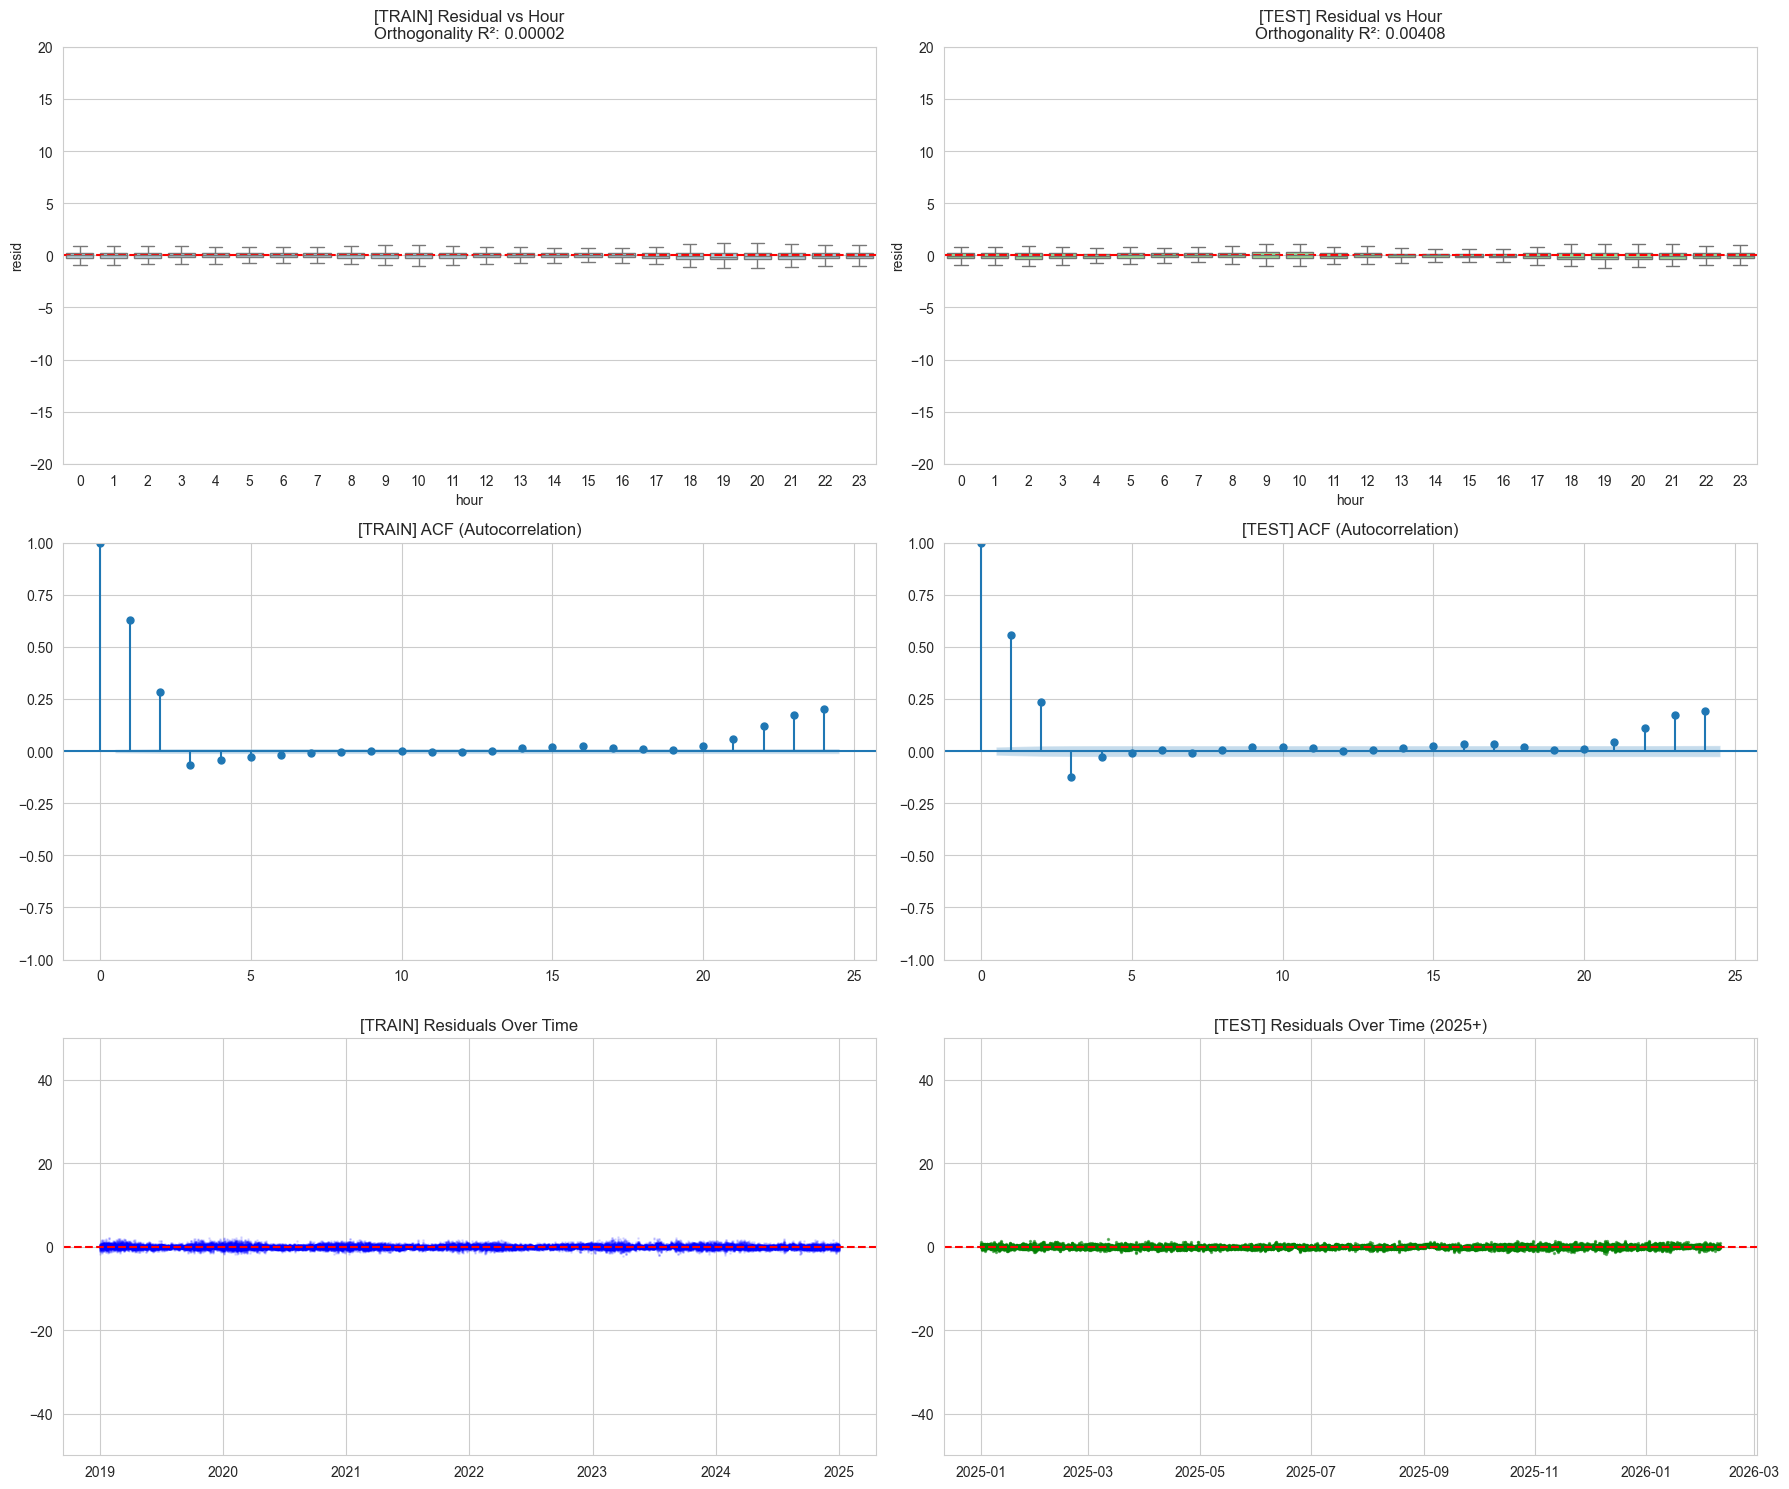

=== 消融实验结果 (Lag3 + Hour Only) ===
Train Orthogonality R²: 0.00002 (越低越好)
Test Orthogonality R² : 0.00408  (越低越好)
注意: 如果 Test R² 明显高于 Train R²，说明'日内规律'在未来发生了变化。


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, l, s
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- 假设 df_imputed 已经在内存中 ---
target_region = 'Central Interior'

# 1. === 数据准备 (极简模式) ===
data = df_imputed[[target_region]].copy()
data.columns = ['y']

# 特征工程 (仅 Lag3 和 Hour)
data['lag_3'] = data['y'].shift(3)
data['hour'] = data.index.hour

data.dropna(inplace=True)

# 划分 Train (2019-2024) vs Test (2025+)
train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
test_mask = data.index >= '2025-01-01'

X_train = data.loc[train_mask, ['lag_3', 'hour']]
y_train = data.loc[train_mask, 'y']

X_test = data.loc[test_mask, ['lag_3', 'hour']]
y_test = data.loc[test_mask, 'y']

# 2. === 训练 GAM (消融版) ===
print("正在训练消融模型: Only Inertia(Lag3) + Diurnal(Hour)...")

# l(0): Lag_3 (线性惯性)
# s(1): Hour (日内循环, n_splines=24 保证能捕捉早晚双峰)
# 注意：没有 te()，没有 season，完全独立
gam_ablation = LinearGAM(
    l(0) + 
    s(1, n_splines=24)
).fit(X_train, y_train)

# 3. === 计算残差 (Train vs Test) ===
# Train set
data.loc[train_mask, 'pred'] = gam_ablation.predict(X_train)
data.loc[train_mask, 'resid'] = y_train - data.loc[train_mask, 'pred']

# Test set
data.loc[test_mask, 'pred'] = gam_ablation.predict(X_test)
data.loc[test_mask, 'resid'] = y_test - data.loc[test_mask, 'pred']

# 提取残差子集
resid_train = data.loc[train_mask, 'resid']
resid_test = data.loc[test_mask, 'resid']
hour_train = data.loc[train_mask, 'hour']
hour_test = data.loc[test_mask, 'hour']

# 4. === 定量正交性测试函数 ===
def check_orthogonality(resid, hour_feature, name):
    # 用 Hour (One-hot) 预测 Residual
    X_dummy = pd.get_dummies(hour_feature, prefix='h')
    reg = LinearRegression().fit(X_dummy, resid)
    r2 = reg.score(X_dummy, resid)
    return r2, reg.coef_

r2_ortho_train, _ = check_orthogonality(resid_train, hour_train, "Train")
r2_ortho_test, _ = check_orthogonality(resid_test, hour_test, "Test")

# 5. === 可视化对比 (Train vs Test) ===
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# (Row 1) 正交性检验: Boxplot Residuals vs Hour
# 目的: 检查是否还有“早晚高峰”没被剥离干净
sns.boxplot(x=hour_train, y=resid_train, ax=axes[0, 0], showfliers=False, color='lightblue')
axes[0, 0].set_title(f'[TRAIN] Residual vs Hour\nOrthogonality R²: {r2_ortho_train:.5f}')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_ylim(-20, 20)

sns.boxplot(x=hour_test, y=resid_test, ax=axes[0, 1], showfliers=False, color='lightgreen')
axes[0, 1].set_title(f'[TEST] Residual vs Hour\nOrthogonality R²: {r2_ortho_test:.5f}')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_ylim(-20, 20)

# (Row 2) 自相关检验: ACF Plot
# 目的: 检查惯性 Lag-3 是否够用
plot_acf(resid_train, lags=24, ax=axes[1, 0], title='[TRAIN] ACF (Autocorrelation)')
plot_acf(resid_test, lags=24, ax=axes[1, 1], title='[TEST] ACF (Autocorrelation)')

# (Row 3) 残差随时间分布 (Drift Check)
# 目的: 检查切除“季节性”后的恶果——残差是否随季节漂移
axes[2, 0].scatter(resid_train.index, resid_train, s=1, alpha=0.1, color='blue')
axes[2, 0].set_title('[TRAIN] Residuals Over Time')
axes[2, 0].set_ylim(-50, 50)
axes[2, 0].axhline(0, color='red', linestyle='--')

axes[2, 1].scatter(resid_test.index, resid_test, s=2, alpha=0.5, color='green')
axes[2, 1].set_title('[TEST] Residuals Over Time (2025+)')
axes[2, 1].set_ylim(-50, 50)
axes[2, 1].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print(f"=== 消融实验结果 (Lag3 + Hour Only) ===")
print(f"Train Orthogonality R²: {r2_ortho_train:.5f} (越低越好)")
print(f"Test Orthogonality R² : {r2_ortho_test:.5f}  (越低越好)")
print(f"注意: 如果 Test R² 明显高于 Train R²，说明'日内规律'在未来发生了变化。")

正在训练: Inertia(Lag3) + Diurnal(Hour) + Seasonal(DayOfYear)...


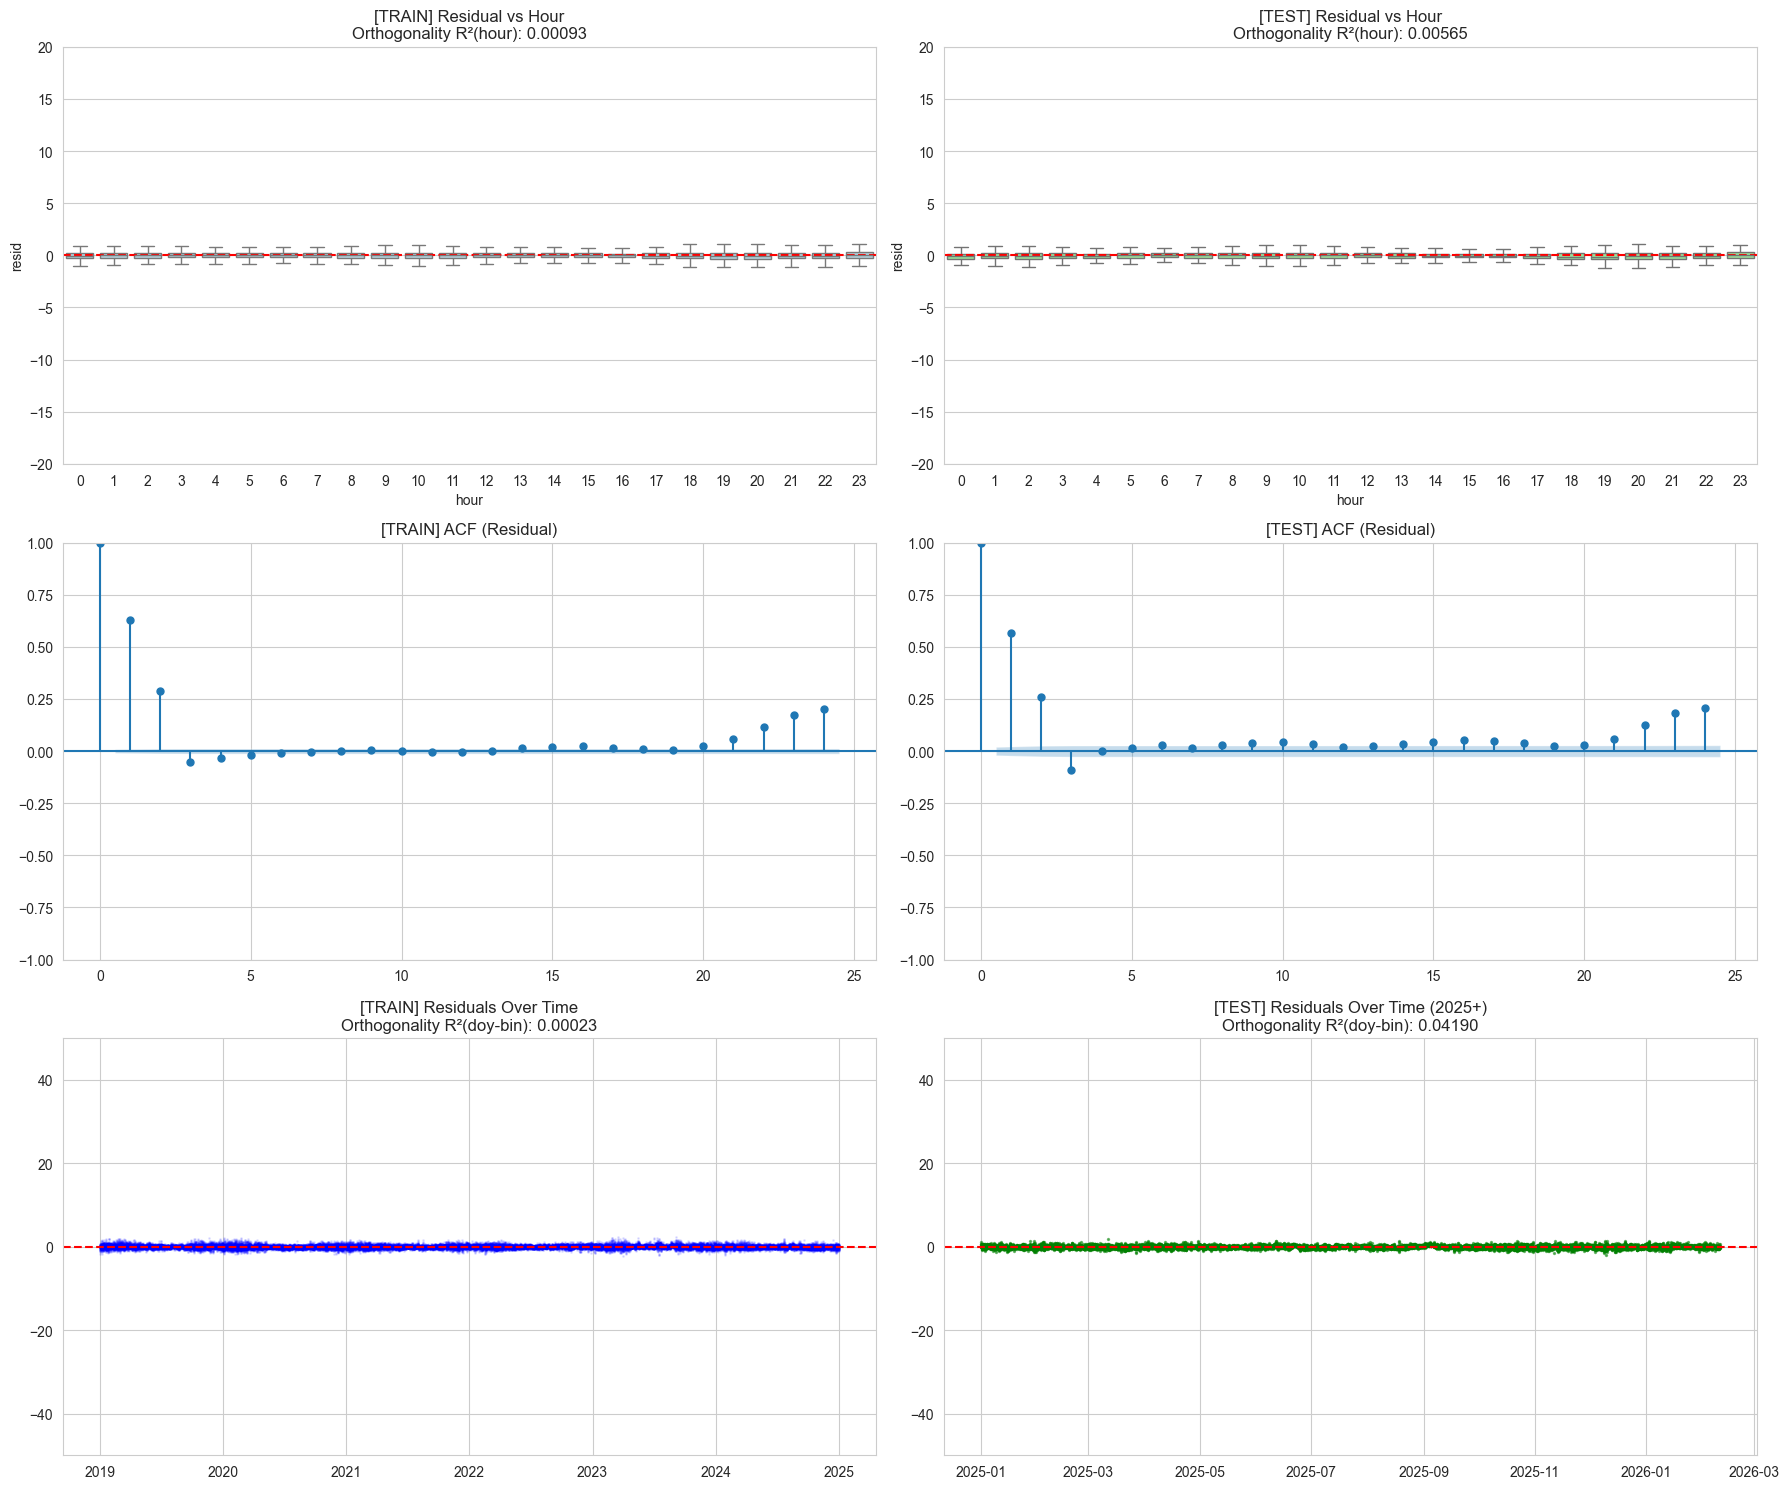

=== 模型结果 (Lag3 + Hour + DOY) ===
Test RMSE: 0.3663
Test R²  : 0.6415
Train Orthogonality R²(hour): 0.00093 (越低越好)
Test  Orthogonality R²(hour): 0.00565 (越低越好)
Train Orthogonality R²(doy-bin): 0.00023 (越低越好)
Test  Orthogonality R²(doy-bin): 0.04190 (越低越好)
解释：如果加入季节后，doy-bin 的 R² 明显下降、残差时间漂移减轻，说明季节性确实被模型吸收了。


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, l, s
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- 假设 df_imputed 已经在内存中 ---
target_region = 'Central Interior'

# 1) === 数据准备 ===
data = df_imputed[[target_region]].copy()
data.columns = ['y']

data['lag_3'] = data['y'].shift(3)

# diurnal / seasonal features
data['hour'] = data.index.hour              # 0..23
data['doy0'] = data.index.dayofyear - 1     # 0..365  (cyclic)
data.dropna(inplace=True)

# Train (2019-2024) vs Test (2025+)
train_mask = (data.index >= '2019-01-01') & (data.index <= '2024-12-31 23:59:59')
test_mask  = data.index >= '2025-01-01'

X_train = data.loc[train_mask, ['lag_3', 'hour', 'doy0']]
y_train = data.loc[train_mask, 'y'].values

X_test = data.loc[test_mask, ['lag_3', 'hour', 'doy0']]
y_test = data.loc[test_mask, 'y'].values

# 2) === 训练 GAM (Lag3 + Hour + Season) ===
print("正在训练: Inertia(Lag3) + Diurnal(Hour) + Seasonal(DayOfYear)...")

# l(0): lag_3 (线性惯性)
# s(1): hour (日内周期, cyclic spline)
# s(2): doy0 (年内周期, cyclic spline)
gam_season = LinearGAM(
    l(0) +
    s(1, basis='cp', n_splines=24) +
    s(2, basis='cp', n_splines=60)
).fit(X_train.values, y_train)

# 3) === 预测与残差 ===
data.loc[train_mask, 'pred'] = gam_season.predict(X_train.values)
data.loc[train_mask, 'resid'] = data.loc[train_mask, 'y'] - data.loc[train_mask, 'pred']

data.loc[test_mask, 'pred'] = gam_season.predict(X_test.values)
data.loc[test_mask, 'resid'] = data.loc[test_mask, 'y'] - data.loc[test_mask, 'pred']

resid_train = data.loc[train_mask, 'resid']
resid_test  = data.loc[test_mask, 'resid']
hour_train  = data.loc[train_mask, 'hour']
hour_test   = data.loc[test_mask, 'hour']

# 4) === 定量正交性测试（和你一致：one-hot hour -> residual）===
def orthogonality_r2(resid, hour_feature):
    X_dummy = pd.get_dummies(hour_feature, prefix='h')
    reg = LinearRegression().fit(X_dummy, resid)
    return reg.score(X_dummy, resid)

r2_ortho_train = orthogonality_r2(resid_train, hour_train)
r2_ortho_test  = orthogonality_r2(resid_test, hour_test)

# 额外：给你一个季节性“漂移解释度”指标（doy 对 residual 的可解释度）
def doy_orthogonality_r2(resid, doy0_feature, bins=36):
    # 把 doy0 分箱，避免 366 个 dummy 太碎
    b = pd.cut(doy0_feature, bins=bins, labels=False, include_lowest=True)
    X_dummy = pd.get_dummies(b, prefix='doybin')
    reg = LinearRegression().fit(X_dummy, resid)
    return reg.score(X_dummy, resid)

r2_doy_train = doy_orthogonality_r2(resid_train, data.loc[train_mask, 'doy0'])
r2_doy_test  = doy_orthogonality_r2(resid_test,  data.loc[test_mask, 'doy0'])

# 5) === 可视化对比 ===
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# Row 1: Residual vs Hour
sns.boxplot(x=hour_train, y=resid_train, ax=axes[0, 0], showfliers=False, color='lightblue')
axes[0, 0].set_title(f'[TRAIN] Residual vs Hour\nOrthogonality R²(hour): {r2_ortho_train:.5f}')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_ylim(-20, 20)

sns.boxplot(x=hour_test, y=resid_test, ax=axes[0, 1], showfliers=False, color='lightgreen')
axes[0, 1].set_title(f'[TEST] Residual vs Hour\nOrthogonality R²(hour): {r2_ortho_test:.5f}')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_ylim(-20, 20)

# Row 2: ACF
plot_acf(resid_train, lags=24, ax=axes[1, 0], title='[TRAIN] ACF (Residual)')
plot_acf(resid_test, lags=24, ax=axes[1, 1], title='[TEST] ACF (Residual)')

# Row 3: Residual over time
axes[2, 0].scatter(resid_train.index, resid_train, s=1, alpha=0.1, color='blue')
axes[2, 0].set_title(f'[TRAIN] Residuals Over Time\nOrthogonality R²(doy-bin): {r2_doy_train:.5f}')
axes[2, 0].set_ylim(-50, 50)
axes[2, 0].axhline(0, color='red', linestyle='--')

axes[2, 1].scatter(resid_test.index, resid_test, s=2, alpha=0.5, color='green')
axes[2, 1].set_title(f'[TEST] Residuals Over Time (2025+)\nOrthogonality R²(doy-bin): {r2_doy_test:.5f}')
axes[2, 1].set_ylim(-50, 50)
axes[2, 1].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# 6) === 预测性能（顺手给一个）===
pred_test = data.loc[test_mask, 'pred'].values
rmse = np.sqrt(mean_squared_error(data.loc[test_mask, 'y'].values, pred_test))
r2 = r2_score(data.loc[test_mask, 'y'].values, pred_test)

print(f"=== 模型结果 (Lag3 + Hour + DOY) ===")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²  : {r2:.4f}")
print(f"Train Orthogonality R²(hour): {r2_ortho_train:.5f} (越低越好)")
print(f"Test  Orthogonality R²(hour): {r2_ortho_test:.5f} (越低越好)")
print(f"Train Orthogonality R²(doy-bin): {r2_doy_train:.5f} (越低越好)")
print(f"Test  Orthogonality R²(doy-bin): {r2_doy_test:.5f} (越低越好)")
print("解释：如果加入季节后，doy-bin 的 R² 明显下降、残差时间漂移减轻，说明季节性确实被模型吸收了。")


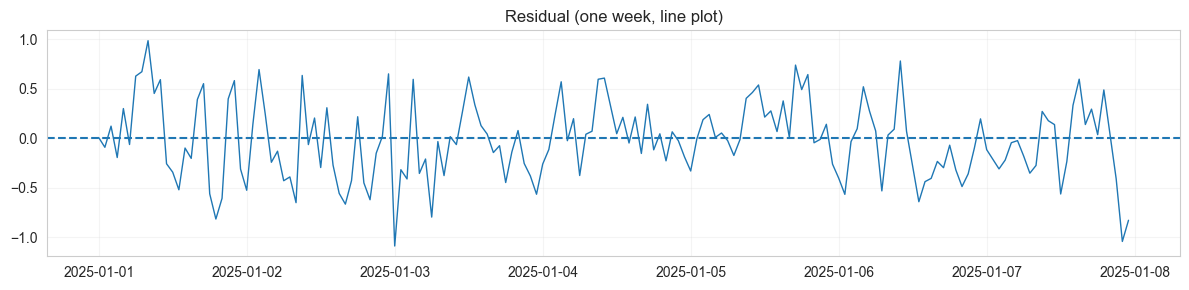

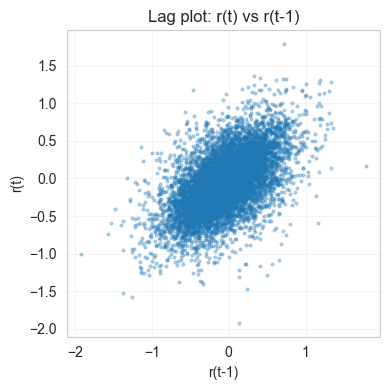

        lb_stat  lb_pvalue
6   3962.887498        0.0
12  4058.141130        0.0
24  5209.991847        0.0


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = resid_test.dropna()   # 或 resid_train

# A) 短窗口连线（例如任意一周）
w = resid.loc["2025-01-01":"2025-01-07"]
plt.figure(figsize=(12,3))
plt.plot(w.index, w.values, linewidth=1)
plt.axhline(0, linestyle="--")
plt.title("Residual (one week, line plot)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# B) Lag plot: r_t vs r_{t-1}
r1 = resid.shift(1).dropna()
r0 = resid.loc[r1.index]
plt.figure(figsize=(4,4))
plt.scatter(r1, r0, s=4, alpha=0.3)
plt.title("Lag plot: r(t) vs r(t-1)")
plt.xlabel("r(t-1)"); plt.ylabel("r(t)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# C) Ljung-Box（多滞后）
lb = acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)
print(lb)
